In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from collections import defaultdict
from shutil import copy
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from tqdm.notebook import tqdm
import seaborn as sns
from collections import Counter

from glob import glob
import psi4
from helper_CC_ML_spacial import *

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

  Threads set to 12 by Python driver.


In [2]:
def formatter(x, pos):
    if x != 0:
        return f'{int(x/1000)}k'
    else:
        return 0

In [3]:
# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# 31 Features order in X, including t2
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']

In [4]:
basis_sets = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

In [5]:
molecules = ["water", "methanol", "ethylene", "ethane", "methane", "ammonia", "formaldehyde"]

In [6]:
random.seed(0)
all_sampled_files = []

all_files = sorted(glob(os.path.join("data", f"water*.xyz")))
sample_size = min(150, len(all_files))
sampled_files = random.sample(all_files, sample_size)
train = sampled_files[:100] # 100 train molecules
test = sampled_files[100:] # 50 test molecules

In [14]:
train

['data/water189.xyz',
 'data/water93.xyz',
 'data/water197.xyz',
 'data/water109.xyz',
 'data/water16.xyz',
 'data/water35.xyz',
 'data/water3.xyz',
 'data/water193.xyz',
 'data/water17.xyz',
 'data/water28.xyz',
 'data/water182.xyz',
 'data/water52.xyz',
 'data/water15.xyz',
 'data/water34.xyz',
 'data/water131.xyz',
 'data/water165.xyz',
 'data/water86.xyz',
 'data/water121.xyz',
 'data/water60.xyz',
 'data/water158.xyz',
 'data/water40.xyz',
 'data/water57.xyz',
 'data/water133.xyz',
 'data/water171.xyz',
 'data/water122.xyz',
 'data/water116.xyz',
 'data/water176.xyz',
 'data/water26.xyz',
 'data/water47.xyz',
 'data/water77.xyz',
 'data/water181.xyz',
 'data/water20.xyz',
 'data/water172.xyz',
 'data/water59.xyz',
 'data/water65.xyz',
 'data/water147.xyz',
 'data/water45.xyz',
 'data/water90.xyz',
 'data/water201.xyz',
 'data/water38.xyz',
 'data/water95.xyz',
 'data/water113.xyz',
 'data/water44.xyz',
 'data/water102.xyz',
 'data/water120.xyz',
 'data/water192.xyz',
 'data/water1

In [15]:
test

['data/water160.xyz',
 'data/water84.xyz',
 'data/water62.xyz',
 'data/water98.xyz',
 'data/water80.xyz',
 'data/water70.xyz',
 'data/water168.xyz',
 'data/water148.xyz',
 'data/water39.xyz',
 'data/water19.xyz',
 'data/water151.xyz',
 'data/water157.xyz',
 'data/water22.xyz',
 'data/water174.xyz',
 'data/water140.xyz',
 'data/water196.xyz',
 'data/water137.xyz',
 'data/water23.xyz',
 'data/water112.xyz',
 'data/water54.xyz',
 'data/water185.xyz',
 'data/water138.xyz',
 'data/water27.xyz',
 'data/water63.xyz',
 'data/water101.xyz',
 'data/water130.xyz',
 'data/water92.xyz',
 'data/water125.xyz',
 'data/water142.xyz',
 'data/water119.xyz',
 'data/water78.xyz',
 'data/water149.xyz',
 'data/water106.xyz',
 'data/water110.xyz',
 'data/water76.xyz',
 'data/water41.xyz',
 'data/water104.xyz',
 'data/water108.xyz',
 'data/water100.xyz',
 'data/water161.xyz',
 'data/water56.xyz',
 'data/water190.xyz',
 'data/water134.xyz',
 'data/water184.xyz',
 'data/water48.xyz',
 'data/water50.xyz',
 'data/

In [16]:
X_test_all = {}
y_test_all = {}
basis_sets = ["aug-cc-pVDZ"]
for basis in basis_sets:
    filenames = test.copy()
    t1 = time.time()
    print(basis)

    data_dict = {}
    for fn in filenames:
        struct = os.path.basename(fn)
        print(f"Processing {struct}")
        
        with open(fn,'r') as f:
            text=f.read()
        
        mol = psi4.geometry(text)
        
        psi4.core.clean()
        psi4.core.be_quiet()
        
        psi4.set_options({'basis': basis,
                          'scf_type': 'pk',
                          'reference': 'rohf',
                          'mp2_type': 'conv',
                          'e_convergence': 1e-8,
                          'd_convergence': 1e-8})

        try:
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A = HelperCCEnergy(mol, rhf_e, scf_wfn, freeze_core=False)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy()                                   # exact CCSD energy

            data = pd.DataFrame(np.array([getattr(A, attr).flatten() for attr in properties]).T, columns=properties)
            data_dict[struct.split('_')[0]] = data

        except Exception as e:
            print(f"Molecule with filename {fn} failed: {e}")
            pass   

    X_test_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
    y_test_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        
    splits = {
        'X_test': X_test_all[basis],
        'y_test': y_test_all[basis]
    }
    
    joblib.dump(splits, f"water_out/{basis}_test_data_splits.pkl")
    t2 = time.time()

    print(f"Time taken for {basis}: {t2-t1} seconds \n")

aug-cc-pVDZ
Processing water160.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.707 seconds.

CCSD Iteration   0: CCSD correlation = -0.221749279852801   dE =  2.21749E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221749279852801   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.221749279852801   dE =  2.21749E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223711030941486   dE = -1.96175E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228226705160624   dE = -4.51567E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228643550310857   dE = -4.16845E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229244553448688   dE = -6.01003E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229281982451797   dE = -3.74290E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22928348434284

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.774 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624612589620   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624612589620   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624612589620   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612494750516   dE = -1.98788E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113209724448   dE = -4.50071E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529657351580   dE = -4.16448E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127569380287   dE = -5.97912E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164726255143   dE = -3.71569E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916619424814

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.043 seconds.

CCSD Iteration   0: CCSD correlation = -0.221619371147319   dE =  2.21619E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221619371147319   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221619371147319   dE =  2.21619E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223608289492922   dE = -1.98892E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228108293538428   dE = -4.50000E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228524667085727   dE = -4.16374E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229122516523305   dE = -5.97849E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229159668702754   dE = -3.71522E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916113383088

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.820 seconds.

CCSD Iteration   0: CCSD correlation = -0.221803586263886   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221803586263886   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.221803586263886   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223754019951657   dE = -1.95043E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228276327055384   dE = -4.52231E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228693415549554   dE = -4.17088E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229295686521911   dE = -6.02271E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229333226334208   dE = -3.75398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22933474485936

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.919 seconds.

CCSD Iteration   0: CCSD correlation = -0.221664201805559   dE =  2.21664E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221664201805559   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221664201805559   dE =  2.21664E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223643819318979   dE = -1.97962E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228149324438150   dE = -4.50551E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228565932190973   dE = -4.16608E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229164779590587   dE = -5.98847E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202018188378   dE = -3.72386E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920349778182

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.432 seconds.

CCSD Iteration   0: CCSD correlation = -0.221737912420050   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221737912420050   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221737912420050   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223702112977810   dE = -1.96420E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228216508503756   dE = -4.51440E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228633378827574   dE = -4.16870E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229234025881332   dE = -6.00647E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229271422523940   dE = -3.73966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927292282985

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.878 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624322602903   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624322602903   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624322602903   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612275857145   dE = -1.98795E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228112995318475   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529474489243   dE = -4.16479E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127329543816   dE = -5.97855E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164480736194   dE = -3.71512E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916594956256

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.761 seconds.

CCSD Iteration   0: CCSD correlation = -0.221668742644757   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221668742644757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221668742644757   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223647396731506   dE = -1.97865E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228153418402971   dE = -4.50602E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228570015225897   dE = -4.16597E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229169016272324   dE = -5.99001E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229206268749168   dE = -3.72525E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920774884320

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.731 seconds.

CCSD Iteration   0: CCSD correlation = -0.221576667515175   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221576667515175   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221576667515175   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223574570983579   dE = -1.99790E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228069543606373   dE = -4.49497E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228485839087251   dE = -4.16295E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229082558292246   dE = -5.96719E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229119610201446   dE = -3.70519E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912106536004

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.682 seconds.

CCSD Iteration   0: CCSD correlation = -0.221737912420062   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221737912420062   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221737912420062   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223702112977809   dE = -1.96420E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228216508503757   dE = -4.51440E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228633378827573   dE = -4.16870E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229234025881331   dE = -6.00647E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229271422523939   dE = -3.73966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927292282985

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.651 seconds.

CCSD Iteration   0: CCSD correlation = -0.221767044070259   dE =  2.21767E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221767044070259   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221767044070259   dE =  2.21767E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223725096803392   dE = -1.95805E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228242941121167   dE = -4.51784E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228659865438595   dE = -4.16924E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229261286211256   dE = -6.01421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229298751711415   dE = -3.74655E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22930025900562

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.722 seconds.

CCSD Iteration   0: CCSD correlation = -0.221592701290335   dE =  2.21593E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221592701290335   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221592701290335   dE =  2.21593E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223587255567892   dE = -1.99455E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228084147873147   dE = -4.49689E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228500494080471   dE = -4.16346E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229097612790045   dE = -5.97119E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229134699857539   dE = -3.70871E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22913615929098

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.730 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644739219476   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644739219476   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644739219476   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628420179837   dE = -1.98368E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131568331390   dE = -4.50315E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228548096234111   dE = -4.16528E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146485347755   dE = -5.98389E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183683932863   dE = -3.71986E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918515778796

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.773 seconds.

CCSD Iteration   0: CCSD correlation = -0.221753316842964   dE =  2.21753E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221753316842964   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221753316842964   dE =  2.21753E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223714296600958   dE = -1.96098E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228230587724279   dE = -4.51629E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228647546290328   dE = -4.16959E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229248512384035   dE = -6.00966E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229285936294846   dE = -3.74239E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22928744190776

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.747 seconds.

CCSD Iteration   0: CCSD correlation = -0.221615660390893   dE =  2.21616E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221615660390893   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221615660390893   dE =  2.21616E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223605417912567   dE = -1.98976E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228105067372974   dE = -4.49965E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228521492381639   dE = -4.16425E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229119173221884   dE = -5.97681E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229156309652360   dE = -3.71364E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915777540235

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.155 seconds.

CCSD Iteration   0: CCSD correlation = -0.221804904624711   dE =  2.21805E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221804904624711   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221804904624711   dE =  2.21805E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223755056342408   dE = -1.95015E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228277515093564   dE = -4.52246E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228694600298853   dE = -4.17085E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229296917213092   dE = -6.02317E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229334461127727   dE = -3.75439E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22933597979682

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.012 seconds.

CCSD Iteration   0: CCSD correlation = -0.221646283836988   dE =  2.21646E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221646283836988   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.008 seconds!
CCSD Iteration   0: CCSD correlation = -0.221646283836988   dE =  2.21646E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223629620333335   dE = -1.98334E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228132917330233   dE = -4.50330E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228549422960762   dE = -4.16506E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229147886618547   dE = -5.98464E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229185092207945   dE = -3.72056E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918656576185

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.863 seconds.

CCSD Iteration   0: CCSD correlation = -0.221690362989174   dE =  2.21690E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221690362989174   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221690362989174   dE =  2.21690E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223664499957955   dE = -1.97414E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228173135421058   dE = -4.50864E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228589818977509   dE = -4.16684E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229189328490478   dE = -5.99510E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229226625564571   dE = -3.72971E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922811203302

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.929 seconds.

CCSD Iteration   0: CCSD correlation = -0.221681857188355   dE =  2.21682E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221681857188355   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221681857188355   dE =  2.21682E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223657786841475   dE = -1.97593E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228165436459833   dE = -4.50765E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228582121649324   dE = -4.16685E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229181376230225   dE = -5.99255E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229218650246208   dE = -3.72740E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922013519897

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.219 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293904   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293904   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293904   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430700   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950698   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994716   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758788   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833785   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.112 seconds.

CCSD Iteration   0: CCSD correlation = -0.221700099203523   dE =  2.21700E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221700099203523   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221700099203523   dE =  2.21700E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223672214394961   dE = -1.97212E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228182062228159   dE = -4.50985E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228598811271022   dE = -4.16749E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229198512896821   dE = -5.99702E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229235826200192   dE = -3.73133E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923731624061

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.952 seconds.

CCSD Iteration   0: CCSD correlation = -0.221605355573052   dE =  2.21605E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221605355573052   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
CCSD Iteration   0: CCSD correlation = -0.221605355573052   dE =  2.21605E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223597251288052   dE = -1.99190E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228095632120089   dE = -4.49838E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228511997546914   dE = -4.16365E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229109460310893   dE = -5.97463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229146577992443   dE = -3.71177E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22914804024331

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.188 seconds.

CCSD Iteration   0: CCSD correlation = -0.221647158386444   dE =  2.21647E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221647158386444   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.221647158386444   dE =  2.21647E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223630338445359   dE = -1.98318E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228133787949264   dE = -4.50345E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228550330984960   dE = -4.16543E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229148771645566   dE = -5.98441E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229185974583950   dE = -3.72029E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918744927459

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.961 seconds.

CCSD Iteration   0: CCSD correlation = -0.221620206586893   dE =  2.21620E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221620206586893   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221620206586893   dE =  2.21620E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223609004447367   dE = -1.98880E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228109248761051   dE = -4.50024E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228525737033500   dE = -4.16488E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229123443132237   dE = -5.97706E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229160580604812   dE = -3.71375E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916204904957

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.135 seconds.

CCSD Iteration   0: CCSD correlation = -0.221680384214387   dE =  2.21680E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221680384214387   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.221680384214387   dE =  2.21680E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223656618111820   dE = -1.97623E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228164110568946   dE = -4.50749E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228580809597744   dE = -4.16699E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229179994624068   dE = -5.99185E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229217261996549   dE = -3.72674E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921874709638

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.387 seconds.

CCSD Iteration   0: CCSD correlation = -0.221641309456622   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221641309456622   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221641309456622   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223625669888203   dE = -1.98436E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228128347618831   dE = -4.50268E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228544819773711   dE = -4.16472E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229143183475260   dE = -5.98364E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229180380449141   dE = -3.71970E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918185218940

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.462 seconds.

CCSD Iteration   0: CCSD correlation = -0.221610620556244   dE =  2.21611E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221610620556244   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.221610620556244   dE =  2.21611E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223601429865965   dE = -1.99081E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228100470602333   dE = -4.49904E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228516875857282   dE = -4.16405E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229114436565138   dE = -5.97561E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229151562498220   dE = -3.71259E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915302679516

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.383 seconds.

CCSD Iteration   0: CCSD correlation = -0.221847061758815   dE =  2.21847E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221847061758815   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.008 seconds!
CCSD Iteration   0: CCSD correlation = -0.221847061758815   dE =  2.21847E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223788306674203   dE = -1.94124E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228315789860700   dE = -4.52748E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228732975581305   dE = -4.17186E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229336375289823   dE = -6.03400E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229374015279779   dE = -3.76400E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22937554482359

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.028 seconds.

CCSD Iteration   0: CCSD correlation = -0.221589254588967   dE =  2.21589E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221589254588967   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221589254588967   dE =  2.21589E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223584529027742   dE = -1.99527E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228081011541322   dE = -4.49648E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228497350099420   dE = -4.16339E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229094376775921   dE = -5.97027E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229131455698620   dE = -3.70789E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22913291431494

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.763 seconds.

CCSD Iteration   0: CCSD correlation = -0.221612349253568   dE =  2.21612E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221612349253568   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221612349253568   dE =  2.21612E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223602710966725   dE = -1.99036E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228101844236051   dE = -4.49913E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228518176248280   dE = -4.16332E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229115871215612   dE = -5.97695E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229153010025485   dE = -3.71388E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915447279793

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.355 seconds.

CCSD Iteration   0: CCSD correlation = -0.221647158386430   dE =  2.21647E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221647158386430   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.015 seconds!
CCSD Iteration   0: CCSD correlation = -0.221647158386430   dE =  2.21647E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223630338445359   dE = -1.98318E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228133787949263   dE = -4.50345E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228550330984960   dE = -4.16543E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229148771645566   dE = -5.98441E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229185974583951   dE = -3.72029E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918744927459

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.192 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644220232438   dE =  2.21644E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644220232438   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644220232438   dE =  2.21644E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628023375612   dE = -1.98380E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131144879086   dE = -4.50312E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228547694720665   dE = -4.16550E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146042902752   dE = -5.98348E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183237236323   dE = -3.71943E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918471153733

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.153 seconds.

CCSD Iteration   0: CCSD correlation = -0.221579802977641   dE =  2.21580E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221579802977641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.034 seconds!
CCSD Iteration   0: CCSD correlation = -0.221579802977641   dE =  2.21580E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223576863650527   dE = -1.99706E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071985976369   dE = -4.49512E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228488143239571   dE = -4.16157E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229085097912558   dE = -5.96955E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229122172291815   dE = -3.70744E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912362463422

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.445 seconds.

CCSD Iteration   0: CCSD correlation = -0.221692481381213   dE =  2.21692E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221692481381213   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.009 seconds!
CCSD Iteration   0: CCSD correlation = -0.221692481381213   dE =  2.21692E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666181619421   dE = -1.97370E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228175083806151   dE = -4.50890E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228591782349533   dE = -4.16699E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229191335099890   dE = -5.99553E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229228635797549   dE = -3.73007E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923012304188

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.291 seconds.

CCSD Iteration   0: CCSD correlation = -0.221734213528130   dE =  2.21734E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221734213528130   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221734213528130   dE =  2.21734E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699191228737   dE = -1.96498E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213150662792   dE = -4.51396E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630017415616   dE = -4.16867E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229230558122722   dE = -6.00541E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229267945237755   dE = -3.73871E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926944477417

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.337 seconds.

CCSD Iteration   0: CCSD correlation = -0.221610620556252   dE =  2.21611E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221610620556252   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221610620556252   dE =  2.21611E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223601429865964   dE = -1.99081E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228100470602334   dE = -4.49904E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228516875857281   dE = -4.16405E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229114436565138   dE = -5.97561E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229151562498220   dE = -3.71259E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915302679516

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.463 seconds.

CCSD Iteration   0: CCSD correlation = -0.221750559437459   dE =  2.21751E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221750559437459   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.221750559437459   dE =  2.21751E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223702823282882   dE = -1.95226E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213851012419   dE = -4.51103E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228629408063650   dE = -4.15557E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229227603545129   dE = -5.98195E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229264739319109   dE = -3.71358E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926624240515

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.999 seconds.

CCSD Iteration   0: CCSD correlation = -0.221601719670768   dE =  2.21602E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221601719670768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221601719670768   dE =  2.21602E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223594350408850   dE = -1.99263E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228092259654647   dE = -4.49791E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228508588175764   dE = -4.16329E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229105991150862   dE = -5.97403E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229143103931377   dE = -3.71128E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22914456455617

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.252 seconds.

CCSD Iteration   0: CCSD correlation = -0.221584629526655   dE =  2.21585E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221584629526655   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221584629526655   dE =  2.21585E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223580871425568   dE = -1.99624E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228076804964651   dE = -4.49593E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228493132092985   dE = -4.16327E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229090039617086   dE = -5.96908E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229127107959655   dE = -3.70683E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912856542384

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.307 seconds.

CCSD Iteration   0: CCSD correlation = -0.221618270668913   dE =  2.21618E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221618270668913   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221618270668913   dE =  2.21618E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223607486761175   dE = -1.98922E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228107475889314   dE = -4.49999E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228523932768224   dE = -4.16457E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229121640272262   dE = -5.97708E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229158778562299   dE = -3.71383E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916024569333

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.478 seconds.

CCSD Iteration   0: CCSD correlation = -0.221570559083628   dE =  2.21571E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221570559083628   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.221570559083628   dE =  2.21571E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223567914586647   dE = -1.99736E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228060740310877   dE = -4.49283E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228476275812160   dE = -4.15536E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229073203307494   dE = -5.96927E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229110275233786   dE = -3.70719E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22911171385623

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.246 seconds.

CCSD Iteration   0: CCSD correlation = -0.221611714862967   dE =  2.21612E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221611714862967   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221611714862967   dE =  2.21612E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223602300465266   dE = -1.99059E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228101493508008   dE = -4.49919E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228517920131544   dE = -4.16427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229115480109321   dE = -5.97560E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229152605617860   dE = -3.71255E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915407071660

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.339 seconds.

CCSD Iteration   0: CCSD correlation = -0.221717646747727   dE =  2.21718E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221717646747727   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
CCSD Iteration   0: CCSD correlation = -0.221717646747727   dE =  2.21718E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223686084118192   dE = -1.96844E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228198026091000   dE = -4.51194E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228614819400287   dE = -4.16793E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229214976640778   dE = -6.00157E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229252330378095   dE = -3.73537E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925382485871

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.003 seconds.

CCSD Iteration   0: CCSD correlation = -0.221620022254943   dE =  2.21620E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221620022254943   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.022 seconds!
CCSD Iteration   0: CCSD correlation = -0.221620022254943   dE =  2.21620E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223608873398987   dE = -1.98885E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228109066832095   dE = -4.50019E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228525523235286   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229123285835613   dE = -5.97763E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229160429099602   dE = -3.71433E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916189651190

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.482 seconds.

CCSD Iteration   0: CCSD correlation = -0.221667453380633   dE =  2.21667E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221667453380633   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.015 seconds!
CCSD Iteration   0: CCSD correlation = -0.221667453380633   dE =  2.21667E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223646392852240   dE = -1.97894E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228152295953376   dE = -4.50590E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228568920421134   dE = -4.16624E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229167839220000   dE = -5.98919E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229205083972067   dE = -3.72448E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920656461873

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.131 seconds.

CCSD Iteration   0: CCSD correlation = -0.221680384214397   dE =  2.21680E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221680384214397   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221680384214397   dE =  2.21680E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223656618111820   dE = -1.97623E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228164110568947   dE = -4.50749E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228580809597744   dE = -4.16699E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229179994624068   dE = -5.99185E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229217261996549   dE = -3.72674E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921874709638

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.643 seconds.

CCSD Iteration   0: CCSD correlation = -0.221665040925936   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221665040925936   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.031 seconds!
CCSD Iteration   0: CCSD correlation = -0.221665040925936   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223644482291900   dE = -1.97944E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228150081322613   dE = -4.50560E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228566682388140   dE = -4.16601E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229165570058753   dE = -5.98888E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202812277718   dE = -3.72422E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920429179154

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.944 seconds.

CCSD Iteration   0: CCSD correlation = -0.221636723261335   dE =  2.21637E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221636723261335   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221636723261335   dE =  2.21637E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223622079743982   dE = -1.98536E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228124262595502   dE = -4.50218E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228540760894709   dE = -4.16498E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229138957638903   dE = -5.98197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229176139340689   dE = -3.71817E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917761091484

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.799 seconds.

CCSD Iteration   0: CCSD correlation = -0.221734213528145   dE =  2.21734E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221734213528145   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221734213528145   dE =  2.21734E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699191228736   dE = -1.96498E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213150662794   dE = -4.51396E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630017415616   dE = -4.16867E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229230558122722   dE = -6.00541E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229267945237755   dE = -3.73871E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926944477416

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.780 seconds.

CCSD Iteration   0: CCSD correlation = -0.221617676727828   dE =  2.21618E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221617676727828   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221617676727828   dE =  2.21618E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223607015247470   dE = -1.98934E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228106914494282   dE = -4.49990E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228523352734859   dE = -4.16438E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229121073274076   dE = -5.97721E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229158213070636   dE = -3.71398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22915967955404

In [ ]:
n_list = [10, 20, 40, 60, 80, 100]
X_train_all = {}
y_train_all = {}

for basis in basis_sets: 
    for n in n_list:
        filenames = train[:n]
        t1 = time.time()
        
        print(f"{basis} Basis, N = {n} training molecules")
        print(f"Training molecules: {filenames}")

        # get training molecule
        data_dict = {}
        for fn in filenames:
            struct = os.path.basename(fn)
            print(f"Processing {struct}")
            
            with open(fn,'r') as f:
                text=f.read()
            
            mol = psi4.geometry(text)
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            try:
                
                rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                
                A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)
    
    
                MP2T2=A.t2start
                A.t1 = np.zeros((A.t1.shape))
                A.t2 = MP2T2
                
                MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
                CCSDE = A.compute_energy()                                   # exact CCSD energy
    
                data=pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
                data_dict[struct.split('_')[0]]=data
            except Exception as e:
                print(f"Molecule with filename {fn} failed: {e}")
                pass   

        X_train_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
        y_train_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        splits = {
            'X_train': X_train_all[basis],
            'y_train': y_train_all[basis]
        }
        
        joblib.dump(splits, f"water_out/{basis}_train_data_splits_{n}.pkl")

aug-cc-pVDZ Basis, N = 10 training molecules
Training molecules: ['data/water189.xyz', 'data/water93.xyz', 'data/water197.xyz', 'data/water109.xyz', 'data/water16.xyz', 'data/water35.xyz', 'data/water3.xyz', 'data/water193.xyz', 'data/water17.xyz', 'data/water28.xyz']
Processing water189.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.747 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057568   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714835057568   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714835057568   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479515   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600269   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536880   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429349   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573811   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925119688405

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.725 seconds.

CCSD Iteration   0: CCSD correlation = -0.221827024214749   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221827024214749   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221827024214749   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223772505844752   dE = -1.94548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228297599934372   dE = -4.52509E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228714737117575   dE = -4.17137E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229317624332870   dE = -6.02887E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229355218881810   dE = -3.75945E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22935674321947

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.746 seconds.

CCSD Iteration   0: CCSD correlation = -0.221701762052854   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221701762052854   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221701762052854   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223673484948065   dE = -1.97172E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228183571523714   dE = -4.51009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228600376078134   dE = -4.16805E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229200010135067   dE = -5.99634E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229237315895419   dE = -3.73058E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923880801296

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.790 seconds.

CCSD Iteration   0: CCSD correlation = -0.221729267120364   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221729267120364   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221729267120364   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223695250231050   dE = -1.96598E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228208557880906   dE = -4.51331E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228625364811559   dE = -4.16807E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229225843167397   dE = -6.00478E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229263225587701   dE = -3.73824E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926472261927

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.661 seconds.

CCSD Iteration   0: CCSD correlation = -0.221638465159962   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221638465159962   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221638465159962   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223623460863708   dE = -1.98500E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228125863632438   dE = -4.50240E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228542377264644   dE = -4.16514E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229140601634372   dE = -5.98224E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229177785603622   dE = -3.71840E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917925792781

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.681 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648573   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648573   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648573   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048312   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008565   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.673 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293888   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293888   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293888   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430701   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950697   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994717   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758788   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833786   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.922 seconds.

CCSD Iteration   0: CCSD correlation = -0.221693453544836   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221693453544836   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221693453544836   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666956859322   dE = -1.97350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228176016922777   dE = -4.50906E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228592755598914   dE = -4.16739E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229192271138985   dE = -5.99516E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229229567764709   dE = -3.72966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923105633310

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.847 seconds.

CCSD Iteration   0: CCSD correlation = -0.221677257753676   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221677257753676   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221677257753676   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223654148182415   dE = -1.97689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228161236788011   dE = -4.50709E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228577899848472   dE = -4.16663E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229177051547696   dE = -5.99152E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229214316668843   dE = -3.72651E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921580016926

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.783 seconds.

CCSD Iteration   0: CCSD correlation = -0.221707446071367   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221707446071367   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221707446071367   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223678004316574   dE = -1.97056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228188691486926   dE = -4.51069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228605428869763   dE = -4.16737E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229205365558955   dE = -5.99937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229242700241088   dE = -3.73347E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924419132026

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.830 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057568   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714835057568   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714835057568   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479516   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600270   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536881   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429350   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573812   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925119688405

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.726 seconds.

CCSD Iteration   0: CCSD correlation = -0.221827024214727   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221827024214727   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221827024214727   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223772505844751   dE = -1.94548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228297599934369   dE = -4.52509E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228714737117574   dE = -4.17137E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229317624332869   dE = -6.02887E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229355218881809   dE = -3.75945E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22935674321947

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.951 seconds.

CCSD Iteration   0: CCSD correlation = -0.221701762052851   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221701762052851   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221701762052851   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223673484948066   dE = -1.97172E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228183571523714   dE = -4.51009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228600376078135   dE = -4.16805E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229200010135067   dE = -5.99634E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229237315895419   dE = -3.73058E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923880801296

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.733 seconds.

CCSD Iteration   0: CCSD correlation = -0.221729267120354   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221729267120354   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221729267120354   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223695250231050   dE = -1.96598E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228208557880905   dE = -4.51331E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228625364811559   dE = -4.16807E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229225843167398   dE = -6.00478E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229263225587701   dE = -3.73824E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926472261927

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.828 seconds.

CCSD Iteration   0: CCSD correlation = -0.221638465159953   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221638465159953   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221638465159953   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223623460863707   dE = -1.98500E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228125863632437   dE = -4.50240E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228542377264643   dE = -4.16514E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229140601634372   dE = -5.98224E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229177785603622   dE = -3.71840E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917925792781

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.810 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648584   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648584   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648584   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048312   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008565   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447888   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.745 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293903   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293903   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293903   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430701   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950698   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994717   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758788   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833786   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.931 seconds.

CCSD Iteration   0: CCSD correlation = -0.221693453544862   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221693453544862   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221693453544862   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666956859322   dE = -1.97350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228176016922780   dE = -4.50906E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228592755598914   dE = -4.16739E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229192271138985   dE = -5.99516E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229229567764709   dE = -3.72966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923105633310

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.663 seconds.

CCSD Iteration   0: CCSD correlation = -0.221677257753667   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221677257753667   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221677257753667   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223654148182414   dE = -1.97689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228161236788009   dE = -4.50709E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228577899848471   dE = -4.16663E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229177051547695   dE = -5.99152E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229214316668842   dE = -3.72651E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921580016926

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.826 seconds.

CCSD Iteration   0: CCSD correlation = -0.221707446071370   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221707446071370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221707446071370   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223678004316574   dE = -1.97056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228188691486927   dE = -4.51069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228605428869764   dE = -4.16737E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229205365558955   dE = -5.99937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229242700241088   dE = -3.73347E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924419132026

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.651 seconds.

CCSD Iteration   0: CCSD correlation = -0.221662418215940   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221662418215940   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221662418215940   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223642382659419   dE = -1.97996E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228147624512365   dE = -4.50524E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228564189290345   dE = -4.16565E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229163042956915   dE = -5.98854E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229200282762169   dE = -3.72398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920176088578

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.735 seconds.

CCSD Iteration   0: CCSD correlation = -0.221578463293732   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221578463293732   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221578463293732   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223575987872223   dE = -1.99752E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071161842082   dE = -4.49517E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228487452441514   dE = -4.16291E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229084231618046   dE = -5.96779E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229121289034454   dE = -3.70574E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912274438043

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.965 seconds.

CCSD Iteration   0: CCSD correlation = -0.221622790575937   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221622790575937   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221622790575937   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223611061955413   dE = -1.98827E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228111599833818   dE = -4.50054E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228528077387879   dE = -4.16478E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229125886874845   dE = -5.97809E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229163033995248   dE = -3.71471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916450252252

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.733 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644548225123   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644548225123   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644548225123   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628271375485   dE = -1.98372E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131400602022   dE = -4.50313E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228547929843580   dE = -4.16529E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146313129205   dE = -5.98383E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183511130305   dE = -3.71980E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918498497137

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.879 seconds.

CCSD Iteration   0: CCSD correlation = -0.221722288050552   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221722288050552   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221722288050552   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223689751519070   dE = -1.96746E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228202247220981   dE = -4.51250E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228619050956742   dE = -4.16804E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229219331867397   dE = -6.00281E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229256696552362   dE = -3.73647E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925819216292

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.714 seconds.

CCSD Iteration   0: CCSD correlation = -0.221735020323740   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221735020323740   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221735020323740   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699833013551   dE = -1.96481E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213904297344   dE = -4.51407E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630784871336   dE = -4.16881E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229231329755408   dE = -6.00545E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229268716937188   dE = -3.73872E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927021698802

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.107 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648583   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048311   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008565   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170391   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447888   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591952   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.927 seconds.

CCSD Iteration   0: CCSD correlation = -0.221689370585712   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221689370585712   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221689370585712   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223663679070207   dE = -1.97431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228172144598715   dE = -4.50847E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228588789262147   dE = -4.16645E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229188317218486   dE = -5.99528E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229225616468041   dE = -3.72992E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922710176749

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.733 seconds.

CCSD Iteration   0: CCSD correlation = -0.221665445778198   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221665445778198   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221665445778198   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223644524833546   dE = -1.97908E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228149885414923   dE = -4.50536E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228566312576862   dE = -4.16427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229165367369480   dE = -5.99055E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202626288076   dE = -3.72589E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920410190058

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.801 seconds.

CCSD Iteration   0: CCSD correlation = -0.221719028625438   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221719028625438   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221719028625438   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223687178685118   dE = -1.96815E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228199289405081   dE = -4.51211E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228616086986194   dE = -4.16798E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229216282142984   dE = -6.00195E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229253639161128   dE = -3.73570E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925513398478

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.887 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057553   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714835057553   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714835057553   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479515   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600268   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536881   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429349   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573811   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925119688405

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.785 seconds.

CCSD Iteration   0: CCSD correlation = -0.221827024214728   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221827024214728   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221827024214728   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223772505844751   dE = -1.94548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228297599934370   dE = -4.52509E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228714737117574   dE = -4.17137E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229317624332869   dE = -6.02887E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229355218881809   dE = -3.75945E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22935674321947

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.928 seconds.

CCSD Iteration   0: CCSD correlation = -0.221701762052864   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221701762052864   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221701762052864   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223673484948066   dE = -1.97172E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228183571523716   dE = -4.51009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228600376078135   dE = -4.16805E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229200010135068   dE = -5.99634E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229237315895420   dE = -3.73058E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923880801296

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.658 seconds.

CCSD Iteration   0: CCSD correlation = -0.221729267120360   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221729267120360   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221729267120360   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223695250231051   dE = -1.96598E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228208557880907   dE = -4.51331E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228625364811560   dE = -4.16807E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229225843167398   dE = -6.00478E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229263225587701   dE = -3.73824E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926472261927

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.679 seconds.

CCSD Iteration   0: CCSD correlation = -0.221638465159964   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221638465159964   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221638465159964   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223623460863707   dE = -1.98500E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228125863632437   dE = -4.50240E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228542377264643   dE = -4.16514E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229140601634371   dE = -5.98224E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229177785603621   dE = -3.71840E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917925792781

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.712 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648598   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648598   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648598   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048313   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008568   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.970 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293885   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293885   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293885   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430700   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950697   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994717   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758789   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833786   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.729 seconds.

CCSD Iteration   0: CCSD correlation = -0.221693453544837   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221693453544837   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221693453544837   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666956859321   dE = -1.97350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228176016922777   dE = -4.50906E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228592755598914   dE = -4.16739E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229192271138984   dE = -5.99516E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229229567764708   dE = -3.72966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923105633310

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.769 seconds.

CCSD Iteration   0: CCSD correlation = -0.221677257753673   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221677257753673   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221677257753673   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223654148182414   dE = -1.97689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228161236788010   dE = -4.50709E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228577899848471   dE = -4.16663E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229177051547695   dE = -5.99152E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229214316668842   dE = -3.72651E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921580016926

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.798 seconds.

CCSD Iteration   0: CCSD correlation = -0.221707446071385   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221707446071385   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221707446071385   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223678004316574   dE = -1.97056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228188691486929   dE = -4.51069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228605428869764   dE = -4.16737E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229205365558956   dE = -5.99937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229242700241089   dE = -3.73347E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924419132026

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.689 seconds.

CCSD Iteration   0: CCSD correlation = -0.221662418215953   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221662418215953   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221662418215953   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223642382659421   dE = -1.97996E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228147624512367   dE = -4.50524E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228564189290346   dE = -4.16565E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229163042956916   dE = -5.98854E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229200282762170   dE = -3.72398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920176088578

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.761 seconds.

CCSD Iteration   0: CCSD correlation = -0.221578463293734   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221578463293734   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221578463293734   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223575987872222   dE = -1.99752E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071161842082   dE = -4.49517E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228487452441514   dE = -4.16291E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229084231618046   dE = -5.96779E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229121289034454   dE = -3.70574E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912274438043

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.668 seconds.

CCSD Iteration   0: CCSD correlation = -0.221622790575934   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221622790575934   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221622790575934   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223611061955414   dE = -1.98827E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228111599833818   dE = -4.50054E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228528077387879   dE = -4.16478E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229125886874846   dE = -5.97809E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229163033995249   dE = -3.71471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916450252252

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.730 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644548225118   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644548225118   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644548225118   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628271375486   dE = -1.98372E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131400602022   dE = -4.50313E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228547929843580   dE = -4.16529E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146313129205   dE = -5.98383E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183511130305   dE = -3.71980E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918498497137

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.799 seconds.

CCSD Iteration   0: CCSD correlation = -0.221722288050563   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221722288050563   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221722288050563   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223689751519070   dE = -1.96746E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228202247220982   dE = -4.51250E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228619050956743   dE = -4.16804E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229219331867397   dE = -6.00281E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229256696552362   dE = -3.73647E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925819216292

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.646 seconds.

CCSD Iteration   0: CCSD correlation = -0.221735020323733   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221735020323733   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221735020323733   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699833013551   dE = -1.96481E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213904297343   dE = -4.51407E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630784871336   dE = -4.16881E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229231329755408   dE = -6.00545E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229268716937188   dE = -3.73872E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927021698802

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.731 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648583   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048311   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008566   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.637 seconds.

CCSD Iteration   0: CCSD correlation = -0.221689370585692   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221689370585692   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221689370585692   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223663679070207   dE = -1.97431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228172144598715   dE = -4.50847E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228588789262148   dE = -4.16645E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229188317218487   dE = -5.99528E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229225616468042   dE = -3.72992E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922710176749

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.724 seconds.

CCSD Iteration   0: CCSD correlation = -0.221665445778199   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221665445778199   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221665445778199   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223644524833546   dE = -1.97908E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228149885414923   dE = -4.50536E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228566312576861   dE = -4.16427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229165367369480   dE = -5.99055E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202626288075   dE = -3.72589E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920410190058

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.631 seconds.

CCSD Iteration   0: CCSD correlation = -0.221719028625436   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221719028625436   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221719028625436   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223687178685119   dE = -1.96815E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228199289405082   dE = -4.51211E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228616086986194   dE = -4.16798E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229216282142985   dE = -6.00195E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229253639161129   dE = -3.73570E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925513398478

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.657 seconds.

CCSD Iteration   0: CCSD correlation = -0.221669362440614   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221669362440614   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221669362440614   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223647902342443   dE = -1.97854E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228154030649246   dE = -4.50613E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228570656741765   dE = -4.16626E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229169631670688   dE = -5.98975E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229206881433299   dE = -3.72498E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920836245632

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.643 seconds.

CCSD Iteration   0: CCSD correlation = -0.221857405468200   dE =  2.21857E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221857405468200   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221857405468200   dE =  2.21857E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223792262852469   dE = -1.93486E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228319113825307   dE = -4.52685E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228735993859367   dE = -4.16880E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229337963231146   dE = -6.01969E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229375448212777   dE = -3.74850E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22937698729090

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.640 seconds.

CCSD Iteration   0: CCSD correlation = -0.221782403538346   dE =  2.21782E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221782403538346   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221782403538346   dE =  2.21782E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223737248660732   dE = -1.95485E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228256959417451   dE = -4.51971E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228673947656973   dE = -4.16988E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229275730100472   dE = -6.01782E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229313227356542   dE = -3.74973E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22931473925898

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.695 seconds.

CCSD Iteration   0: CCSD correlation = -0.221653937805975   dE =  2.21654E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221653937805975   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221653937805975   dE =  2.21654E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223635694811763   dE = -1.98176E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228139947801002   dE = -4.50425E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228556506282248   dE = -4.16558E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229155122408893   dE = -5.98616E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229192340958359   dE = -3.72185E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22919381732887

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.647 seconds.

CCSD Iteration   0: CCSD correlation = -0.221836945021758   dE =  2.21837E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221836945021758   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221836945021758   dE =  2.21837E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223780427602012   dE = -1.94348E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228306873509146   dE = -4.52645E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228724151758872   dE = -4.17278E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229327150484367   dE = -6.02999E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229364752223680   dE = -3.76017E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22936628196074

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.687 seconds.

CCSD Iteration   0: CCSD correlation = -0.221694847519880   dE =  2.21695E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221694847519880   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221694847519880   dE =  2.21695E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223668058730058   dE = -1.97321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228177262636191   dE = -4.50920E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228593984021874   dE = -4.16721E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229193571530105   dE = -5.99588E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229230875019453   dE = -3.73035E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923236333554

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.658 seconds.

CCSD Iteration   0: CCSD correlation = -0.221583301587775   dE =  2.21583E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221583301587775   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221583301587775   dE =  2.21583E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223579810110603   dE = -1.99651E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228075605498785   dE = -4.49580E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228491952037769   dE = -4.16347E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229088779584661   dE = -5.96828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229125840340198   dE = -3.70608E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912729820778

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.699 seconds.

CCSD Iteration   0: CCSD correlation = -0.221641310573288   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221641310573288   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221641310573288   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223625607736099   dE = -1.98430E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228128215308990   dE = -4.50261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228544644467986   dE = -4.16429E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229143047686163   dE = -5.98403E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229180248707100   dE = -3.72010E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918171945386

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.642 seconds.

CCSD Iteration   0: CCSD correlation = -0.221803586263870   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221803586263870   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221803586263870   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223754019951658   dE = -1.95043E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228276327055382   dE = -4.52231E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228693415549554   dE = -4.17088E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229295686521911   dE = -6.02271E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229333226334209   dE = -3.75398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22933474485936

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.695 seconds.

CCSD Iteration   0: CCSD correlation = -0.221641310573294   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221641310573294   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221641310573294   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223625607736100   dE = -1.98430E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228128215308990   dE = -4.50261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228544644467986   dE = -4.16429E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229143047686163   dE = -5.98403E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229180248707098   dE = -3.72010E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918171945386

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.630 seconds.

CCSD Iteration   0: CCSD correlation = -0.221697990029567   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221697990029567   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221697990029567   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223670534827484   dE = -1.97254E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228180095767798   dE = -4.50956E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228596811032336   dE = -4.16715E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229196500235655   dE = -5.99689E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229233813009517   dE = -3.73128E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923530174248

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.663 seconds.

CCSD Iteration   0: CCSD correlation = -0.221676095239468   dE =  2.21676E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221676095239468   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221676095239468   dE =  2.21676E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223653216354578   dE = -1.97712E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228160131127476   dE = -4.50691E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228576758851141   dE = -4.16628E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229175933764964   dE = -5.99175E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229213201410090   dE = -3.72676E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921468368198

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.674 seconds.

CCSD Iteration   0: CCSD correlation = -0.221726420548178   dE =  2.21726E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221726420548178   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221726420548178   dE =  2.21726E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223693019520452   dE = -1.96660E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228206014458441   dE = -4.51299E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228622833362312   dE = -4.16819E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229223214506136   dE = -6.00381E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229260587990181   dE = -3.73735E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926208477775

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.713 seconds.

CCSD Iteration   0: CCSD correlation = -0.221573677834279   dE =  2.21574E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221573677834279   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221573677834279   dE =  2.21574E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223572202150540   dE = -1.99852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228066802793418   dE = -4.49460E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228483077570231   dE = -4.16275E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229079738982246   dE = -5.96661E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229116786047172   dE = -3.70471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22911824009551

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.671 seconds.

CCSD Iteration   0: CCSD correlation = -0.221600197144324   dE =  2.21600E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221600197144324   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221600197144324   dE =  2.21600E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223593167112489   dE = -1.99297E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228090922361513   dE = -4.49776E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228507266189308   dE = -4.16344E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229104606822253   dE = -5.97341E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229141713864463   dE = -3.71070E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22914317460112

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.732 seconds.

CCSD Iteration   0: CCSD correlation = -0.221687722717233   dE =  2.21688E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221687722717233   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221687722717233   dE =  2.21688E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223662418773674   dE = -1.97470E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228170749426075   dE = -4.50833E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228587433868506   dE = -4.16684E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229186864841844   dE = -5.99431E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229224154824074   dE = -3.72900E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922564082305

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.733 seconds.

CCSD Iteration   0: CCSD correlation = -0.221647670222463   dE =  2.21648E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221647670222463   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221647670222463   dE =  2.21648E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223630732832775   dE = -1.98306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228134285761963   dE = -4.50355E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228550873377229   dE = -4.16588E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229149246965566   dE = -5.98374E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229186442958308   dE = -3.71960E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918791909684

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.700 seconds.

CCSD Iteration   0: CCSD correlation = -0.221576667515167   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221576667515167   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221576667515167   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223574570983578   dE = -1.99790E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228069543606372   dE = -4.49497E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228485839087250   dE = -4.16295E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229082558292246   dE = -5.96719E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229119610201445   dE = -3.70519E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912106536004

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.719 seconds.

CCSD Iteration   0: CCSD correlation = -0.221710772768973   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221710772768973   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221710772768973   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223680640324343   dE = -1.96987E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228191737578657   dE = -4.51110E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228608494524643   dE = -4.16757E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229208500469102   dE = -6.00006E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229245841139834   dE = -3.73407E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924733337124

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.818 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057550   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714835057550   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714835057550   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479516   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600269   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536881   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429350   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573812   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925119688405

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.965 seconds.

CCSD Iteration   0: CCSD correlation = -0.221827024214750   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221827024214750   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.017 seconds!
CCSD Iteration   0: CCSD correlation = -0.221827024214750   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223772505844751   dE = -1.94548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228297599934371   dE = -4.52509E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228714737117574   dE = -4.17137E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229317624332869   dE = -6.02887E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229355218881809   dE = -3.75945E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22935674321947

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.682 seconds.

CCSD Iteration   0: CCSD correlation = -0.221701762052874   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221701762052874   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221701762052874   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223673484948066   dE = -1.97172E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228183571523716   dE = -4.51009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228600376078135   dE = -4.16805E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229200010135067   dE = -5.99634E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229237315895420   dE = -3.73058E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923880801296

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.780 seconds.

CCSD Iteration   0: CCSD correlation = -0.221729267120359   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221729267120359   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221729267120359   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223695250231049   dE = -1.96598E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228208557880905   dE = -4.51331E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228625364811559   dE = -4.16807E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229225843167397   dE = -6.00478E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229263225587700   dE = -3.73824E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926472261927

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.639 seconds.

CCSD Iteration   0: CCSD correlation = -0.221638465159966   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221638465159966   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221638465159966   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223623460863706   dE = -1.98500E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228125863632438   dE = -4.50240E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228542377264643   dE = -4.16514E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229140601634372   dE = -5.98224E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229177785603622   dE = -3.71840E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917925792781

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.736 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648583   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648583   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048312   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008566   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.817 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293911   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293911   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293911   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430701   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950699   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994717   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758789   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833786   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.781 seconds.

CCSD Iteration   0: CCSD correlation = -0.221693453544843   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221693453544843   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221693453544843   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666956859324   dE = -1.97350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228176016922778   dE = -4.50906E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228592755598915   dE = -4.16739E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229192271138985   dE = -5.99516E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229229567764710   dE = -3.72966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923105633311

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.742 seconds.

CCSD Iteration   0: CCSD correlation = -0.221677257753677   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221677257753677   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221677257753677   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223654148182414   dE = -1.97689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228161236788010   dE = -4.50709E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228577899848472   dE = -4.16663E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229177051547695   dE = -5.99152E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229214316668843   dE = -3.72651E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921580016926

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.797 seconds.

CCSD Iteration   0: CCSD correlation = -0.221707446071377   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221707446071377   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221707446071377   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223678004316575   dE = -1.97056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228188691486928   dE = -4.51069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228605428869764   dE = -4.16737E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229205365558956   dE = -5.99937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229242700241089   dE = -3.73347E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924419132026

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.723 seconds.

CCSD Iteration   0: CCSD correlation = -0.221662418215947   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221662418215947   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221662418215947   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223642382659420   dE = -1.97996E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228147624512365   dE = -4.50524E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228564189290345   dE = -4.16565E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229163042956915   dE = -5.98854E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229200282762169   dE = -3.72398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920176088578

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.684 seconds.

CCSD Iteration   0: CCSD correlation = -0.221578463293732   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221578463293732   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221578463293732   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223575987872223   dE = -1.99752E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071161842083   dE = -4.49517E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228487452441514   dE = -4.16291E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229084231618046   dE = -5.96779E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229121289034455   dE = -3.70574E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912274438043

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.733 seconds.

CCSD Iteration   0: CCSD correlation = -0.221622790575943   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221622790575943   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221622790575943   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223611061955412   dE = -1.98827E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228111599833818   dE = -4.50054E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228528077387879   dE = -4.16478E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229125886874845   dE = -5.97809E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229163033995248   dE = -3.71471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916450252252

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.714 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644548225126   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644548225126   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644548225126   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628271375485   dE = -1.98372E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131400602023   dE = -4.50313E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228547929843581   dE = -4.16529E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146313129205   dE = -5.98383E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183511130306   dE = -3.71980E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918498497137

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.687 seconds.

CCSD Iteration   0: CCSD correlation = -0.221722288050541   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221722288050541   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221722288050541   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223689751519069   dE = -1.96746E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228202247220978   dE = -4.51250E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228619050956741   dE = -4.16804E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229219331867395   dE = -6.00281E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229256696552360   dE = -3.73647E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925819216292

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.631 seconds.

CCSD Iteration   0: CCSD correlation = -0.221735020323725   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221735020323725   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221735020323725   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699833013551   dE = -1.96481E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213904297342   dE = -4.51407E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630784871335   dE = -4.16881E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229231329755407   dE = -6.00545E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229268716937187   dE = -3.73872E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927021698802

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.658 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648581   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648581   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648581   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048312   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008566   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.734 seconds.

CCSD Iteration   0: CCSD correlation = -0.221689370585708   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221689370585708   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221689370585708   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223663679070207   dE = -1.97431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228172144598715   dE = -4.50847E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228588789262148   dE = -4.16645E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229188317218486   dE = -5.99528E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229225616468042   dE = -3.72992E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922710176749

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.710 seconds.

CCSD Iteration   0: CCSD correlation = -0.221665445778205   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221665445778205   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221665445778205   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223644524833547   dE = -1.97908E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228149885414924   dE = -4.50536E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228566312576862   dE = -4.16427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229165367369480   dE = -5.99055E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202626288075   dE = -3.72589E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920410190058

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.788 seconds.

CCSD Iteration   0: CCSD correlation = -0.221719028625437   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221719028625437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221719028625437   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223687178685120   dE = -1.96815E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228199289405083   dE = -4.51211E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228616086986195   dE = -4.16798E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229216282142986   dE = -6.00195E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229253639161130   dE = -3.73570E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925513398478

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.724 seconds.

CCSD Iteration   0: CCSD correlation = -0.221669362440620   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221669362440620   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221669362440620   dE =  2.21669E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223647902342444   dE = -1.97854E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228154030649247   dE = -4.50613E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228570656741765   dE = -4.16626E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229169631670689   dE = -5.98975E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229206881433300   dE = -3.72498E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920836245632

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.647 seconds.

CCSD Iteration   0: CCSD correlation = -0.221857405468205   dE =  2.21857E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221857405468205   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221857405468205   dE =  2.21857E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223792262852471   dE = -1.93486E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228319113825309   dE = -4.52685E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228735993859369   dE = -4.16880E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229337963231147   dE = -6.01969E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229375448212779   dE = -3.74850E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22937698729090

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.737 seconds.

CCSD Iteration   0: CCSD correlation = -0.221782403538347   dE =  2.21782E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221782403538347   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221782403538347   dE =  2.21782E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223737248660731   dE = -1.95485E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228256959417451   dE = -4.51971E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228673947656973   dE = -4.16988E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229275730100472   dE = -6.01782E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229313227356542   dE = -3.74973E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22931473925898

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.688 seconds.

CCSD Iteration   0: CCSD correlation = -0.221653937805977   dE =  2.21654E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221653937805977   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221653937805977   dE =  2.21654E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223635694811765   dE = -1.98176E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228139947801003   dE = -4.50425E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228556506282249   dE = -4.16558E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229155122408894   dE = -5.98616E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229192340958359   dE = -3.72185E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22919381732887

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.707 seconds.

CCSD Iteration   0: CCSD correlation = -0.221836945021763   dE =  2.21837E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221836945021763   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221836945021763   dE =  2.21837E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223780427602013   dE = -1.94348E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228306873509146   dE = -4.52645E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228724151758872   dE = -4.17278E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229327150484367   dE = -6.02999E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229364752223680   dE = -3.76017E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22936628196074

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.727 seconds.

CCSD Iteration   0: CCSD correlation = -0.221694847519895   dE =  2.21695E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221694847519895   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221694847519895   dE =  2.21695E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223668058730057   dE = -1.97321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228177262636192   dE = -4.50920E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228593984021873   dE = -4.16721E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229193571530104   dE = -5.99588E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229230875019453   dE = -3.73035E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923236333554

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.682 seconds.

CCSD Iteration   0: CCSD correlation = -0.221583301587771   dE =  2.21583E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221583301587771   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221583301587771   dE =  2.21583E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223579810110602   dE = -1.99651E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228075605498784   dE = -4.49580E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228491952037769   dE = -4.16347E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229088779584661   dE = -5.96828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229125840340198   dE = -3.70608E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912729820778

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.670 seconds.

CCSD Iteration   0: CCSD correlation = -0.221641310573295   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221641310573295   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221641310573295   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223625607736100   dE = -1.98430E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228128215308991   dE = -4.50261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228544644467987   dE = -4.16429E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229143047686164   dE = -5.98403E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229180248707100   dE = -3.72010E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918171945386

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.812 seconds.

CCSD Iteration   0: CCSD correlation = -0.221803586263879   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221803586263879   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221803586263879   dE =  2.21804E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223754019951656   dE = -1.95043E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228276327055382   dE = -4.52231E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228693415549554   dE = -4.17088E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229295686521910   dE = -6.02271E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229333226334208   dE = -3.75398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22933474485936

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.061 seconds.

CCSD Iteration   0: CCSD correlation = -0.221641310573307   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221641310573307   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221641310573307   dE =  2.21641E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223625607736099   dE = -1.98430E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228128215308992   dE = -4.50261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228544644467987   dE = -4.16429E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229143047686164   dE = -5.98403E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229180248707100   dE = -3.72010E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918171945386

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.246 seconds.

CCSD Iteration   0: CCSD correlation = -0.221697990029562   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221697990029562   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221697990029562   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223670534827484   dE = -1.97254E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228180095767797   dE = -4.50956E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228596811032336   dE = -4.16715E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229196500235654   dE = -5.99689E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229233813009516   dE = -3.73128E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923530174248

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.136 seconds.

CCSD Iteration   0: CCSD correlation = -0.221676095239474   dE =  2.21676E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221676095239474   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.221676095239474   dE =  2.21676E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223653216354578   dE = -1.97712E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228160131127476   dE = -4.50691E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228576758851140   dE = -4.16628E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229175933764964   dE = -5.99175E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229213201410090   dE = -3.72676E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921468368198

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.033 seconds.

CCSD Iteration   0: CCSD correlation = -0.221726420548160   dE =  2.21726E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221726420548160   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221726420548160   dE =  2.21726E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223693019520452   dE = -1.96660E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228206014458440   dE = -4.51299E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228622833362312   dE = -4.16819E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229223214506137   dE = -6.00381E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229260587990181   dE = -3.73735E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926208477776

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.764 seconds.

CCSD Iteration   0: CCSD correlation = -0.221573677834268   dE =  2.21574E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221573677834268   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221573677834268   dE =  2.21574E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223572202150540   dE = -1.99852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228066802793417   dE = -4.49460E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228483077570230   dE = -4.16275E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229079738982245   dE = -5.96661E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229116786047171   dE = -3.70471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22911824009551

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.672 seconds.

CCSD Iteration   0: CCSD correlation = -0.221600197144340   dE =  2.21600E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221600197144340   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221600197144340   dE =  2.21600E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223593167112489   dE = -1.99297E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228090922361515   dE = -4.49776E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228507266189309   dE = -4.16344E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229104606822254   dE = -5.97341E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229141713864463   dE = -3.71070E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22914317460112

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.693 seconds.

CCSD Iteration   0: CCSD correlation = -0.221687722717240   dE =  2.21688E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221687722717240   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221687722717240   dE =  2.21688E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223662418773671   dE = -1.97470E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228170749426074   dE = -4.50833E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228587433868504   dE = -4.16684E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229186864841842   dE = -5.99431E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229224154824072   dE = -3.72900E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922564082305

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.839 seconds.

CCSD Iteration   0: CCSD correlation = -0.221647670222474   dE =  2.21648E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221647670222474   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221647670222474   dE =  2.21648E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223630732832775   dE = -1.98306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228134285761964   dE = -4.50355E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228550873377230   dE = -4.16588E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229149246965566   dE = -5.98374E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229186442958308   dE = -3.71960E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918791909684

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.795 seconds.

CCSD Iteration   0: CCSD correlation = -0.221576667515182   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221576667515182   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221576667515182   dE =  2.21577E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223574570983578   dE = -1.99790E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228069543606373   dE = -4.49497E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228485839087250   dE = -4.16295E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229082558292246   dE = -5.96719E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229119610201445   dE = -3.70519E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912106536003

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.817 seconds.

CCSD Iteration   0: CCSD correlation = -0.221710772768979   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221710772768979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221710772768979   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223680640324342   dE = -1.96987E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228191737578657   dE = -4.51110E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228608494524643   dE = -4.16757E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229208500469102   dE = -6.00006E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229245841139834   dE = -3.73407E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924733337124

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.013 seconds.

CCSD Iteration   0: CCSD correlation = -0.221834064674417   dE =  2.21834E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221834064674417   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221834064674417   dE =  2.21834E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223778117495063   dE = -1.94405E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228304122835965   dE = -4.52601E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228721329356641   dE = -4.17207E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229324331999565   dE = -6.03003E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229361936069183   dE = -3.76041E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22936346352537

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.867 seconds.

CCSD Iteration   0: CCSD correlation = -0.221648531291000   dE =  2.21649E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221648531291000   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221648531291000   dE =  2.21649E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223631425957256   dE = -1.98289E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228135053136004   dE = -4.50363E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228551613296206   dE = -4.16560E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229150065763050   dE = -5.98452E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229187269517626   dE = -3.72038E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918874495908

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.620 seconds.

CCSD Iteration   0: CCSD correlation = -0.221834064674428   dE =  2.21834E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221834064674428   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221834064674428   dE =  2.21834E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223778117495063   dE = -1.94405E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228304122835966   dE = -4.52601E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228721329356641   dE = -4.17207E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229324331999565   dE = -6.03003E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229361936069183   dE = -3.76041E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22936346352537

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.645 seconds.

CCSD Iteration   0: CCSD correlation = -0.222710103833381   dE =  2.22710E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.222710103833381   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.222710103833381   dE =  2.22710E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.224467886422353   dE = -1.75778E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.229100734292665   dE = -4.63285E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.229521119212716   dE = -4.20385E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.230144977941971   dE = -6.23859E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.230184409948685   dE = -3.94320E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.23018620236212

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.805 seconds.

CCSD Iteration   0: CCSD correlation = -0.221698196064677   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221698196064677   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221698196064677   dE =  2.21698E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223670696799815   dE = -1.97250E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228180280795401   dE = -4.50958E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228596995457082   dE = -4.16715E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229196691476032   dE = -5.99696E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229234004874028   dE = -3.73134E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923549363004

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.684 seconds.

CCSD Iteration   0: CCSD correlation = -0.221738468663688   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221738468663688   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221738468663688   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223702545723540   dE = -1.96408E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228216993868111   dE = -4.51445E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228633853749354   dE = -4.16860E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229234533488888   dE = -6.00680E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229271933211921   dE = -3.73997E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927343333249

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.943 seconds.

CCSD Iteration   0: CCSD correlation = -0.221569884221670   dE =  2.21570E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221569884221670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221569884221670   dE =  2.21570E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223569183582105   dE = -1.99930E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228063293085712   dE = -4.49411E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228479527372458   dE = -4.16234E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229076133907388   dE = -5.96607E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229113176626437   dE = -3.70427E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22911462888653

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.744 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714007020513   dE =  2.21714E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714007020513   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714007020513   dE =  2.21714E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683209756626   dE = -1.96920E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228194760332483   dE = -4.51155E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228611582630987   dE = -4.16822E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229211581942466   dE = -5.99999E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229248920740145   dE = -3.73388E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925041538197

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.749 seconds.

CCSD Iteration   0: CCSD correlation = -0.221794773314542   dE =  2.21795E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221794773314542   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221794773314542   dE =  2.21795E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223747077608404   dE = -1.95230E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228268369964516   dE = -4.52129E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228685465117075   dE = -4.17095E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229287468804079   dE = -6.02004E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229324984218530   dE = -3.75154E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932650121118

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.973 seconds.

CCSD Iteration   0: CCSD correlation = -0.221709825965227   dE =  2.21710E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221709825965227   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221709825965227   dE =  2.21710E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223679905053931   dE = -1.97008E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228190916880599   dE = -4.51101E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228607692312589   dE = -4.16775E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229207645006489   dE = -5.99953E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229244980543896   dE = -3.73355E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924647308337

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.951 seconds.

CCSD Iteration   0: CCSD correlation = -0.221746551006436   dE =  2.21747E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221746551006436   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221746551006436   dE =  2.21747E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223708758158338   dE = -1.96221E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228223989855696   dE = -4.51523E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228640759021596   dE = -4.16769E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229241748731483   dE = -6.00990E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229279177367290   dE = -3.74286E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22928067704421

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.237 seconds.

CCSD Iteration   0: CCSD correlation = -0.221711132832146   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221711132832146   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.019 seconds!
CCSD Iteration   0: CCSD correlation = -0.221711132832146   dE =  2.21711E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223680831070711   dE = -1.96970E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228191859849132   dE = -4.51103E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228608543881537   dE = -4.16684E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229208638701496   dE = -6.00095E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229245988231503   dE = -3.73495E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924747877710

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.110 seconds.

CCSD Iteration   0: CCSD correlation = -0.221761670754955   dE =  2.21762E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221761670754955   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221761670754955   dE =  2.21762E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223720874453371   dE = -1.95920E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228238101005594   dE = -4.51723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228655028087344   dE = -4.16927E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229256291835894   dE = -6.01264E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229293743214950   dE = -3.74514E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22929524952552

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 1.001 seconds.

CCSD Iteration   0: CCSD correlation = -0.221584629526663   dE =  2.21585E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221584629526663   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
CCSD Iteration   0: CCSD correlation = -0.221584629526663   dE =  2.21585E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223580871425568   dE = -1.99624E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228076804964652   dE = -4.49593E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228493132092985   dE = -4.16327E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229090039617086   dE = -5.96908E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229127107959656   dE = -3.70683E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912856542384

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.673 seconds.

CCSD Iteration   0: CCSD correlation = -0.221625198424452   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221625198424452   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221625198424452   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612938933966   dE = -1.98774E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113693498701   dE = -4.50075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228530119760013   dE = -4.16426E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229128077518824   dE = -5.97958E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229165238746611   dE = -3.71612E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916670627714

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.747 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624788332544   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624788332544   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624788332544   dE =  2.21625E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612639717296   dE = -1.98785E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113388684083   dE = -4.50075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529846489432   dE = -4.16458E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127749930620   dE = -5.97903E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164905862122   dE = -3.71559E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916637415777

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.686 seconds.

CCSD Iteration   0: CCSD correlation = -0.221696488774301   dE =  2.21696E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221696488774301   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221696488774301   dE =  2.21696E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223669358495537   dE = -1.97287E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228178785799006   dE = -4.50943E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228595535477428   dE = -4.16750E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229195125996982   dE = -5.99591E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229232429185780   dE = -3.73032E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923391860095

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.723 seconds.

CCSD Iteration   0: CCSD correlation = -0.221537186869852   dE =  2.21537E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221537186869852   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221537186869852   dE =  2.21537E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223543321955599   dE = -2.00614E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228033567111812   dE = -4.49025E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228449738838367   dE = -4.16172E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229045465945746   dE = -5.95727E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229082430555488   dE = -3.69646E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22908387532122

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.649 seconds.

CCSD Iteration   0: CCSD correlation = -0.221587303366140   dE =  2.21587E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221587303366140   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221587303366140   dE =  2.21587E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223582979187744   dE = -1.99568E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228079253572030   dE = -4.49627E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228495611553048   dE = -4.16358E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229092542603272   dE = -5.96931E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229129612512610   dE = -3.70699E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22913107139625

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.748 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057563   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221714835057563   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221714835057563   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479515   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600269   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536880   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429349   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573811   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925119688405

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.895 seconds.

CCSD Iteration   0: CCSD correlation = -0.221827024214725   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221827024214725   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221827024214725   dE =  2.21827E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223772505844752   dE = -1.94548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228297599934369   dE = -4.52509E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228714737117573   dE = -4.17137E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229317624332869   dE = -6.02887E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229355218881809   dE = -3.75945E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22935674321947

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.698 seconds.

CCSD Iteration   0: CCSD correlation = -0.221701762052864   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221701762052864   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221701762052864   dE =  2.21702E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223673484948066   dE = -1.97172E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228183571523715   dE = -4.51009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228600376078135   dE = -4.16805E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229200010135067   dE = -5.99634E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229237315895419   dE = -3.73058E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923880801296

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.722 seconds.

CCSD Iteration   0: CCSD correlation = -0.221729267120354   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221729267120354   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.221729267120354   dE =  2.21729E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223695250231050   dE = -1.96598E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228208557880906   dE = -4.51331E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228625364811560   dE = -4.16807E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229225843167398   dE = -6.00478E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229263225587701   dE = -3.73824E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22926472261927

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.660 seconds.

CCSD Iteration   0: CCSD correlation = -0.221638465159957   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221638465159957   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221638465159957   dE =  2.21638E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223623460863708   dE = -1.98500E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228125863632438   dE = -4.50240E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228542377264644   dE = -4.16514E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229140601634373   dE = -5.98224E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229177785603623   dE = -3.71840E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22917925792781

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.736 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648588   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648588   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648588   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048312   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008567   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447889   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.827 seconds.

CCSD Iteration   0: CCSD correlation = -0.221799687293895   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221799687293895   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221799687293895   dE =  2.21800E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223745434430700   dE = -1.94575E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228264612950697   dE = -4.51918E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228681068994716   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229281335758788   dE = -6.00267E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229318666833786   dE = -3.73311E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22932018844414

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.773 seconds.

CCSD Iteration   0: CCSD correlation = -0.221693453544850   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221693453544850   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221693453544850   dE =  2.21693E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223666956859321   dE = -1.97350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228176016922778   dE = -4.50906E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228592755598914   dE = -4.16739E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229192271138984   dE = -5.99516E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229229567764709   dE = -3.72966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22923105633310

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.678 seconds.

CCSD Iteration   0: CCSD correlation = -0.221677257753683   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221677257753683   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221677257753683   dE =  2.21677E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223654148182415   dE = -1.97689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228161236788011   dE = -4.50709E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228577899848472   dE = -4.16663E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229177051547695   dE = -5.99152E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229214316668842   dE = -3.72651E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22921580016926

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.740 seconds.

CCSD Iteration   0: CCSD correlation = -0.221707446071396   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221707446071396   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221707446071396   dE =  2.21707E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223678004316575   dE = -1.97056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228188691486930   dE = -4.51069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228605428869765   dE = -4.16737E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229205365558956   dE = -5.99937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229242700241089   dE = -3.73347E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22924419132026

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.708 seconds.

CCSD Iteration   0: CCSD correlation = -0.221662418215937   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221662418215937   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221662418215937   dE =  2.21662E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223642382659421   dE = -1.97996E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228147624512364   dE = -4.50524E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228564189290345   dE = -4.16565E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229163042956915   dE = -5.98854E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229200282762169   dE = -3.72398E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920176088578

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.629 seconds.

CCSD Iteration   0: CCSD correlation = -0.221578463293746   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221578463293746   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221578463293746   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223575987872223   dE = -1.99752E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071161842084   dE = -4.49517E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228487452441514   dE = -4.16291E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229084231618046   dE = -5.96779E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229121289034454   dE = -3.70574E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22912274438043

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.717 seconds.

CCSD Iteration   0: CCSD correlation = -0.221622790575944   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221622790575944   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221622790575944   dE =  2.21623E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223611061955413   dE = -1.98827E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228111599833819   dE = -4.50054E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228528077387879   dE = -4.16478E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229125886874845   dE = -5.97809E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229163033995248   dE = -3.71471E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916450252252

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.719 seconds.

CCSD Iteration   0: CCSD correlation = -0.221644548225131   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221644548225131   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221644548225131   dE =  2.21645E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223628271375484   dE = -1.98372E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228131400602022   dE = -4.50313E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228547929843580   dE = -4.16529E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229146313129205   dE = -5.98383E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229183511130305   dE = -3.71980E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22918498497137

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.721 seconds.

CCSD Iteration   0: CCSD correlation = -0.221722288050551   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221722288050551   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221722288050551   dE =  2.21722E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223689751519070   dE = -1.96746E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228202247220981   dE = -4.51250E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228619050956742   dE = -4.16804E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229219331867397   dE = -6.00281E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229256696552361   dE = -3.73647E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925819216292

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.715 seconds.

CCSD Iteration   0: CCSD correlation = -0.221735020323726   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221735020323726   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.221735020323726   dE =  2.21735E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223699833013550   dE = -1.96481E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228213904297342   dE = -4.51407E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228630784871334   dE = -4.16881E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229231329755407   dE = -6.00545E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229268716937187   dE = -3.73872E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22927021698802

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.638 seconds.

CCSD Iteration   0: CCSD correlation = -0.221624456648584   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221624456648584   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221624456648584   dE =  2.21624E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223612379048311   dE = -1.98792E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228113095008565   dE = -4.50072E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228529558170392   dE = -4.16463E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229127442447888   dE = -5.97884E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229164596591953   dE = -3.71541E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22916606498861

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.714 seconds.

CCSD Iteration   0: CCSD correlation = -0.221689370585693   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221689370585693   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221689370585693   dE =  2.21689E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223663679070207   dE = -1.97431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228172144598714   dE = -4.50847E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228588789262148   dE = -4.16645E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229188317218487   dE = -5.99528E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229225616468042   dE = -3.72992E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22922710176749

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.703 seconds.

CCSD Iteration   0: CCSD correlation = -0.221665445778218   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221665445778218   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.221665445778218   dE =  2.21665E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223644524833547   dE = -1.97908E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228149885414925   dE = -4.50536E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228566312576862   dE = -4.16427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229165367369480   dE = -5.99055E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229202626288076   dE = -3.72589E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22920410190058

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.807 seconds.

CCSD Iteration   0: CCSD correlation = -0.221719028625443   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221719028625443   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.221719028625443   dE =  2.21719E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223687178685120   dE = -1.96815E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228199289405083   dE = -4.51211E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228616086986195   dE = -4.16798E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229216282142986   dE = -6.00195E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229253639161130   dE = -3.73570E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.22925513398478

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


In [11]:
import xgboost as xgb

In [73]:
n_list = [10, 20, 40, 60, 80, 100]
for basis in basis_sets:
    print("Basis: ", basis)
    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]
    
    for n in n_list:
        print("N:", n)
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

        X_train = data["X_train"]
        y_train = data["y_train"]
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        joblib.dump(model_pipeline, f"water_out/{basis}_model_{n}.pkl")

Basis:  STO-3G
N: 10
N: 10, MAE: 0.00022299919483440153, RMSE: 0.001189435105762187, R2: 0.9943805746670744
Finished training in 50.3227801322937 seconds 

N: 20
N: 20, MAE: 6.378155033806839e-05, RMSE: 0.0003531061198028177, R2: 0.9995047540995203
Finished training in 50.1479070186615 seconds 

N: 40
N: 40, MAE: 4.4372181588144506e-05, RMSE: 0.0003044276754916093, R2: 0.9996318891119261
Finished training in 53.39903664588928 seconds 

N: 60
N: 60, MAE: 3.537755544928466e-05, RMSE: 0.00021954331708392432, R2: 0.9998085519956889
Finished training in 78.65840101242065 seconds 

N: 80
N: 80, MAE: 3.6202879149707206e-05, RMSE: 0.00023636662023805865, R2: 0.9997780870274564
Finished training in 82.90473914146423 seconds 

N: 100
N: 100, MAE: 2.8858696087430257e-05, RMSE: 0.00020248186968979171, R2: 0.9998371519041002
Finished training in 62.541985511779785 seconds 



In [81]:
from sklearn.neighbors import KNeighborsRegressor

In [84]:
n_list = [10, 20, 40, 60, 80, 100]
for basis in basis_sets:
    print("Basis: ", basis)
    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]
    
    for n in n_list:
        print("N:", n)
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

        X_train = data["X_train"]
        y_train = data["y_train"]
         
        model = KNeighborsRegressor(n_neighbors=5)
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        joblib.dump(model_pipeline, f"water_out/knn_{basis}_model_{n}.pkl")

Basis:  STO-3G
N: 10
N: 10, MAE: 2.6037164568608068e-05, RMSE: 9.045525637321754e-05, R2: 0.9999675003998405
Finished training in 0.0219571590423584 seconds 

N: 20
N: 20, MAE: 1.762680724703746e-05, RMSE: 7.635926181848823e-05, R2: 0.999976840251292
Finished training in 0.003632068634033203 seconds 

N: 40
N: 40, MAE: 1.1675071731702573e-05, RMSE: 5.93133049494213e-05, R2: 0.9999860261959966
Finished training in 0.006251096725463867 seconds 

N: 60
N: 60, MAE: 8.618245064488421e-06, RMSE: 4.524543824341376e-05, R2: 0.9999918686997384
Finished training in 0.00708317756652832 seconds 

N: 80
N: 80, MAE: 6.804888781297792e-06, RMSE: 3.856179611640391e-05, R2: 0.9999940935720796
Finished training in 0.00937795639038086 seconds 

N: 100
N: 100, MAE: 5.780753275955713e-06, RMSE: 3.584866487052849e-05, R2: 0.9999948954628193
Finished training in 0.011562585830688477 seconds 



In [ ]:
#########################################

In [14]:
filenames = test.copy()
filenames[:5]

['data/water160.xyz',
 'data/water84.xyz',
 'data/water62.xyz',
 'data/water98.xyz',
 'data/water80.xyz']

In [1]:
import joblib

basis = "STO-3G"
n = 100

fn = f"water_out/knn_{basis}_model_{n}.pkl"
model = joblib.load(fn)

In [2]:
model

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(-1, ...)"
,copy,True
,clip,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [16]:
#basis_sets = ['STO-3G']

filenames = test.copy()

n_list = [10, 20, 40, 60, 80, 100] # iterating over N=10, 20, 40, 60, 80, 100 training molecules

mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")
        
        fn = f"water_out/knn_{basis}_model_{n}.pkl"
        model = joblib.load(fn)
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy() 
            

            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in top5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
            #mlE = A.compute_energy()                # exact CCSD energy

            
            ml_dev.append(abs(mlE_0-CCSDE))  # energy deviation from CCSD if we directly initialize with ML-predicted amplitudes


            print("Deviation here: ", abs(mlE_0-CCSDE), "\n")


            # Now for 
            mlE = A.compute_energy() # iterate using ML-predicted t2 as aninitial guess
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in top5]).T,columns=top5)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=10 molecules with STO-3G basis set
Processing data/water160.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.445 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.509 seconds.

CCSD Iteration   0: CCSD correlation = -0.044425145690378   dE =  4.44251E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044425145690378   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004308378305644067 

CCSD Iteration   0: CCSD correlation = -0.044425145690378   dE =  4.44251E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047064111356636   dE = -2.63897E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048031675573966   dE = -9.67564E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048622279291421   dE = -5.90604E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732255415454   dE = -1.09976E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734560483182   dE = -2.30507E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.282 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634408   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.419 seconds.

CCSD Iteration   0: CCSD correlation = -0.044423374481535   dE =  4.44234E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044423374481535   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004155768557231626 

CCSD Iteration   0: CCSD correlation = -0.044423374481535   dE =  4.44234E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046960507163574   dE = -2.53713E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047897165286403   dE = -9.36658E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469366627410   dE = -5.72201E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577936528626   dE = -1.08570E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580198389298   dE = -2.26186E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.259 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.463 seconds.

CCSD Iteration   0: CCSD correlation = -0.044389578088306   dE =  4.43896E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044389578088306   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004154780823860366 

CCSD Iteration   0: CCSD correlation = -0.044389578088306   dE =  4.43896E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924633142010   dE = -2.53506E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047861883552758   dE = -9.37250E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048435175965188   dE = -5.73292E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543110216639   dE = -1.07934E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545371002132   dE = -2.26079E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.306 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.531 seconds.

CCSD Iteration   0: CCSD correlation = -0.044452590595880   dE =  4.44526E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044452590595880   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004382624601557646 

CCSD Iteration   0: CCSD correlation = -0.044452590595880   dE =  4.44526E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047145543199300   dE = -2.69295E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048126361697499   dE = -9.80818E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048723081161080   dE = -5.96719E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048833981875620   dE = -1.10901E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836286136827   dE = -2.30426E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.508 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678958   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.301 seconds.

CCSD Iteration   0: CCSD correlation = -0.044439065572760   dE =  4.44391E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044439065572760   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0042068137108788595 

CCSD Iteration   0: CCSD correlation = -0.044439065572760   dE =  4.44391E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047012339090614   dE = -2.57327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047958475792539   dE = -9.46137E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048535459865378   dE = -5.76984E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048644682596913   dE = -1.09223E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646951790311   dE = -2.26919E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.449 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878861   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.307 seconds.

CCSD Iteration   0: CCSD correlation = -0.044442271636368   dE =  4.44423E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044442271636368   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004307481415657982 

CCSD Iteration   0: CCSD correlation = -0.044442271636368   dE =  4.44423E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047086053974379   dE = -2.64378E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048051414804772   dE = -9.65361E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638684617004   dE = -5.87270E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748548521825   dE = -1.09864E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750821921462   dE = -2.27340E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.245 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.343 seconds.

CCSD Iteration   0: CCSD correlation = -0.044434440111888   dE =  4.44344E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044434440111888   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.004163567966829859 

CCSD Iteration   0: CCSD correlation = -0.044434440111888   dE =  4.44344E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046980044263632   dE = -2.54560E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047917045550619   dE = -9.37001E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048488205997575   dE = -5.71160E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048596809006888   dE = -1.08603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599080553165   dE = -2.27155E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.508 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610663   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.254 seconds.

CCSD Iteration   0: CCSD correlation = -0.044431089188403   dE =  4.44311E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044431089188403   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004205385688206602 

CCSD Iteration   0: CCSD correlation = -0.044431089188403   dE =  4.44311E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047000701246693   dE = -2.56961E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047947555901880   dE = -9.46855E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525971622365   dE = -5.78416E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635242203002   dE = -1.09271E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637532250367   dE = -2.29005E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.382 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147073   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621634   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541210   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.524 seconds.

CCSD Iteration   0: CCSD correlation = -0.044404357251581   dE =  4.44044E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044404357251581   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004118198356375197 

CCSD Iteration   0: CCSD correlation = -0.044404357251581   dE =  4.44044E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046921177494410   dE = -2.51682E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047848740172363   dE = -9.27563E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048414060129025   dE = -5.65320E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521380728123   dE = -1.07321E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523599805915   dE = -2.21908E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.276 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.267 seconds.

CCSD Iteration   0: CCSD correlation = -0.044442271636368   dE =  4.44423E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044442271636368   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004307481415657982 

CCSD Iteration   0: CCSD correlation = -0.044442271636368   dE =  4.44423E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047086053974379   dE = -2.64378E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048051414804772   dE = -9.65361E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638684617004   dE = -5.87270E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748548521825   dE = -1.09864E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750821921462   dE = -2.27340E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.535 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262460   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012745   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120493   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.338 seconds.

CCSD Iteration   0: CCSD correlation = -0.044433394397918   dE =  4.44334E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044433394397918   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004332624482441316 

CCSD Iteration   0: CCSD correlation = -0.044433394397918   dE =  4.44334E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047089908445333   dE = -2.65651E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048061830238054   dE = -9.71922E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048654408115210   dE = -5.92578E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048764743977056   dE = -1.10336E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767065800923   dE = -2.32182E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.360 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668248   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964559   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.229 seconds.

CCSD Iteration   0: CCSD correlation = -0.044405175898165   dE =  4.44052E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044405175898165   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004136012445985118 

CCSD Iteration   0: CCSD correlation = -0.044405175898165   dE =  4.44052E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046933303176454   dE = -2.52813E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047864668625764   dE = -9.31365E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048432424448471   dE = -5.67756E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540000139595   dE = -1.07576E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542231242190   dE = -2.23110E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.488 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304825   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.309 seconds.

CCSD Iteration   0: CCSD correlation = -0.044430887974129   dE =  4.44309E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044430887974129   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004181495488671125 

CCSD Iteration   0: CCSD correlation = -0.044430887974129   dE =  4.44309E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046986129166672   dE = -2.55524E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047927605104349   dE = -9.41476E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048502281862792   dE = -5.74677E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611181099062   dE = -1.08899E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613446837502   dE = -2.26574E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.506 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.493 seconds.

CCSD Iteration   0: CCSD correlation = -0.044458381988757   dE =  4.44584E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044458381988757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00433403256373064 

CCSD Iteration   0: CCSD correlation = -0.044458381988757   dE =  4.44584E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047123598882620   dE = -2.66522E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048092900357998   dE = -9.69301E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048681070626439   dE = -5.88170E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791241107166   dE = -1.10170E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793507887878   dE = -2.26678E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.399 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626385   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.443 seconds.

CCSD Iteration   0: CCSD correlation = -0.044424532160035   dE =  4.44245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044424532160035   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.00414725813032666 

CCSD Iteration   0: CCSD correlation = -0.044424532160035   dE =  4.44245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046956828556329   dE = -2.53230E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047891459053601   dE = -9.34630E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048462154208673   dE = -5.70695E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570593898218   dE = -1.08440E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572849584398   dE = -2.25569E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.626 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164903   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.230 seconds.

CCSD Iteration   0: CCSD correlation = -0.044464345643560   dE =  4.44643E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044464345643560   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043681197657950005 

CCSD Iteration   0: CCSD correlation = -0.044464345643560   dE =  4.44643E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047143773906314   dE = -2.67943E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048122858138467   dE = -9.79084E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048719729933402   dE = -5.96872E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831203727948   dE = -1.11474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833547026979   dE = -2.34330E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.333 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.388 seconds.

CCSD Iteration   0: CCSD correlation = -0.044422187218114   dE =  4.44222E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044422187218114   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004177558480791703 

CCSD Iteration   0: CCSD correlation = -0.044422187218114   dE =  4.44222E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046972296327072   dE = -2.55011E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047913922442195   dE = -9.41626E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048489627669425   dE = -5.75705E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048598518734774   dE = -1.08891E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600794249357   dE = -2.27551E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.292 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443456   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.397 seconds.

CCSD Iteration   0: CCSD correlation = -0.044439029843936   dE =  4.44390E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044439029843936   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004234127620804502 

CCSD Iteration   0: CCSD correlation = -0.044439029843936   dE =  4.44390E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047029020336818   dE = -2.58999E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047981213758112   dE = -9.52193E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048562320393737   dE = -5.81107E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048671939267509   dE = -1.09619E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674224150126   dE = -2.28488E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.250 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417198   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.578 seconds.

CCSD Iteration   0: CCSD correlation = -0.044434565239873   dE =  4.44346E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044434565239873   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004244966033691754 

CCSD Iteration   0: CCSD correlation = -0.044434565239873   dE =  4.44346E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047037898848296   dE = -2.60333E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047990225104497   dE = -9.52326E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569362825465   dE = -5.79138E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678352502699   dE = -1.08990E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680600900342   dE = -2.24840E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.228 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.496 seconds.

CCSD Iteration   0: CCSD correlation = -0.044695574613050   dE =  4.46956E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044695574613050   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004515415033778079 

CCSD Iteration   0: CCSD correlation = -0.044695574613050   dE =  4.46956E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047551582401387   dE = -2.85601E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048530838429442   dE = -9.79256E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049098299243469   dE = -5.67461E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210151392196   dE = -1.11852E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212444287728   dE = -2.29290E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.439 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508967   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.385 seconds.

CCSD Iteration   0: CCSD correlation = -0.044438121926613   dE =  4.44381E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044438121926613   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004266362778857544 

CCSD Iteration   0: CCSD correlation = -0.044438121926613   dE =  4.44381E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047055693269845   dE = -2.61757E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048012335676679   dE = -9.56642E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048594017268726   dE = -5.81682E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048703298338275   dE = -1.09281E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705556155398   dE = -2.25782E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.567 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452541   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.459 seconds.

CCSD Iteration   0: CCSD correlation = -0.044413573105821   dE =  4.44136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044413573105821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004130986216103721 

CCSD Iteration   0: CCSD correlation = -0.044413573105821   dE =  4.44136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046932792470363   dE = -2.51922E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047864992690117   dE = -9.32200E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048435069518102   dE = -5.70077E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543323913098   dE = -1.08254E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545602126978   dE = -2.27821E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.618 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.441 seconds.

CCSD Iteration   0: CCSD correlation = -0.044420001582134   dE =  4.44200E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044420001582134   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004199120918517742 

CCSD Iteration   0: CCSD correlation = -0.044420001582134   dE =  4.44200E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046990577359639   dE = -2.57058E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047934499905848   dE = -9.43923E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048509522147216   dE = -5.75022E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048617933498192   dE = -1.08411E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620174999752   dE = -2.24150E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.197 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468536   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.203 seconds.

CCSD Iteration   0: CCSD correlation = -0.044430861192725   dE =  4.44309E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044430861192725   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004178612362517056 

CCSD Iteration   0: CCSD correlation = -0.044430861192725   dE =  4.44309E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046992449485229   dE = -2.56159E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047930484298592   dE = -9.38035E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048500280685830   dE = -5.69796E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048608322669504   dE = -1.08042E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610550152857   dE = -2.22748E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.119 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545800   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.148 seconds.

CCSD Iteration   0: CCSD correlation = -0.044442558066824   dE =  4.44426E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044442558066824   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004247386559196979 

CCSD Iteration   0: CCSD correlation = -0.044442558066824   dE =  4.44426E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047049636714304   dE = -2.60708E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048001642542520   dE = -9.52006E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048579798275680   dE = -5.78156E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048688787230714   dE = -1.08989E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691026697027   dE = -2.23947E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.385 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913942   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.548 seconds.

CCSD Iteration   0: CCSD correlation = -0.044401295672182   dE =  4.44013E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044401295672182   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.004183235816346893 

CCSD Iteration   0: CCSD correlation = -0.044401295672182   dE =  4.44013E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046957010232838   dE = -2.55571E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047899336602316   dE = -9.42326E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048475004037122   dE = -5.75667E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583291040536   dE = -1.08287E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585555616718   dE = -2.26458E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.545 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.483 seconds.

CCSD Iteration   0: CCSD correlation = -0.044422753475418   dE =  4.44228E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044422753475418   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004140955862906963 

CCSD Iteration   0: CCSD correlation = -0.044422753475418   dE =  4.44228E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046950653119491   dE = -2.52790E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047884088756117   dE = -9.33436E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048454154539542   dE = -5.70066E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562512422986   dE = -1.08358E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564766882224   dE = -2.25446E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.561 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438949   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388537   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.497 seconds.

CCSD Iteration   0: CCSD correlation = -0.044460004029006   dE =  4.44600E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044460004029006   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00441070158317227 

CCSD Iteration   0: CCSD correlation = -0.044460004029006   dE =  4.44600E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047164309405282   dE = -2.70431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048153279022116   dE = -9.88970E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048757238695227   dE = -6.03960E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048869392108023   dE = -1.12153E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871771535851   dE = -2.37943E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.428 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164158   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546330   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.493 seconds.

CCSD Iteration   0: CCSD correlation = -0.044421414540081   dE =  4.44214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044421414540081   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0041179085016209566 

CCSD Iteration   0: CCSD correlation = -0.044421414540081   dE =  4.44214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046934777887407   dE = -2.51336E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047863261992315   dE = -9.28484E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048430106650699   dE = -5.66845E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538138600138   dE = -1.08032E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540382968313   dE = -2.24437E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.428 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684817   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.504 seconds.

CCSD Iteration   0: CCSD correlation = -0.044399019650866   dE =  4.43990E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044399019650866   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004128069819762846 

CCSD Iteration   0: CCSD correlation = -0.044399019650866   dE =  4.43990E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046911783435756   dE = -2.51276E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047845087739207   dE = -9.33304E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048417515059748   dE = -5.72427E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048525827364723   dE = -1.08312E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528108045300   dE = -2.28068E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.328 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.155 seconds.

CCSD Iteration   0: CCSD correlation = -0.044420001582134   dE =  4.44200E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044420001582134   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0041991209185175266 

CCSD Iteration   0: CCSD correlation = -0.044420001582134   dE =  4.44200E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046990577359639   dE = -2.57058E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047934499905848   dE = -9.43923E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048509522147216   dE = -5.75022E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048617933498192   dE = -1.08411E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620174999752   dE = -2.24150E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.484 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975205   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564523   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.302 seconds.

CCSD Iteration   0: CCSD correlation = -0.044438445620104   dE =  4.44384E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044438445620104   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00418579262756269 

CCSD Iteration   0: CCSD correlation = -0.044438445620104   dE =  4.44384E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046998634624600   dE = -2.56019E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047940198723712   dE = -9.41564E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048514042763867   dE = -5.73844E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623039074289   dE = -1.08996E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625315928793   dE = -2.27685E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.331 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571749   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.258 seconds.

CCSD Iteration   0: CCSD correlation = -0.044358195046614   dE =  4.43582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044358195046614   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004098672187033428 

CCSD Iteration   0: CCSD correlation = -0.044358195046614   dE =  4.43582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046849576786123   dE = -2.49138E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047777669191851   dE = -9.28092E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048347524547491   dE = -5.69855E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048455537384681   dE = -1.08013E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457855125486   dE = -2.31774E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.718 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808114   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383072   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.528 seconds.

CCSD Iteration   0: CCSD correlation = -0.044428353414826   dE =  4.44284E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044428353414826   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00425152796555215 

CCSD Iteration   0: CCSD correlation = -0.044428353414826   dE =  4.44284E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047033598637339   dE = -2.60525E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047988167446770   dE = -9.54569E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569556045983   dE = -5.81389E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678678354889   dE = -1.09122E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680937498884   dE = -2.25914E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.675 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254807   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.623 seconds.

CCSD Iteration   0: CCSD correlation = -0.044458549963418   dE =  4.44585E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044458549963418   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.0042917707216218876 

CCSD Iteration   0: CCSD correlation = -0.044458549963418   dE =  4.44585E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047089839110827   dE = -2.63129E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048052549382685   dE = -9.62710E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638750068377   dE = -5.86201E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749115895027   dE = -1.10366E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751409835410   dE = -2.29394E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.585 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.627 seconds.

CCSD Iteration   0: CCSD correlation = -0.044422753475418   dE =  4.44228E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044422753475418   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004140955862906984 

CCSD Iteration   0: CCSD correlation = -0.044422753475418   dE =  4.44228E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046950653119491   dE = -2.52790E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047884088756117   dE = -9.33436E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048454154539541   dE = -5.70066E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562512422985   dE = -1.08358E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564766882224   dE = -2.25446E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.416 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374499   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.408 seconds.

CCSD Iteration   0: CCSD correlation = -0.044757388659329   dE =  4.47574E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044757388659329   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0044779158214623 

CCSD Iteration   0: CCSD correlation = -0.044757388659329   dE =  4.47574E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047606894721796   dE = -2.84951E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048571199344987   dE = -9.64305E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122816554393   dE = -5.51617E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049234452273771   dE = -1.11636E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236840346784   dE = -2.38807E-06   DIIS = 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.648 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.565 seconds.

CCSD Iteration   0: CCSD correlation = -0.044405326295204   dE =  4.44053E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044405326295204   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004122114668975219 

CCSD Iteration   0: CCSD correlation = -0.044405326295204   dE =  4.44053E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046916596047715   dE = -2.51127E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047847776597997   dE = -9.31181E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048418010503700   dE = -5.70234E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526186543727   dE = -1.08176E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528471223106   dE = -2.28468E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.521 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875776   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303057   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.464 seconds.

CCSD Iteration   0: CCSD correlation = -0.044421391322233   dE =  4.44214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044421391322233   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00411430582681617 

CCSD Iteration   0: CCSD correlation = -0.044421391322233   dE =  4.44214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046932792657067   dE = -2.51140E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047860391400349   dE = -9.27599E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048426527580194   dE = -5.66136E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048534494862816   dE = -1.07967E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536757194627   dE = -2.26233E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.556 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007359   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.399 seconds.

CCSD Iteration   0: CCSD correlation = -0.044433709579068   dE =  4.44337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044433709579068   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00415563459885019 

CCSD Iteration   0: CCSD correlation = -0.044433709579068   dE =  4.44337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046973977214417   dE = -2.54027E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047909394544800   dE = -9.35417E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479661138477   dE = -5.70267E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588169165818   dE = -1.08508E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590417780166   dE = -2.24861E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.368 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392356   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433732   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.303 seconds.

CCSD Iteration   0: CCSD correlation = -0.044258680689576   dE =  4.42587E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044258680689576   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
Deviation here:  0.004023444684353478 

CCSD Iteration   0: CCSD correlation = -0.044258680689576   dE =  4.42587E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046674577013197   dE = -2.41590E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047596982890893   dE = -9.22406E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048172766135423   dE = -5.75783E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048280474274864   dE = -1.07708E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282951310113   dE = -2.47704E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.442 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.851 seconds.

CCSD Iteration   0: CCSD correlation = -0.044429461415625   dE =  4.44295E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044429461415625   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004146257287279909 

CCSD Iteration   0: CCSD correlation = -0.044429461415625   dE =  4.44295E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046962680196781   dE = -2.53322E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047896510541360   dE = -9.33830E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048466142695195   dE = -5.69632E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048574536470061   dE = -1.08394E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576786716669   dE = -2.25025E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.492 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022177   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839569   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.350 seconds.

CCSD Iteration   0: CCSD correlation = -0.044449584924014   dE =  4.44496E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044449584924014   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004269115484489841 

CCSD Iteration   0: CCSD correlation = -0.044449584924014   dE =  4.44496E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047064261875813   dE = -2.61468E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048022982173598   dE = -9.58720E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048607412450385   dE = -5.84430E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048717487429085   dE = -1.10075E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719778487115   dE = -2.29106E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.377 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385743   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870283   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.285 seconds.

CCSD Iteration   0: CCSD correlation = -0.044417098742525   dE =  4.44171E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044417098742525   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004170232398828057 

CCSD Iteration   0: CCSD correlation = -0.044417098742525   dE =  4.44171E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046969354260407   dE = -2.55226E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047907115287514   dE = -9.37761E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478148251145   dE = -5.71033E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586148340704   dE = -1.08000E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588385589343   dE = -2.23725E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.163 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432084   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029269   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395477   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.381 seconds.

CCSD Iteration   0: CCSD correlation = -0.044427747795744   dE =  4.44277E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044427747795744   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004225732171899858 

CCSD Iteration   0: CCSD correlation = -0.044427747795744   dE =  4.44277E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047017188060032   dE = -2.58944E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047966046930339   dE = -9.48859E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048543547588764   dE = -5.77501E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652296508375   dE = -1.08749E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654541580744   dE = -2.24507E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.373 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.447 seconds.

CCSD Iteration   0: CCSD correlation = -0.044442558066824   dE =  4.44426E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044442558066824   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00424738655919675 

CCSD Iteration   0: CCSD correlation = -0.044442558066824   dE =  4.44426E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047049636714304   dE = -2.60708E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048001642542520   dE = -9.52006E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048579798275680   dE = -5.78156E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048688787230714   dE = -1.08989E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691026697027   dE = -2.23947E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.406 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051752   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.355 seconds.

CCSD Iteration   0: CCSD correlation = -0.044435917884465   dE =  4.44359E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044435917884465   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004204629488583737 

CCSD Iteration   0: CCSD correlation = -0.044435917884465   dE =  4.44359E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047006597084999   dE = -2.57068E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047952708955562   dE = -9.46112E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048530094843678   dE = -5.77386E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048639330218352   dE = -1.09235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641613812172   dE = -2.28359E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.356 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843053   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020255   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224726   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.370 seconds.

CCSD Iteration   0: CCSD correlation = -0.044428076082755   dE =  4.44281E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044428076082755   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004172202905151849 

CCSD Iteration   0: CCSD correlation = -0.044428076082755   dE =  4.44281E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046976921647259   dE = -2.54885E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047916608581156   dE = -9.39687E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490267612141   dE = -5.73659E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599063725457   dE = -1.08796E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601339846232   dE = -2.27612E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.549 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254807   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.372 seconds.

CCSD Iteration   0: CCSD correlation = -0.044458549963418   dE =  4.44585E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044458549963418   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00429177072162195 

CCSD Iteration   0: CCSD correlation = -0.044458549963418   dE =  4.44585E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047089839110827   dE = -2.63129E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048052549382685   dE = -9.62710E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638750068377   dE = -5.86201E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749115895027   dE = -1.10366E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751409835409   dE = -2.29394E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.573 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.660 seconds.

CCSD Iteration   0: CCSD correlation = -0.044427164383672   dE =  4.44272E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044427164383672   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004151032953947309 

CCSD Iteration   0: CCSD correlation = -0.044427164383672   dE =  4.44272E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046962600055374   dE = -2.53544E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047897755998655   dE = -9.35156E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048468527226037   dE = -5.70771E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577005845822   dE = -1.08479E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579260512769   dE = -2.25467E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.479 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.438 seconds.

CCSD Iteration   0: CCSD correlation = -0.044380574818832   dE =  4.43806E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044380574818832   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.00435294917719032 

CCSD Iteration   0: CCSD correlation = -0.044380574818832   dE =  4.43806E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047051106061008   dE = -2.67053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048027253271507   dE = -9.76147E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048622461490880   dE = -5.95208E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732352432209   dE = -1.09891E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734565963205   dE = -2.21353E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.388 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634408   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.650 seconds.

CCSD Iteration   0: CCSD correlation = -0.044400297059506   dE =  4.44003E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044400297059506   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004178845979259986 

CCSD Iteration   0: CCSD correlation = -0.044400297059506   dE =  4.44003E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046952840635558   dE = -2.55254E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047894237109224   dE = -9.41396E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469718312215   dE = -5.75481E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578034829353   dE = -1.08317E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580208095772   dE = -2.17327E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.583 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.640 seconds.

CCSD Iteration   0: CCSD correlation = -0.044344672223275   dE =  4.43447E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044344672223275   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004199686688891577 

CCSD Iteration   0: CCSD correlation = -0.044344672223275   dE =  4.43447E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046911571873691   dE = -2.56690E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047857454493579   dE = -9.45883E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048435335440395   dE = -5.77881E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543205179161   dE = -1.07870E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545376907074   dE = -2.17173E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.449 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.576 seconds.

CCSD Iteration   0: CCSD correlation = -0.044407476536334   dE =  4.44075E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044407476536334   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004427738661103825 

CCSD Iteration   0: CCSD correlation = -0.044407476536334   dE =  4.44075E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047132426483159   dE = -2.72495E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048121901948285   dE = -9.89475E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048723209487364   dE = -6.01308E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048834070778005   dE = -1.10861E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836291659257   dE = -2.22088E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.429 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678957   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.464 seconds.

CCSD Iteration   0: CCSD correlation = -0.044415749021131   dE =  4.44157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044415749021131   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004230130262507903 

CCSD Iteration   0: CCSD correlation = -0.044415749021131   dE =  4.44157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047004610944504   dE = -2.58886E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047955519596974   dE = -9.50909E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048535802038972   dE = -5.80282E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048644781725995   dE = -1.08980E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646961462244   dE = -2.17974E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.409 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.359 seconds.

CCSD Iteration   0: CCSD correlation = -0.044397306543210   dE =  4.43973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044397306543210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.00435244650881577 

CCSD Iteration   0: CCSD correlation = -0.044397306543210   dE =  4.43973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047072994969473   dE = -2.67569E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048046978343789   dE = -9.73983E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638818380253   dE = -5.91840E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748640498859   dE = -1.09822E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750827469910   dE = -2.18697E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.469 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.475 seconds.

CCSD Iteration   0: CCSD correlation = -0.044412019995006   dE =  4.44120E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044412019995006   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0041859880837109426 

CCSD Iteration   0: CCSD correlation = -0.044412019995006   dE =  4.44120E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046972597338274   dE = -2.56058E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047914197007220   dE = -9.41600E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048488535287368   dE = -5.74338E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048596926966898   dE = -1.08392E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599092703535   dE = -2.16574E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.455 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610662   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.487 seconds.

CCSD Iteration   0: CCSD correlation = -0.044408466848224   dE =  4.44085E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044408466848224   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.004228008028385195 

CCSD Iteration   0: CCSD correlation = -0.044408466848224   dE =  4.44085E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046993225793843   dE = -2.58476E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047944709079240   dE = -9.51483E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048526336712197   dE = -5.81628E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635342068320   dE = -1.09005E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637541478020   dE = -2.19941E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.593 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147074   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621634   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541210   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.435 seconds.

CCSD Iteration   0: CCSD correlation = -0.044359698153289   dE =  4.43597E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044359698153289   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004162857454667414 

CCSD Iteration   0: CCSD correlation = -0.044359698153289   dE =  4.43597E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046908190206657   dE = -2.54849E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047844337208782   dE = -9.36147E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048414203922173   dE = -5.69867E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521472936269   dE = -1.07269E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523605461967   dE = -2.13253E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.430 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.480 seconds.

CCSD Iteration   0: CCSD correlation = -0.044397306543210   dE =  4.43973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044397306543210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004352446508815652 

CCSD Iteration   0: CCSD correlation = -0.044397306543210   dE =  4.43973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047072994969473   dE = -2.67569E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048046978343789   dE = -9.73983E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048638818380254   dE = -5.91840E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748640498859   dE = -1.09822E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750827469911   dE = -2.18697E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.653 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262460   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012745   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120492   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.571 seconds.

CCSD Iteration   0: CCSD correlation = -0.044388722801060   dE =  4.43887E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044388722801060   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043772960792995 

CCSD Iteration   0: CCSD correlation = -0.044388722801060   dE =  4.43887E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047076890778092   dE = -2.68817E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048057398528117   dE = -9.80508E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048654620137469   dE = -5.97222E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048764849226698   dE = -1.10229E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767071162449   dE = -2.22194E-06   DIIS = 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.350 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668247   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964558   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.357 seconds.

CCSD Iteration   0: CCSD correlation = -0.044360223595274   dE =  4.43602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044360223595274   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004180964748876477 

CCSD Iteration   0: CCSD correlation = -0.044360223595274   dE =  4.43602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046920221369663   dE = -2.56000E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047860236635247   dE = -9.40015E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048432568523937   dE = -5.72332E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540097557974   dE = -1.07529E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542237208003   dE = -2.13965E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.329 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304826   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.379 seconds.

CCSD Iteration   0: CCSD correlation = -0.044407561915100   dE =  4.44076E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044407561915100   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004204821547700355 

CCSD Iteration   0: CCSD correlation = -0.044407561915100   dE =  4.44076E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046978402299224   dE = -2.57084E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047924650552452   dE = -9.46248E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048502626011059   dE = -5.77975E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611280347065   dE = -1.08654E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613456515560   dE = -2.17617E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.466 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.285 seconds.

CCSD Iteration   0: CCSD correlation = -0.044413023715732   dE =  4.44130E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044413023715732   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004379390836756217 

CCSD Iteration   0: CCSD correlation = -0.044413023715732   dE =  4.44130E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047110405879097   dE = -2.69738E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048088415319484   dE = -9.78009E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048681181474995   dE = -5.92766E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791332635505   dE = -1.10151E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793513770632   dE = -2.18114E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.427 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626385   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.587 seconds.

CCSD Iteration   0: CCSD correlation = -0.044401505075717   dE =  4.44015E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044401505075717   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.008 seconds!
Deviation here:  0.004170285214644104 

CCSD Iteration   0: CCSD correlation = -0.044401505075717   dE =  4.44015E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046949157854373   dE = -2.54765E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047888526697316   dE = -9.39369E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048462502552680   dE = -5.73976E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570690849016   dE = -1.08188E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572858977183   dE = -2.16813E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.115 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164903   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.178 seconds.

CCSD Iteration   0: CCSD correlation = -0.044441308900716   dE =  4.44413E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044441308900716   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004391156508638368 

CCSD Iteration   0: CCSD correlation = -0.044441308900716   dE =  4.44413E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047136189392178   dE = -2.69488E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048119967278328   dE = -9.83778E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048720088778612   dE = -6.00122E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831303637474   dE = -1.11215E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833555925540   dE = -2.25229E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.291 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.156 seconds.

CCSD Iteration   0: CCSD correlation = -0.044399033366297   dE =  4.43990E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044399033366297   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004200712332608492 

CCSD Iteration   0: CCSD correlation = -0.044399033366297   dE =  4.43990E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046964604400670   dE = -2.56557E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047910984627861   dE = -9.46380E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048489981630769   dE = -5.78997E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048598616451901   dE = -1.08635E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600803946392   dE = -2.18749E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.373 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443457   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.318 seconds.

CCSD Iteration   0: CCSD correlation = -0.044415706747279   dE =  4.44157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044415706747279   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004257450717461808 

CCSD Iteration   0: CCSD correlation = -0.044415706747279   dE =  4.44157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047021290972010   dE = -2.60558E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047978257010391   dE = -9.56966E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048562667383350   dE = -5.84410E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048672038149147   dE = -1.09371E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674233758450   dE = -2.19561E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.445 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417197   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417197   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417197   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.567 seconds.

CCSD Iteration   0: CCSD correlation = -0.044389355138120   dE =  4.43894E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044389355138120   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004290176135444655 

CCSD Iteration   0: CCSD correlation = -0.044389355138120   dE =  4.43894E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047024762252455   dE = -2.63541E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047985763583194   dE = -9.61001E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569487397325   dE = -5.83724E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678447103922   dE = -1.08960E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680606925284   dE = -2.15982E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.163 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571980   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571980   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571980   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.332 seconds.

CCSD Iteration   0: CCSD correlation = -0.044651594928653   dE =  4.46516E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044651594928653   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004559394718175215 

CCSD Iteration   0: CCSD correlation = -0.044651594928653   dE =  4.46516E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047538824691195   dE = -2.88723E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048526499376956   dE = -9.87675E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049098196675642   dE = -5.71697E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210240357687   dE = -1.12044E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212452055189   dE = -2.21170E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.415 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508967   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.388 seconds.

CCSD Iteration   0: CCSD correlation = -0.044393035799528   dE =  4.43930E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044393035799528   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004311448905942837 

CCSD Iteration   0: CCSD correlation = -0.044393035799528   dE =  4.43930E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047042596144439   dE = -2.64956E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048007888075314   dE = -9.65292E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048594145247269   dE = -5.86257E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048703395203523   dE = -1.09250E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705562336515   dE = -2.16713E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.360 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452541   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.241 seconds.

CCSD Iteration   0: CCSD correlation = -0.044391295635959   dE =  4.43913E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044391295635959   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004153263685966024 

CCSD Iteration   0: CCSD correlation = -0.044391295635959   dE =  4.43913E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046925399969227   dE = -2.53410E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047862172467474   dE = -9.36772E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048435417448111   dE = -5.73245E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543438167754   dE = -1.08021E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545614368487   dE = -2.17620E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.190 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.338 seconds.

CCSD Iteration   0: CCSD correlation = -0.044375078709986   dE =  4.43751E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044375078709986   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004244043790666174 

CCSD Iteration   0: CCSD correlation = -0.044375078709986   dE =  4.43751E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046977543081025   dE = -2.60246E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047930076697375   dE = -9.52534E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048509662585359   dE = -5.79586E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618026428163   dE = -1.08364E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620180555290   dE = -2.15413E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.456 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468535   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.157 seconds.

CCSD Iteration   0: CCSD correlation = -0.044385914210941   dE =  4.43859E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044385914210941   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00422355934430102 

CCSD Iteration   0: CCSD correlation = -0.044385914210941   dE =  4.43859E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046979393376850   dE = -2.59348E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047926055778412   dE = -9.46662E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048500400311099   dE = -5.74345E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048608426513095   dE = -1.08026E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610556643455   dE = -2.13013E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.333 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.011 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.510 seconds.

CCSD Iteration   0: CCSD correlation = -0.044397688141432   dE =  4.43977E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044397688141432   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0042922564845883845 

CCSD Iteration   0: CCSD correlation = -0.044397688141432   dE =  4.43977E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047036599537308   dE = -2.63891E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047997214916703   dE = -9.60615E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048579922791980   dE = -5.82708E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048688879700637   dE = -1.08957E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691032139219   dE = -2.15244E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.261 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913942   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.186 seconds.

CCSD Iteration   0: CCSD correlation = -0.044356720540775   dE =  4.43567E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044356720540775   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004227810947753624 

CCSD Iteration   0: CCSD correlation = -0.044356720540775   dE =  4.43567E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046944015539603   dE = -2.58729E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047894922702936   dE = -9.50907E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048475175056199   dE = -5.80252E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583389530150   dE = -1.08214E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585561524645   dE = -2.17199E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.360 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.408 seconds.

CCSD Iteration   0: CCSD correlation = -0.044399840221779   dE =  4.43998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044399840221779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004163869116546079 

CCSD Iteration   0: CCSD correlation = -0.044399840221779   dE =  4.43998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046943020823682   dE = -2.54318E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047881170802283   dE = -9.38150E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048454506165972   dE = -5.73335E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562611892034   dE = -1.08106E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564776416440   dE = -2.16452E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.239 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438949   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388536   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.311 seconds.

CCSD Iteration   0: CCSD correlation = -0.044437586587876   dE =  4.44376E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044437586587876   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004433119024302247 

CCSD Iteration   0: CCSD correlation = -0.044437586587876   dE =  4.44376E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047156928190205   dE = -2.71934E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048150454295618   dE = -9.93526E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048757659388450   dE = -6.07205E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048869493569590   dE = -1.11834E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871779401673   dE = -2.28583E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.466 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702144   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702144   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702144   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164159   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546330   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.382 seconds.

CCSD Iteration   0: CCSD correlation = -0.044398508614944   dE =  4.43985E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044398508614944   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.004140814426758593 

CCSD Iteration   0: CCSD correlation = -0.044398508614944   dE =  4.43985E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046927148252849   dE = -2.52864E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047860345347362   dE = -9.33197E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048430455093191   dE = -5.70110E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538238365921   dE = -1.07783E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540392561037   dE = -2.15420E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.414 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684818   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.313 seconds.

CCSD Iteration   0: CCSD correlation = -0.044375933025806   dE =  4.43759E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044375933025806   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0041511564448235005 

CCSD Iteration   0: CCSD correlation = -0.044375933025806   dE =  4.43759E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046904128291339   dE = -2.52820E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047842166888395   dE = -9.38039E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048417881692612   dE = -5.75715E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048525925756015   dE = -1.08044E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528117584031   dE = -2.19183E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.439 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.603 seconds.

CCSD Iteration   0: CCSD correlation = -0.044375078709985   dE =  4.43751E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044375078709985   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004244043790666001 

CCSD Iteration   0: CCSD correlation = -0.044375078709985   dE =  4.43751E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046977543081025   dE = -2.60246E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047930076697375   dE = -9.52534E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048509662585359   dE = -5.79586E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618026428163   dE = -1.08364E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620180555290   dE = -2.15413E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.276 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975205   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564523   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.376 seconds.

CCSD Iteration   0: CCSD correlation = -0.044416459213009   dE =  4.44165E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044416459213009   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004207779034658118 

CCSD Iteration   0: CCSD correlation = -0.044416459213009   dE =  4.44165E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046991356255009   dE = -2.57490E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047937406587393   dE = -9.46050E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048514463379833   dE = -5.77057E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623146582730   dE = -1.08683E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625323698483   dE = -2.17712E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.440 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.015 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571749   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.455 seconds.

CCSD Iteration   0: CCSD correlation = -0.044316519003821   dE =  4.43165E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044316519003821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004140348229826438 

CCSD Iteration   0: CCSD correlation = -0.044316519003821   dE =  4.43165E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046838168982852   dE = -2.52165E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047773853370446   dE = -9.35684E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048347613525146   dE = -5.73760E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048455604823225   dE = -1.07991E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457863051187   dE = -2.25823E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.368 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808114   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383072   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.390 seconds.

CCSD Iteration   0: CCSD correlation = -0.044383370282040   dE =  4.43834E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044383370282040   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004296511098337688 

CCSD Iteration   0: CCSD correlation = -0.044383370282040   dE =  4.43834E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047020540794347   dE = -2.63717E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047983734230960   dE = -9.63193E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569694328280   dE = -5.85960E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678769870975   dE = -1.09076E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680942955652   dE = -2.17308E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.481 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.468 seconds.

CCSD Iteration   0: CCSD correlation = -0.044435067061130   dE =  4.44351E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044435067061130   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004315253623910657 

CCSD Iteration   0: CCSD correlation = -0.044435067061130   dE =  4.44351E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047082040592623   dE = -2.64697E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048049562709707   dE = -9.67522E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048639087892040   dE = -5.89525E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749213398495   dE = -1.10126E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751419317961   dE = -2.20592E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.410 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.495 seconds.

CCSD Iteration   0: CCSD correlation = -0.044399840221779   dE =  4.43998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044399840221779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004163869116546183 

CCSD Iteration   0: CCSD correlation = -0.044399840221779   dE =  4.43998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046943020823682   dE = -2.54318E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047881170802283   dE = -9.38150E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048454506165971   dE = -5.73335E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562611892034   dE = -1.08106E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564776416440   dE = -2.16452E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.271 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374498   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.338 seconds.

CCSD Iteration   0: CCSD correlation = -0.044743377928447   dE =  4.47434E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044743377928447   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
Deviation here:  0.004491926552344289 

CCSD Iteration   0: CCSD correlation = -0.044743377928447   dE =  4.47434E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047601025496520   dE = -2.85765E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048568670131419   dE = -9.67645E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049123019894494   dE = -5.54350E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049234559985420   dE = -1.11540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236852134889   dE = -2.29215E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.287 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.414 seconds.

CCSD Iteration   0: CCSD correlation = -0.044383030971876   dE =  4.43830E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044383030971876   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004144409992303456 

CCSD Iteration   0: CCSD correlation = -0.044383030971876   dE =  4.43830E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046909202556119   dE = -2.52617E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047844957076387   dE = -9.35755E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048418363232384   dE = -5.73406E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526300690214   dE = -1.07937E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528483409796   dE = -2.18272E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.536 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875775   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303056   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.409 seconds.

CCSD Iteration   0: CCSD correlation = -0.044398880781810   dE =  4.43989E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044398880781810   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004136816367239005 

CCSD Iteration   0: CCSD correlation = -0.044398880781810   dE =  4.43989E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046925290315816   dE = -2.52641E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047857522147645   dE = -9.32232E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048426883566465   dE = -5.69361E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048534606539798   dE = -1.07723E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536768168493   dE = -2.16163E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.281 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007359   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.350 seconds.

CCSD Iteration   0: CCSD correlation = -0.044410509520888   dE =  4.44105E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044410509520888   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004178834657029756 

CCSD Iteration   0: CCSD correlation = -0.044410509520888   dE =  4.44105E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046966269551104   dE = -2.55576E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047906444245737   dE = -9.40175E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479998608475   dE = -5.73554E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588269298950   dE = -1.08271E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590427365982   dE = -2.15807E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.311 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392356   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433731   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.460 seconds.

CCSD Iteration   0: CCSD correlation = -0.044216292399153   dE =  4.42163E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044216292399153   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004065832974776723 

CCSD Iteration   0: CCSD correlation = -0.044216292399153   dE =  4.42163E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046662999385405   dE = -2.44671E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047593119643472   dE = -9.30120E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048172928168075   dE = -5.79809E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048280540581212   dE = -1.07612E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282957803152   dE = -2.41722E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.304 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.498 seconds.

CCSD Iteration   0: CCSD correlation = -0.044406255176410   dE =  4.44063E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044406255176410   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004169463526494582 

CCSD Iteration   0: CCSD correlation = -0.044406255176410   dE =  4.44063E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046954974337639   dE = -2.54872E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047893562127930   dE = -9.38588E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048466480409701   dE = -5.72918E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048574637342402   dE = -1.08157E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576796407614   dE = -2.15907E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.309 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022177   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839569   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.414 seconds.

CCSD Iteration   0: CCSD correlation = -0.044426261157517   dE =  4.44263E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044426261157517   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.0042924392509867265 

CCSD Iteration   0: CCSD correlation = -0.044426261157517   dE =  4.44263E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047056526190891   dE = -2.63027E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048020021387354   dE = -9.63495E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048607756677868   dE = -5.87735E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048717585826022   dE = -1.09829E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719788043966   dE = -2.20222E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.443 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385742   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870282   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.222 seconds.

CCSD Iteration   0: CCSD correlation = -0.044372287285656   dE =  4.43723E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044372287285656   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004215043855696106 

CCSD Iteration   0: CCSD correlation = -0.044372287285656   dE =  4.43723E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046956337968937   dE = -2.58405E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047902698626811   dE = -9.46361E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478284300686   dE = -5.75586E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586250763438   dE = -1.07966E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588392080543   dE = -2.14132E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.506 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432084   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029270   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395477   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.305 seconds.

CCSD Iteration   0: CCSD correlation = -0.044382485114323   dE =  4.43825E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044382485114323   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004270994853321088 

CCSD Iteration   0: CCSD correlation = -0.044382485114323   dE =  4.43825E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047004034954058   dE = -2.62155E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047961579664401   dE = -9.57545E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048543675413842   dE = -5.82096E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652389872504   dE = -1.08714E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654547527853   dE = -2.15766E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.420 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545800   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.392 seconds.

CCSD Iteration   0: CCSD correlation = -0.044397688141433   dE =  4.43977E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044397688141433   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004292256484588329 

CCSD Iteration   0: CCSD correlation = -0.044397688141433   dE =  4.43977E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047036599537309   dE = -2.63891E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047997214916703   dE = -9.60615E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048579922791980   dE = -5.82708E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048688879700638   dE = -1.08957E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691032139219   dE = -2.15244E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.789 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051752   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.691 seconds.

CCSD Iteration   0: CCSD correlation = -0.044413093164311   dE =  4.44131E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044413093164311   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004227454208737602 

CCSD Iteration   0: CCSD correlation = -0.044413093164311   dE =  4.44131E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046999066986604   dE = -2.58597E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047949836256496   dE = -9.50769E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048530452517703   dE = -5.80616E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048639431440157   dE = -1.08979E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641622876572   dE = -2.19144E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.413 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843053   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020254   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224726   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.405 seconds.

CCSD Iteration   0: CCSD correlation = -0.044405593210987   dE =  4.44056E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044405593210987   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004194685776919241 

CCSD Iteration   0: CCSD correlation = -0.044405593210987   dE =  4.44056E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046969449619476   dE = -2.56386E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047913753937886   dE = -9.44304E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490629261234   dE = -5.76875E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599170346438   dE = -1.08541E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601350362108   dE = -2.18002E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.476 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254807   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.167 seconds.

CCSD Iteration   0: CCSD correlation = -0.044435067061130   dE =  4.44351E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044435067061130   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004315253623910824 

CCSD Iteration   0: CCSD correlation = -0.044435067061130   dE =  4.44351E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047082040592623   dE = -2.64697E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048049562709707   dE = -9.67522E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048639087892040   dE = -5.89525E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749213398495   dE = -1.10126E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751419317961   dE = -2.20592E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.342 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.380 seconds.

CCSD Iteration   0: CCSD correlation = -0.044403958245857   dE =  4.44040E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044403958245857   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.004174239091762531 

CCSD Iteration   0: CCSD correlation = -0.044403958245857   dE =  4.44040E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046954894551788   dE = -2.55094E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047894807434161   dE = -9.39913E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048468869119562   dE = -5.74062E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577106102616   dE = -1.08237E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579270078552   dE = -2.16398E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.284 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.442 seconds.

CCSD Iteration   0: CCSD correlation = -0.044309764246453   dE =  4.43098E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044309764246453   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044237597495700096 

CCSD Iteration   0: CCSD correlation = -0.044309764246453   dE =  4.43098E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047029617910644   dE = -2.71985E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048020332074491   dE = -9.90714E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048624416492963   dE = -6.04084E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732603095855   dE = -1.08187E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734546431682   dE = -1.94334E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.367 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634409   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634409   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634409   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.317 seconds.

CCSD Iteration   0: CCSD correlation = -0.044293719742487   dE =  4.42937E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044293719742487   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00428542329627965 

CCSD Iteration   0: CCSD correlation = -0.044293719742487   dE =  4.42937E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924275765918   dE = -2.63056E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047886031977152   dE = -9.61756E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048471864999931   dE = -5.85833E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578284308130   dE = -1.06419E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580172827944   dE = -1.88852E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.410 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.235 seconds.

CCSD Iteration   0: CCSD correlation = -0.044275397128068   dE =  4.42754E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044275397128068   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004268961784097976 

CCSD Iteration   0: CCSD correlation = -0.044275397128068   dE =  4.42754E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046890436378729   dE = -2.61504E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047850632774338   dE = -9.60196E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048437274216514   dE = -5.86641E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543464226418   dE = -1.06190E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545357463422   dE = -1.89324E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.324 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.138 seconds.

CCSD Iteration   0: CCSD correlation = -0.044336830698689   dE =  4.43368E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044336830698689   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004498384498748509 

CCSD Iteration   0: CCSD correlation = -0.044336830698689   dE =  4.43368E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047110963980925   dE = -2.77413E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048114997143279   dE = -1.00403E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048725180563095   dE = -6.10183E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048834322400679   dE = -1.09142E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836272771881   dE = -1.95037E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.291 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678958   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.478 seconds.

CCSD Iteration   0: CCSD correlation = -0.044310885040359   dE =  4.43109E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044310885040359   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004334994243279579 

CCSD Iteration   0: CCSD correlation = -0.044310885040359   dE =  4.43109E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046976401776497   dE = -2.66552E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047947412204118   dE = -9.71010E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048537991578826   dE = -5.90579E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048645032494594   dE = -1.07041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646926496045   dE = -1.89400E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.394 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152578   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152578   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152578   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.376 seconds.

CCSD Iteration   0: CCSD correlation = -0.044326833360590   dE =  4.43268E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044326833360590   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.00442291969143558 

CCSD Iteration   0: CCSD correlation = -0.044326833360590   dE =  4.43268E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047051597375892   dE = -2.72476E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048040100906560   dE = -9.88504E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048640768757538   dE = -6.00668E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748893145486   dE = -1.08124E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750808581724   dE = -1.91544E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.496 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.455 seconds.

CCSD Iteration   0: CCSD correlation = -0.044307592512924   dE =  4.43076E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044307592512924   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004290415565793487 

CCSD Iteration   0: CCSD correlation = -0.044307592512924   dE =  4.43076E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046944565927396   dE = -2.63697E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047906156979522   dE = -9.61591E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490747145815   dE = -5.84590E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048597183429181   dE = -1.06436E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599057394339   dE = -1.87397E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.275 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610663   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.361 seconds.

CCSD Iteration   0: CCSD correlation = -0.044302769929649   dE =  4.43028E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044302769929649   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004333704946960101 

CCSD Iteration   0: CCSD correlation = -0.044302769929649   dE =  4.43028E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046964909274950   dE = -2.66214E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047936583956706   dE = -9.71675E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048528540904732   dE = -5.91957E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635594743990   dE = -1.07054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637505039113   dE = -1.91030E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.546 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147073   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621633   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541209   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.535 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290074693020   dE =  4.42901E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290074693020   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004232480914935818 

CCSD Iteration   0: CCSD correlation = -0.044290074693020   dE =  4.42901E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046886967923081   dE = -2.59689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047837495118702   dE = -9.50527E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416108931178   dE = -5.78614E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521734900480   dE = -1.05626E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523586868144   dE = -1.85197E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.290 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.314 seconds.

CCSD Iteration   0: CCSD correlation = -0.044326833360590   dE =  4.43268E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044326833360590   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004422919691435753 

CCSD Iteration   0: CCSD correlation = -0.044326833360590   dE =  4.43268E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047051597375892   dE = -2.72476E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048040100906560   dE = -9.88504E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048640768757538   dE = -6.00668E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748893145486   dE = -1.08124E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750808581724   dE = -1.91544E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.483 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262460   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012746   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120493   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.287 seconds.

CCSD Iteration   0: CCSD correlation = -0.044318454811581   dE =  4.43185E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044318454811581   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044475640687789975 

CCSD Iteration   0: CCSD correlation = -0.044318454811581   dE =  4.43185E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047055543001419   dE = -2.73709E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048050530303076   dE = -9.94987E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048656597846463   dE = -6.06068E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048765100833878   dE = -1.08503E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767052060010   dE = -1.95123E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.510 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668247   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964558   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.377 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290195644964   dE =  4.42902E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290195644964   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004250992699185593 

CCSD Iteration   0: CCSD correlation = -0.044290195644964   dE =  4.42902E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046898867897706   dE = -2.60867E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047853344527964   dE = -9.54477E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048434458705491   dE = -5.81114E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540344899549   dE = -1.05886E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542217891891   dE = -1.87299E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.507 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304826   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.337 seconds.

CCSD Iteration   0: CCSD correlation = -0.044301282420786   dE =  4.43013E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044301282420786   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004311101042014334 

CCSD Iteration   0: CCSD correlation = -0.044301282420786   dE =  4.43013E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046949907778255   dE = -2.64863E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047916474486337   dE = -9.66567E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504786286992   dE = -5.88312E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611528832014   dE = -1.06743E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613421352011   dE = -1.89252E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.472 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.512 seconds.

CCSD Iteration   0: CCSD correlation = -0.044342537716914   dE =  4.43425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044342537716914   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044498768355735185 

CCSD Iteration   0: CCSD correlation = -0.044342537716914   dE =  4.43425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047089004681784   dE = -2.74647E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048081540153143   dE = -9.92535E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048683127332536   dE = -6.01587E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791585281785   dE = -1.08458E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793495317478   dE = -1.91004E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.492 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626385   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.404 seconds.

CCSD Iteration   0: CCSD correlation = -0.044294776045785   dE =  4.42948E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044294776045785   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004277014244576105 

CCSD Iteration   0: CCSD correlation = -0.044294776045785   dE =  4.42948E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046920565990159   dE = -2.62579E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047880315470056   dE = -9.59749E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464641940628   dE = -5.84326E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570938482542   dE = -1.06297E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572823894264   dE = -1.88541E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.614 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164904   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.300 seconds.

CCSD Iteration   0: CCSD correlation = -0.044338096076834   dE =  4.43381E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044338096076834   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.009 seconds!
Deviation here:  0.004494369332521286 

CCSD Iteration   0: CCSD correlation = -0.044338096076834   dE =  4.43381E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047108361766903   dE = -2.77027E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048111963034867   dE = -1.00360E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048722386709487   dE = -6.10424E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831555704341   dE = -1.09169E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833519678114   dE = -1.96397E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.580 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.413 seconds.

CCSD Iteration   0: CCSD correlation = -0.044292397249561   dE =  4.42924E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044292397249561   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004307348449344536 

CCSD Iteration   0: CCSD correlation = -0.044292397249561   dE =  4.42924E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046936013492403   dE = -2.64362E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047902766957163   dE = -9.66753E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492136421894   dE = -5.89369E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048598864587077   dE = -1.06728E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600768459615   dE = -1.90387E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.117 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443457   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.304 seconds.

CCSD Iteration   0: CCSD correlation = -0.044310801432266   dE =  4.43108E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044310801432266   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043623560324745 

CCSD Iteration   0: CCSD correlation = -0.044310801432266   dE =  4.43108E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046993062135502   dE = -2.68226E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047970139649849   dE = -9.77078E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048564868431118   dE = -5.94729E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048672287558704   dE = -1.07419E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674198549529   dE = -1.91099E-06   DIIS = 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.233 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417197   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417197   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417197   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.434 seconds.

CCSD Iteration   0: CCSD correlation = -0.044318950755169   dE =  4.43190E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044318950755169   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.004360580518395413 

CCSD Iteration   0: CCSD correlation = -0.044318950755169   dE =  4.43190E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047003395910211   dE = -2.68445E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047978901489382   dE = -9.75506E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048571416945126   dE = -5.92515E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678702303662   dE = -1.07285E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680588134408   dE = -1.88583E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.431 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.121 seconds.

CCSD Iteration   0: CCSD correlation = -0.044582459712412   dE =  4.45825E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044582459712412   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004628529934415829 

CCSD Iteration   0: CCSD correlation = -0.044582459712412   dE =  4.45825E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047517982851808   dE = -2.93552E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048519894126988   dE = -1.00191E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049099901161001   dE = -5.80007E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210505565147   dE = -1.10604E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212442381755   dE = -1.93682E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.086 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508966   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.171 seconds.

CCSD Iteration   0: CCSD correlation = -0.044322653897963   dE =  4.43227E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044322653897963   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004381830807507196 

CCSD Iteration   0: CCSD correlation = -0.044322653897963   dE =  4.43227E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047021235192616   dE = -2.69858E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048001027127160   dE = -9.79792E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048596081992094   dE = -5.95055E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048703649593573   dE = -1.07568E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705543506614   dE = -1.89391E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.296 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452541   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.534 seconds.

CCSD Iteration   0: CCSD correlation = -0.044285099978384   dE =  4.42851E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044285099978384   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004259459343541189 

CCSD Iteration   0: CCSD correlation = -0.044285099978384   dE =  4.42851E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046896968673617   dE = -2.61187E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047854012336211   dE = -9.57044E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048437594529548   dE = -5.83582E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543692228811   dE = -1.06098E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545578280589   dE = -1.88605E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.441 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.296 seconds.

CCSD Iteration   0: CCSD correlation = -0.044304641199008   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044304641199008   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004314481301643178 

CCSD Iteration   0: CCSD correlation = -0.044304641199008   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046956167714101   dE = -2.65153E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047923210142967   dE = -9.67042E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048511583285310   dE = -5.88373E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618281935986   dE = -1.06699E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620161565231   dE = -1.87963E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.272 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468536   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.136 seconds.

CCSD Iteration   0: CCSD correlation = -0.044314948896029   dE =  4.43149E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044314948896029   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004294524659213032 

CCSD Iteration   0: CCSD correlation = -0.044314948896029   dE =  4.43149E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046957874235756   dE = -2.64293E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047919144381831   dE = -9.61270E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048502284491022   dE = -5.83140E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048608673048912   dE = -1.06389E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610537712845   dE = -1.86466E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.245 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.487 seconds.

CCSD Iteration   0: CCSD correlation = -0.044327141979453   dE =  4.43271E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044327141979453   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004362802646568048 

CCSD Iteration   0: CCSD correlation = -0.044327141979453   dE =  4.43271E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047015207032583   dE = -2.68807E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047990348283808   dE = -9.75141E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048581846641126   dE = -5.91498E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689135168065   dE = -1.07289E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691013779413   dE = -1.87861E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.342 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913942   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.683 seconds.

CCSD Iteration   0: CCSD correlation = -0.044287201120817   dE =  4.42872E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044287201120817   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0042973303677113495 

CCSD Iteration   0: CCSD correlation = -0.044287201120817   dE =  4.42872E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046922793803356   dE = -2.63559E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047888070768574   dE = -9.65277E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048477114438055   dE = -5.89044E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583646637802   dE = -1.06532E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585542165900   dE = -1.89553E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.260 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.677 seconds.

CCSD Iteration   0: CCSD correlation = -0.044293156522684   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044293156522684   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.00427055281564101 

CCSD Iteration   0: CCSD correlation = -0.044293156522684   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046914444229724   dE = -2.62129E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872965225187   dE = -9.58521E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456645991853   dE = -5.83681E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562861441363   dE = -1.06215E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564741454331   dE = -1.88001E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.300 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438950   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388536   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.307 seconds.

CCSD Iteration   0: CCSD correlation = -0.044333483719853   dE =  4.43335E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044333483719853   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0045372218923251315 

CCSD Iteration   0: CCSD correlation = -0.044333483719853   dE =  4.43335E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047128906445381   dE = -2.79542E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048142395110599   dE = -1.01349E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048759964286979   dE = -6.17569E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048869741340454   dE = -1.09777E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871742826872   dE = -2.00149E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.253 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164158   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546330   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.456 seconds.

CCSD Iteration   0: CCSD correlation = -0.044291843788524   dE =  4.42918E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044291843788524   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0042474792531778105 

CCSD Iteration   0: CCSD correlation = -0.044291843788524   dE =  4.42918E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046898582301281   dE = -2.60674E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047852145472742   dE = -9.53563E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048432585883481   dE = -5.80440E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538488699028   dE = -1.05903E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540357748763   dE = -1.86905E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.466 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684817   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.470 seconds.

CCSD Iteration   0: CCSD correlation = -0.044269073334794   dE =  4.42691E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044269073334794   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004258016135835235 

CCSD Iteration   0: CCSD correlation = -0.044269073334794   dE =  4.42691E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046875466975581   dE = -2.60639E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047833920617783   dE = -9.58454E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048420023701676   dE = -5.86103E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526168527416   dE = -1.06145E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528081267157   dE = -1.91274E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.219 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.112 seconds.

CCSD Iteration   0: CCSD correlation = -0.044304641199008   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044304641199008   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004314481301643254 

CCSD Iteration   0: CCSD correlation = -0.044304641199008   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046956167714101   dE = -2.65153E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047923210142967   dE = -9.67042E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048511583285310   dE = -5.88373E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618281935986   dE = -1.06699E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620161565231   dE = -1.87963E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.617 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975205   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564523   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.251 seconds.

CCSD Iteration   0: CCSD correlation = -0.044312882950754   dE =  4.43129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044312882950754   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004311355296912983 

CCSD Iteration   0: CCSD correlation = -0.044312882950754   dE =  4.43129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046963562276653   dE = -2.65068E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047929444357498   dE = -9.65882E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048516685832554   dE = -5.87241E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623404615106   dE = -1.06719E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625288013921   dE = -1.88340E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.344 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571749   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.302 seconds.

CCSD Iteration   0: CCSD correlation = -0.044210540426495   dE =  4.42105E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044210540426495   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004246326807152548 

CCSD Iteration   0: CCSD correlation = -0.044210540426495   dE =  4.42105E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046809699797905   dE = -2.59916E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047765654813254   dE = -9.55955E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048349738811880   dE = -5.84084E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048455852623647   dE = -1.06114E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457827552290   dE = -1.97493E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.354 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564725   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564725   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564725   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808114   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383073   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.305 seconds.

CCSD Iteration   0: CCSD correlation = -0.044312886664859   dE =  4.43129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044312886664859   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004366994715519032 

CCSD Iteration   0: CCSD correlation = -0.044312886664859   dE =  4.43129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046999145326202   dE = -2.68626E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047976858279454   dE = -9.77713E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048571631195002   dE = -5.94773E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048679023846828   dE = -1.07393E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680923949343   dE = -1.90010E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.393 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.356 seconds.

CCSD Iteration   0: CCSD correlation = -0.044331417364456   dE =  4.43314E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044331417364456   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004418903320583888 

CCSD Iteration   0: CCSD correlation = -0.044331417364456   dE =  4.43314E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047054122682904   dE = -2.72271E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048041539839000   dE = -9.87417E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641327911482   dE = -5.99788E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749465396004   dE = -1.08137E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751384305331   dE = -1.91891E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.468 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.502 seconds.

CCSD Iteration   0: CCSD correlation = -0.044293156522684   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044293156522684   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004270552815640906 

CCSD Iteration   0: CCSD correlation = -0.044293156522684   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046914444229723   dE = -2.62129E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872965225187   dE = -9.58521E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456645991853   dE = -5.83681E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562861441363   dE = -1.06215E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564741454331   dE = -1.88001E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.248 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374499   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.472 seconds.

CCSD Iteration   0: CCSD correlation = -0.044638398130353   dE =  4.46384E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044638398130353   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004596906350438697 

CCSD Iteration   0: CCSD correlation = -0.044638398130353   dE =  4.46384E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047573166853563   dE = -2.93477E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048560818948929   dE = -9.87652E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049124918871727   dE = -5.64100E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049234829998954   dE = -1.09911E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236832727950   dE = -2.00273E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.503 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.480 seconds.

CCSD Iteration   0: CCSD correlation = -0.044276800335492   dE =  4.42768E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044276800335492   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004250640628687463 

CCSD Iteration   0: CCSD correlation = -0.044276800335492   dE =  4.42768E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046880758468926   dE = -2.60396E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047836790300892   dE = -9.56032E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048420541330323   dE = -5.83751E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526553940991   dE = -1.06013E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528447044935   dE = -1.89310E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.317 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875776   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303056   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.611 seconds.

CCSD Iteration   0: CCSD correlation = -0.044293231675470   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044293231675470   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004242465473579038 

CCSD Iteration   0: CCSD correlation = -0.044293231675470   dE =  4.42932E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046897074222287   dE = -2.60384E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047849453074603   dE = -9.52379E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048429040111568   dE = -5.79587E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048534868122465   dE = -1.05828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536733667494   dE = -1.86555E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.206 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007359   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.445 seconds.

CCSD Iteration   0: CCSD correlation = -0.044305578448192   dE =  4.43056E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044305578448192   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004283765729725428 

CCSD Iteration   0: CCSD correlation = -0.044305578448192   dE =  4.43056E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046938067084897   dE = -2.63249E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047898345153441   dE = -9.60278E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048482169469358   dE = -5.83824E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588521587844   dE = -1.06352E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590392829709   dE = -1.87124E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.476 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392356   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433732   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.476 seconds.

CCSD Iteration   0: CCSD correlation = -0.044115987141776   dE =  4.41160E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044115987141776   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004166138232153824 

CCSD Iteration   0: CCSD correlation = -0.044115987141776   dE =  4.41160E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046636252059478   dE = -2.52026E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047585455971357   dE = -9.49204E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048174947661750   dE = -5.89492E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048280795738434   dE = -1.05848E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282925186551   dE = -2.12945E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.394 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.397 seconds.

CCSD Iteration   0: CCSD correlation = -0.044299910358217   dE =  4.42999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044299910358217   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004275808344687403 

CCSD Iteration   0: CCSD correlation = -0.044299910358217   dE =  4.42999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046926485744623   dE = -2.62658E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047885393955191   dE = -9.58908E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048468626707913   dE = -5.83233E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048574886890372   dE = -1.06260E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576761750640   dE = -1.87486E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.464 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022176   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839569   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.383 seconds.

CCSD Iteration   0: CCSD correlation = -0.044321365460842   dE =  4.43214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044321365460842   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
Deviation here:  0.004397334947661223 

CCSD Iteration   0: CCSD correlation = -0.044321365460842   dE =  4.43214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047028297427829   dE = -2.70693E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048011904411606   dE = -9.83607E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048609966080324   dE = -5.98062E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048717834820175   dE = -1.07869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719753016576   dE = -1.91820E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.479 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385742   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870282   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.519 seconds.

CCSD Iteration   0: CCSD correlation = -0.044301223290856   dE =  4.43012E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044301223290856   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.00428610785049667 

CCSD Iteration   0: CCSD correlation = -0.044301223290856   dE =  4.43012E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046934779292559   dE = -2.63356E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047895769466850   dE = -9.60990E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480172156626   dE = -5.84403E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586495394966   dE = -1.06323E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588372643369   dE = -1.87725E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.197 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432084   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029270   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395477   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.364 seconds.

CCSD Iteration   0: CCSD correlation = -0.044312083940320   dE =  4.43121E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044312083940320   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00434139602732396 

CCSD Iteration   0: CCSD correlation = -0.044312083940320   dE =  4.43121E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046982670475284   dE = -2.67059E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047954717565308   dE = -9.72047E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048545602159383   dE = -5.90885E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652645051005   dE = -1.07043E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654528608702   dE = -1.88356E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.534 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545800   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.270 seconds.

CCSD Iteration   0: CCSD correlation = -0.044327141979453   dE =  4.43271E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044327141979453   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004362802646568263 

CCSD Iteration   0: CCSD correlation = -0.044327141979453   dE =  4.43271E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047015207032583   dE = -2.68807E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047990348283808   dE = -9.75141E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048581846641125   dE = -5.91498E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689135168065   dE = -1.07289E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691013779413   dE = -1.87861E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.503 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051751   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.317 seconds.

CCSD Iteration   0: CCSD correlation = -0.044309123496684   dE =  4.43091E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044309123496684   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004331423876363975 

CCSD Iteration   0: CCSD correlation = -0.044309123496684   dE =  4.43091E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046971119697718   dE = -2.66200E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047941815722954   dE = -9.70696E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048532683881698   dE = -5.90868E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048639686347855   dE = -1.07002E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641586705542   dE = -1.90036E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.339 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843053   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020255   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224727   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.621 seconds.

CCSD Iteration   0: CCSD correlation = -0.044299409044651   dE =  4.42994E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044299409044651   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004300869943256222 

CCSD Iteration   0: CCSD correlation = -0.044299409044651   dE =  4.42994E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046941019269624   dE = -2.64161E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047905595145627   dE = -9.64576E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492815025753   dE = -5.87220E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599424295982   dE = -1.06609E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601314528944   dE = -1.89023E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.258 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.362 seconds.

CCSD Iteration   0: CCSD correlation = -0.044331417364456   dE =  4.43314E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044331417364456   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004418903320584033 

CCSD Iteration   0: CCSD correlation = -0.044331417364456   dE =  4.43314E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047054122682904   dE = -2.72271E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048041539839000   dE = -9.87417E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641327911481   dE = -5.99788E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749465396003   dE = -1.08137E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751384305330   dE = -1.91891E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.541 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.467 seconds.

CCSD Iteration   0: CCSD correlation = -0.044297599524510   dE =  4.42976E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044297599524510   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0042805978131094935 

CCSD Iteration   0: CCSD correlation = -0.044297599524510   dE =  4.42976E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046926398457747   dE = -2.62880E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047886634971176   dE = -9.60237E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048471019500356   dE = -5.84385E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577355368996   dE = -1.06336E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579235210027   dE = -1.87984E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.481 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.338 seconds.

CCSD Iteration   0: CCSD correlation = -0.044294510872892   dE =  4.42945E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044294510872892   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
Deviation here:  0.004439013123129908 

CCSD Iteration   0: CCSD correlation = -0.044294510872892   dE =  4.42945E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047026294026134   dE = -2.73178E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048019468443826   dE = -9.93174E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048624380746456   dE = -6.04912E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732596442488   dE = -1.08216E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734546533930   dE = -1.95009E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.459 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634409   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634409   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634409   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.275 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288705170143   dE =  4.42887E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288705170143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004290437868624035 

CCSD Iteration   0: CCSD correlation = -0.044288705170143   dE =  4.42887E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046922310294508   dE = -2.63361E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047885236287176   dE = -9.62926E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048471936990697   dE = -5.86701E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578295607183   dE = -1.06359E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580175158726   dE = -1.87955E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 1.004 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.487 seconds.

CCSD Iteration   0: CCSD correlation = -0.044255989963741   dE =  4.42560E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044255989963741   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004288368948425603 

CCSD Iteration   0: CCSD correlation = -0.044255989963741   dE =  4.42560E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046886255903327   dE = -2.63027E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047849558969459   dE = -9.63303E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048437175707577   dE = -5.87617E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543451656808   dE = -1.06276E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545357532463   dE = -1.90588E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.520 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.513 seconds.

CCSD Iteration   0: CCSD correlation = -0.044323192095468   dE =  4.43232E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044323192095468   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00451202310196961 

CCSD Iteration   0: CCSD correlation = -0.044323192095468   dE =  4.43232E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047107946476163   dE = -2.78475E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048114200140753   dE = -1.00625E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048725163739857   dE = -6.10964E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048834319095817   dE = -1.09155E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836273269206   dE = -1.95417E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.365 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678958   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.602 seconds.

CCSD Iteration   0: CCSD correlation = -0.044304451041083   dE =  4.43045E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044304451041083   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004341428242555914 

CCSD Iteration   0: CCSD correlation = -0.044304451041083   dE =  4.43045E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046974146160760   dE = -2.66970E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047946546322199   dE = -9.72400E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048538038874924   dE = -5.91493E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048645041020269   dE = -1.07002E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646928759591   dE = -1.88774E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.592 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.496 seconds.

CCSD Iteration   0: CCSD correlation = -0.044313219385935   dE =  4.43132E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044313219385935   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004436533666090377 

CCSD Iteration   0: CCSD correlation = -0.044313219385935   dE =  4.43132E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047048589412544   dE = -2.73537E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048039307830890   dE = -9.90718E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048640754970496   dE = -6.01447E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748889982267   dE = -1.08135E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750809025568   dE = -1.91904E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.411 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.357 seconds.

CCSD Iteration   0: CCSD correlation = -0.044301100253544   dE =  4.43011E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044301100253544   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004296907825173557 

CCSD Iteration   0: CCSD correlation = -0.044301100253544   dE =  4.43011E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046942290714669   dE = -2.64119E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047905284181484   dE = -9.62993E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490792248441   dE = -5.85508E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048597192472507   dE = -1.06400E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599059742427   dE = -1.86727E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.265 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610663   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.461 seconds.

CCSD Iteration   0: CCSD correlation = -0.044298570963251   dE =  4.42986E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044298570963251   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004337903913357956 

CCSD Iteration   0: CCSD correlation = -0.044298570963251   dE =  4.42986E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046963210210271   dE = -2.66464E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047935879220550   dE = -9.72669E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048528597281246   dE = -5.92718E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635607830350   dE = -1.07011E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637508034286   dE = -1.90020E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.352 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147074   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621634   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541210   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.390 seconds.

CCSD Iteration   0: CCSD correlation = -0.044269822435911   dE =  4.42698E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044269822435911   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004252733172044908 

CCSD Iteration   0: CCSD correlation = -0.044269822435911   dE =  4.42698E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046882525495727   dE = -2.61270E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047836335231427   dE = -9.53810E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416024970492   dE = -5.79690E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521720223195   dE = -1.05695E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523586217867   dE = -1.86599E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.486 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878861   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.495 seconds.

CCSD Iteration   0: CCSD correlation = -0.044313219385935   dE =  4.43132E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044313219385935   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004436533666090529 

CCSD Iteration   0: CCSD correlation = -0.044313219385935   dE =  4.43132E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047048589412544   dE = -2.73537E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048039307830890   dE = -9.90718E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048640754970496   dE = -6.01447E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748889982267   dE = -1.08135E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750809025568   dE = -1.91904E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.591 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262461   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012746   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120493   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.839 seconds.

CCSD Iteration   0: CCSD correlation = -0.044303212718793   dE =  4.43032E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044303212718793   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004462806161567204 

CCSD Iteration   0: CCSD correlation = -0.044303212718793   dE =  4.43032E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047052192399334   dE = -2.74898E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048049649806759   dE = -9.97457E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048656575977232   dE = -6.06926E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048765099170515   dE = -1.08523E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767052034443   dE = -1.95286E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.546 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668248   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964558   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.669 seconds.

CCSD Iteration   0: CCSD correlation = -0.044270709675565   dE =  4.42707E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044270709675565   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004270478668585334 

CCSD Iteration   0: CCSD correlation = -0.044270709675565   dE =  4.42707E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046894680793737   dE = -2.62397E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047852278647884   dE = -9.57598E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048434405142214   dE = -5.82126E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540343476841   dE = -1.05938E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542217628119   dE = -1.87415E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.533 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304825   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.416 seconds.

CCSD Iteration   0: CCSD correlation = -0.044296250183296   dE =  4.42963E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044296250183296   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.004316133279504128 

CCSD Iteration   0: CCSD correlation = -0.044296250183296   dE =  4.42963E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046947936097054   dE = -2.65169E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047915676688094   dE = -9.67741E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504857301960   dE = -5.89181E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611539853092   dE = -1.06683E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613423687881   dE = -1.88383E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.432 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.279 seconds.

CCSD Iteration   0: CCSD correlation = -0.044328106066777   dE =  4.43281E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044328106066777   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044643084857105 

CCSD Iteration   0: CCSD correlation = -0.044328106066777   dE =  4.43281E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047085735066271   dE = -2.75763E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048080658907613   dE = -9.94924E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048683127673680   dE = -6.02469E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791579174311   dE = -1.08452E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793494978756   dE = -1.91580E-06   DIIS = 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.419 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626386   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.481 seconds.

CCSD Iteration   0: CCSD correlation = -0.044289743259894   dE =  4.42897E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044289743259894   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004282047030468104 

CCSD Iteration   0: CCSD correlation = -0.044289743259894   dE =  4.42897E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046918594870704   dE = -2.62885E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047879518139916   dE = -9.60923E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464712445284   dE = -5.85194E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570949598935   dE = -1.06237E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572826242744   dE = -1.87664E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.396 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164903   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.491 seconds.

CCSD Iteration   0: CCSD correlation = -0.044331688968179   dE =  4.43317E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044331688968179   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004500776441176135 

CCSD Iteration   0: CCSD correlation = -0.044331688968179   dE =  4.43317E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047106213856491   dE = -2.77452E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048111149647679   dE = -1.00494E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048722405479974   dE = -6.11256E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831564560830   dE = -1.09159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833522560450   dE = -1.95800E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.376 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.378 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288098726857   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288098726857   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
Deviation here:  0.004311646972048437 

CCSD Iteration   0: CCSD correlation = -0.044288098726857   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046934280374954   dE = -2.64618E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047902050133486   dE = -9.67770E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492188088703   dE = -5.90138E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048598876951235   dE = -1.06689E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600771580247   dE = -1.89463E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.363 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443457   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.178 seconds.

CCSD Iteration   0: CCSD correlation = -0.044305146107674   dE =  4.43051E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044305146107674   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004368011357066624 

CCSD Iteration   0: CCSD correlation = -0.044305146107674   dE =  4.43051E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046991057907051   dE = -2.68591E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047969358651360   dE = -9.78301E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048564899849537   dE = -5.95541E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048672298475630   dE = -1.07399E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674201576485   dE = -1.90310E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.309 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417198   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.343 seconds.

CCSD Iteration   0: CCSD correlation = -0.044304554204985   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044304554204985   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.0043749770685789224 

CCSD Iteration   0: CCSD correlation = -0.044304554204985   dE =  4.43046E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047000136225123   dE = -2.69558E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047978023632406   dE = -9.77887E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048571421694094   dE = -5.93398E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678696902099   dE = -1.07275E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680587804571   dE = -1.89090E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.394 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571980   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571980   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571980   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.479 seconds.

CCSD Iteration   0: CCSD correlation = -0.044578118267055   dE =  4.45781E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044578118267055   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
Deviation here:  0.004632871379773425 

CCSD Iteration   0: CCSD correlation = -0.044578118267055   dE =  4.45781E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047516818848082   dE = -2.93870E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048519529140535   dE = -1.00271E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049100019491269   dE = -5.80490E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210513303281   dE = -1.10494E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212442491537   dE = -1.92919E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.398 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508967   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.440 seconds.

CCSD Iteration   0: CCSD correlation = -0.044308255001179   dE =  4.43083E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044308255001179   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043962297042918624 

CCSD Iteration   0: CCSD correlation = -0.044308255001179   dE =  4.43083E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047017974628640   dE = -2.70972E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048000148902047   dE = -9.82174E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048596085916352   dE = -5.95937E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048703644116793   dE = -1.07558E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705543181900   dE = -1.89907E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.179 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452540   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452540   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452540   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.501 seconds.

CCSD Iteration   0: CCSD correlation = -0.044280080627564   dE =  4.42801E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044280080627564   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.008 seconds!
Deviation here:  0.004264478694360245 

CCSD Iteration   0: CCSD correlation = -0.044280080627564   dE =  4.42801E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046895004130156   dE = -2.61492E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047853217796834   dE = -9.58214E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048437666636312   dE = -5.84449E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543703311225   dE = -1.06037E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545580614246   dE = -1.87730E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.593 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.499 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288420582389   dE =  4.42884E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288420582389   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004330701918262327 

CCSD Iteration   0: CCSD correlation = -0.044288420582389   dE =  4.42884E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046952540419602   dE = -2.66412E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047922244783692   dE = -9.69704E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048511560669675   dE = -5.89316E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618273543772   dE = -1.06713E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620161115621   dE = -1.88757E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.517 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468536   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.440 seconds.

CCSD Iteration   0: CCSD correlation = -0.044299425201005   dE =  4.42994E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044299425201005   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004310048354237726 

CCSD Iteration   0: CCSD correlation = -0.044299425201005   dE =  4.42994E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046954486997193   dE = -2.65506E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047918269281463   dE = -9.63782E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048502289689426   dE = -5.84020E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048608677434525   dE = -1.06388E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610537691570   dE = -1.86026E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.387 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.259 seconds.

CCSD Iteration   0: CCSD correlation = -0.044312735619735   dE =  4.43127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044312735619735   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.0043772090062853194 

CCSD Iteration   0: CCSD correlation = -0.044312735619735   dE =  4.43127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047011946305633   dE = -2.69921E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047989470591270   dE = -9.77524E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048581850034430   dE = -5.92379E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689129831656   dE = -1.07280E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691013456987   dE = -1.88363E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.471 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913943   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.488 seconds.

CCSD Iteration   0: CCSD correlation = -0.044268063723612   dE =  4.42681E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044268063723612   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004316467764917314 

CCSD Iteration   0: CCSD correlation = -0.044268063723612   dE =  4.42681E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046918707014863   dE = -2.65064E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047887031916352   dE = -9.68325E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048477019842703   dE = -5.89988E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583633231729   dE = -1.06613E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585541923161   dE = -1.90869E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.350 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383922   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.499 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288122102612   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288122102612   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
Deviation here:  0.004275587235713418 

CCSD Iteration   0: CCSD correlation = -0.044288122102612   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046912472740959   dE = -2.62435E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872167802012   dE = -9.59695E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456716434250   dE = -5.84549E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562872494491   dE = -1.06156E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564743799727   dE = -1.87131E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.247 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.009 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438949   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388536   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.295 seconds.

CCSD Iteration   0: CCSD correlation = -0.044329068053981   dE =  4.43291E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044329068053981   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0045416375581965734 

CCSD Iteration   0: CCSD correlation = -0.044329068053981   dE =  4.43291E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047127303563884   dE = -2.79824E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048141749620775   dE = -1.01445E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048759973875205   dE = -6.18224E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048869755842664   dE = -1.09782E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871747022971   dE = -1.99118E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.299 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164158   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546330   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.535 seconds.

CCSD Iteration   0: CCSD correlation = -0.044286811588424   dE =  4.42868E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044286811588424   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004252511453277659 

CCSD Iteration   0: CCSD correlation = -0.044286811588424   dE =  4.42868E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046896611863315   dE = -2.60980E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047851348615743   dE = -9.54737E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048432655710080   dE = -5.81307E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538499967972   dE = -1.05844E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540360100662   dE = -1.86013E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.374 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684817   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.414 seconds.

CCSD Iteration   0: CCSD correlation = -0.044264815471046   dE =  4.42648E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044264815471046   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004262273999583427 

CCSD Iteration   0: CCSD correlation = -0.044264815471046   dE =  4.42648E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046873747723791   dE = -2.60893E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047833208664226   dE = -9.59461E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048420080644064   dE = -5.86872E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526182080266   dE = -1.06101E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528084383587   dE = -1.90230E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.223 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.273 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288420582389   dE =  4.42884E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288420582389   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00433070191826241 

CCSD Iteration   0: CCSD correlation = -0.044288420582389   dE =  4.42884E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046952540419602   dE = -2.66412E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047922244783692   dE = -9.69704E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048511560669675   dE = -5.89316E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618273543771   dE = -1.06713E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620161115621   dE = -1.88757E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.285 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975205   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564523   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.373 seconds.

CCSD Iteration   0: CCSD correlation = -0.044306220845965   dE =  4.43062E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044306220845965   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004318017401702276 

CCSD Iteration   0: CCSD correlation = -0.044306220845965   dE =  4.43062E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046961262577294   dE = -2.65504E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047928567818008   dE = -9.67305E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048516722430891   dE = -5.88155E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623412317713   dE = -1.06690E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625290678832   dE = -1.87836E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.185 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571748   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.364 seconds.

CCSD Iteration   0: CCSD correlation = -0.044242433151087   dE =  4.42424E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044242433151087   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004214434082561051 

CCSD Iteration   0: CCSD correlation = -0.044242433151087   dE =  4.42424E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046815298963483   dE = -2.57287E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047766696141791   dE = -9.51397E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048350372276844   dE = -5.83676E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048455927577126   dE = -1.05555E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457832879658   dE = -1.90530E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.248 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808114   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383072   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.286 seconds.

CCSD Iteration   0: CCSD correlation = -0.044297388752185   dE =  4.42974E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044297388752185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004382492628192479 

CCSD Iteration   0: CCSD correlation = -0.044297388752185   dE =  4.42974E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046995750718370   dE = -2.69836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047975971068441   dE = -9.80220E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048571587943159   dE = -5.95617E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048679017920688   dE = -1.07430E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680924360531   dE = -1.90644E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.462 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948766   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.261 seconds.

CCSD Iteration   0: CCSD correlation = -0.044324012330353   dE =  4.43240E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044324012330353   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004426308354686832 

CCSD Iteration   0: CCSD correlation = -0.044324012330353   dE =  4.43240E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047051646413435   dE = -2.72763E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048040613256719   dE = -9.88967E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641356709505   dE = -6.00743E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749472675936   dE = -1.08116E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751386687761   dE = -1.91401E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.475 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664759   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.289 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288122102612   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288122102612   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.004275587235713099 

CCSD Iteration   0: CCSD correlation = -0.044288122102612   dE =  4.42881E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046912472740959   dE = -2.62435E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872167802012   dE = -9.59695E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456716434250   dE = -5.84549E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562872494491   dE = -1.06156E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564743799727   dE = -1.87131E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.628 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374499   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.659 seconds.

CCSD Iteration   0: CCSD correlation = -0.044633108192407   dE =  4.46331E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044633108192407   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
Deviation here:  0.00460219628838459 

CCSD Iteration   0: CCSD correlation = -0.044633108192407   dE =  4.46331E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047571291200253   dE = -2.93818E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048560083494491   dE = -9.88792E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049124919716843   dE = -5.64836E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049234835157305   dE = -1.09915E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236834898652   dE = -1.99974E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.393 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.274 seconds.

CCSD Iteration   0: CCSD correlation = -0.044272556548993   dE =  4.42726E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044272556548993   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.008 seconds!
Deviation here:  0.004254884415186448 

CCSD Iteration   0: CCSD correlation = -0.044272556548993   dE =  4.42726E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046879044964427   dE = -2.60649E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047836080773997   dE = -9.57036E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048420597441903   dE = -5.84517E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526567474162   dE = -1.05970E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528450139179   dE = -1.88267E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.395 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875775   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303056   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.452 seconds.

CCSD Iteration   0: CCSD correlation = -0.044288216140328   dE =  4.42882E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044288216140328   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004247481008721715 

CCSD Iteration   0: CCSD correlation = -0.044288216140328   dE =  4.42882E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046895109807759   dE = -2.60689E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047848658530577   dE = -9.53549E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048429110153769   dE = -5.80452E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048534879266892   dE = -1.05769E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536735993134   dE = -1.85673E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.176 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007359   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.204 seconds.

CCSD Iteration   0: CCSD correlation = -0.044299148148235   dE =  4.42991E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044299148148235   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004290196029683127 

CCSD Iteration   0: CCSD correlation = -0.044299148148235   dE =  4.42991E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046935813848083   dE = -2.63667E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047897480604012   dE = -9.61667E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048482215937949   dE = -5.84735E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588530336014   dE = -1.06314E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590395104527   dE = -1.86477E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.227 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392355   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433731   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.271 seconds.

CCSD Iteration   0: CCSD correlation = -0.044108878208038   dE =  4.41089E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044108878208038   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00417324716589091 

CCSD Iteration   0: CCSD correlation = -0.044108878208038   dE =  4.41089E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046633805828765   dE = -2.52493E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047584524218000   dE = -9.50718E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048175012849305   dE = -5.90489E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048280802043928   dE = -1.05789E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282927353334   dE = -2.12531E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.318 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.173 seconds.

CCSD Iteration   0: CCSD correlation = -0.044294932125309   dE =  4.42949E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044294932125309   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0042807865775964515 

CCSD Iteration   0: CCSD correlation = -0.044294932125309   dE =  4.42949E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924532548250   dE = -2.62960E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047884603239586   dE = -9.60071E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048468698041229   dE = -5.84095E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048574899037438   dE = -1.06201E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576764095857   dE = -1.86506E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.395 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022177   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839569   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.085 seconds.

CCSD Iteration   0: CCSD correlation = -0.044315708361266   dE =  4.43157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044315708361266   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004402992047237569 

CCSD Iteration   0: CCSD correlation = -0.044315708361266   dE =  4.43157E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047026292051346   dE = -2.71058E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048011122811597   dE = -9.84831E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048609996844398   dE = -5.98874E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048717845656384   dE = -1.07849E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719756039843   dE = -1.91038E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.443 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385742   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870282   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.392 seconds.

CCSD Iteration   0: CCSD correlation = -0.044285667477205   dE =  4.42857E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044285667477205   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004301663664147283 

CCSD Iteration   0: CCSD correlation = -0.044285667477205   dE =  4.42857E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046931376865291   dE = -2.64571E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047894888125400   dE = -9.63511E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480176895983   dE = -5.85289E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586499775687   dE = -1.06323E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588372725102   dE = -1.87295E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.215 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432085   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432085   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432085   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029270   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395477   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.352 seconds.

CCSD Iteration   0: CCSD correlation = -0.044295847095598   dE =  4.42958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044295847095598   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004357632872046199 

CCSD Iteration   0: CCSD correlation = -0.044295847095598   dE =  4.42958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046979039522607   dE = -2.68319E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047953751241525   dE = -9.74712E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048545577332074   dE = -5.91826E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652636542455   dE = -1.07059E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654528184575   dE = -1.89164E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.375 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.359 seconds.

CCSD Iteration   0: CCSD correlation = -0.044312735619736   dE =  4.43127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044312735619736   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004377209006285333 

CCSD Iteration   0: CCSD correlation = -0.044312735619736   dE =  4.43127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047011946305633   dE = -2.69921E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047989470591270   dE = -9.77524E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048581850034430   dE = -5.92379E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689129831656   dE = -1.07280E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691013456987   dE = -1.88363E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.356 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051751   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.318 seconds.

CCSD Iteration   0: CCSD correlation = -0.044302744598273   dE =  4.43027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044302744598273   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004337802774775183 

CCSD Iteration   0: CCSD correlation = -0.044302744598273   dE =  4.43027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046968884563225   dE = -2.66614E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047940957622179   dE = -9.72073E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048532732919725   dE = -5.91775E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048639694534510   dE = -1.06962E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641588910402   dE = -1.89438E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.456 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843052   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020255   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224727   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.288 seconds.

CCSD Iteration   0: CCSD correlation = -0.044294367890242   dE =  4.42944E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044294367890242   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043059110976647885 

CCSD Iteration   0: CCSD correlation = -0.044294367890242   dE =  4.42944E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046939045377554   dE = -2.64468E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047904796794484   dE = -9.65751E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492886047433   dE = -5.88089E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599435380741   dE = -1.06549E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601316878609   dE = -1.88150E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.260 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254807   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.467 seconds.

CCSD Iteration   0: CCSD correlation = -0.044324012330353   dE =  4.43240E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044324012330353   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004426308354687228 

CCSD Iteration   0: CCSD correlation = -0.044324012330353   dE =  4.43240E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047051646413435   dE = -2.72763E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048040613256719   dE = -9.88967E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641356709505   dE = -6.00743E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749472675936   dE = -1.08116E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751386687762   dE = -1.91401E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.392 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.226 seconds.

CCSD Iteration   0: CCSD correlation = -0.044292567047856   dE =  4.42926E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044292567047856   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004285630289763108 

CCSD Iteration   0: CCSD correlation = -0.044292567047856   dE =  4.42926E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924427254456   dE = -2.63186E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047885837584537   dE = -9.61410E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048471089748566   dE = -5.85252E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577366487835   dE = -1.06277E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579237556486   dE = -1.87107E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.481 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.379 seconds.

CCSD Iteration   0: CCSD correlation = -0.044267947388970   dE =  4.42679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267947388970   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004465576607052636 

CCSD Iteration   0: CCSD correlation = -0.044267947388970   dE =  4.42679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047019533078644   dE = -2.75159E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048017677379354   dE = -9.98144E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048625161043168   dE = -6.07484E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732661101843   dE = -1.07500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734536409829   dE = -1.87531E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.211 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634408   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.261 seconds.

CCSD Iteration   0: CCSD correlation = -0.044236331656736   dE =  4.42363E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044236331656736   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004342811382030326 

CCSD Iteration   0: CCSD correlation = -0.044236331656736   dE =  4.42363E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046910172790084   dE = -2.67384E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047882439208899   dE = -9.72266E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048473033890430   dE = -5.90595E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578365053311   dE = -1.05331E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580149213860   dE = -1.78416E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.276 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.320 seconds.

CCSD Iteration   0: CCSD correlation = -0.044229884249315   dE =  4.42299E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044229884249315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004314474662851536 

CCSD Iteration   0: CCSD correlation = -0.044229884249315   dE =  4.42299E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046879400232141   dE = -2.64952E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047847695085550   dE = -9.68295E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048438011631152   dE = -5.90317E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543515757248   dE = -1.05504E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545345735019   dE = -1.82998E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.260 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.170 seconds.

CCSD Iteration   0: CCSD correlation = -0.044300822651078   dE =  4.43008E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044300822651078   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004534392546359962 

CCSD Iteration   0: CCSD correlation = -0.044300822651078   dE =  4.43008E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047101841640506   dE = -2.80102E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048112517187411   dE = -1.01068E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048726087481080   dE = -6.13570E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048834388460989   dE = -1.08301E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836261876124   dE = -1.87342E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.313 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678958   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.490 seconds.

CCSD Iteration   0: CCSD correlation = -0.044252011948106   dE =  4.42520E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044252011948106   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004393867335533215 

CCSD Iteration   0: CCSD correlation = -0.044252011948106   dE =  4.42520E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046961985105804   dE = -2.70997E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047943740940093   dE = -9.81756E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048539140284828   dE = -5.95399E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048645110621329   dE = -1.05970E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646902958963   dE = -1.79234E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.206 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.218 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290879118350   dE =  4.42909E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290879118350   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004458873933675361 

CCSD Iteration   0: CCSD correlation = -0.044290879118350   dE =  4.42909E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047042501022921   dE = -2.75162E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048037632704043   dE = -9.95132E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641670452113   dE = -6.04038E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748960075564   dE = -1.07290E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750797599772   dE = -1.83752E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.536 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.379 seconds.

CCSD Iteration   0: CCSD correlation = -0.044248661960738   dE =  4.42487E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044248661960738   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004349346117979033 

CCSD Iteration   0: CCSD correlation = -0.044248661960738   dE =  4.42487E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046930132876407   dE = -2.68147E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047902480656574   dE = -9.72348E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048491887118018   dE = -5.89406E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048597262769975   dE = -1.05376E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599034083757   dE = -1.77131E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.429 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610663   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.372 seconds.

CCSD Iteration   0: CCSD correlation = -0.044246408540437   dE =  4.42464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044246408540437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004390066336172345 

CCSD Iteration   0: CCSD correlation = -0.044246408540437   dE =  4.42464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046951122026939   dE = -2.70471E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047933095717686   dE = -9.81974E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048529707838410   dE = -5.96612E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635675294981   dE = -1.05967E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637481477537   dE = -1.80618E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.487 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147074   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147074   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621634   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541210   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.593 seconds.

CCSD Iteration   0: CCSD correlation = -0.044243663746030   dE =  4.42437E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044243663746030   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004278891861926579 

CCSD Iteration   0: CCSD correlation = -0.044243663746030   dE =  4.42437E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046875664566748   dE = -2.63200E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047834475177705   dE = -9.58811E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416852560090   dE = -5.82377E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521785739249   dE = -1.04933E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523574639770   dE = -1.78890E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.282 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.270 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290879118350   dE =  4.42909E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290879118350   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004458873933675403 

CCSD Iteration   0: CCSD correlation = -0.044290879118350   dE =  4.42909E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047042501022920   dE = -2.75162E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048037632704043   dE = -9.95132E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048641670452113   dE = -6.04038E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048748960075564   dE = -1.07290E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750797599772   dE = -1.83752E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.581 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262460   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012745   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120493   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.645 seconds.

CCSD Iteration   0: CCSD correlation = -0.044281515868948   dE =  4.42815E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044281515868948   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044845030114119555 

CCSD Iteration   0: CCSD correlation = -0.044281515868948   dE =  4.42815E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047046416027568   dE = -2.76490E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048048094993042   dE = -1.00168E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048657443580226   dE = -6.09349E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048765172376319   dE = -1.07729E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767042148329   dE = -1.86977E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.257 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668248   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964558   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.259 seconds.

CCSD Iteration   0: CCSD correlation = -0.044244639257560   dE =  4.42446E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044244639257560   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004296549086589885 

CCSD Iteration   0: CCSD correlation = -0.044244639257560   dE =  4.42446E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046887848218986   dE = -2.64321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047850427633721   dE = -9.62579E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048435238025157   dE = -5.84810E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540408725948   dE = -1.05171E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542205950135   dE = -1.79722E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.295 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304826   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.553 seconds.

CCSD Iteration   0: CCSD correlation = -0.044243800243493   dE =  4.42438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044243800243493   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004368583219306957 

CCSD Iteration   0: CCSD correlation = -0.044243800243493   dE =  4.42438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046935771467879   dE = -2.69197E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047912869549947   dE = -9.77098E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048505955327507   dE = -5.93086E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611609330593   dE = -1.05654E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613397837572   dE = -1.78851E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.348 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.298 seconds.

CCSD Iteration   0: CCSD correlation = -0.044305732558388   dE =  4.43057E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044305732558388   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004486681994100461 

CCSD Iteration   0: CCSD correlation = -0.044305732558388   dE =  4.43057E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047079637309311   dE = -2.77390E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048078982349695   dE = -9.99345E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048684043184421   dE = -6.05061E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791649769033   dE = -1.07607E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793483718244   dE = -1.83395E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.500 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626386   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.200 seconds.

CCSD Iteration   0: CCSD correlation = -0.044237296593802   dE =  4.42373E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044237296593802   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004334493696559215 

CCSD Iteration   0: CCSD correlation = -0.044237296593802   dE =  4.42373E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046906432638537   dE = -2.66914E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047876711921554   dE = -9.70279E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048465805561554   dE = -5.89094E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048571019326106   dE = -1.05214E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572800426111   dE = -1.78110E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.337 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164903   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.307 seconds.

CCSD Iteration   0: CCSD correlation = -0.044279522831054   dE =  4.42795E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044279522831054   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004552942578300405 

CCSD Iteration   0: CCSD correlation = -0.044279522831054   dE =  4.42795E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047094119216561   dE = -2.81460E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048108364041639   dE = -1.01424E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048723537965707   dE = -6.15174E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831631178923   dE = -1.08093E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833495994822   dE = -1.86482E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.264 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.332 seconds.

CCSD Iteration   0: CCSD correlation = -0.044235685070012   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044235685070012   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004364060628892899 

CCSD Iteration   0: CCSD correlation = -0.044235685070012   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046922121837792   dE = -2.68644E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047899243703185   dE = -9.77122E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048493283503180   dE = -5.94040E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048598945995394   dE = -1.05662E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600745635638   dE = -1.79964E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.446 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443457   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.331 seconds.

CCSD Iteration   0: CCSD correlation = -0.044252704305217   dE =  4.42527E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044252704305217   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004420453159524287 

CCSD Iteration   0: CCSD correlation = -0.044252704305217   dE =  4.42527E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046978888155760   dE = -2.72618E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047966548208859   dE = -9.87660E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048566004027428   dE = -5.99456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048672367536236   dE = -1.06364E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674175660397   dE = -1.80812E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.395 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417198   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.352 seconds.

CCSD Iteration   0: CCSD correlation = -0.044282192077801   dE =  4.42822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044282192077801   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004397339195763239 

CCSD Iteration   0: CCSD correlation = -0.044282192077801   dE =  4.42822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046994042048499   dE = -2.71185E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047976347323943   dE = -9.82305E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048572328169701   dE = -5.95981E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048678768006453   dE = -1.06440E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680576427580   dE = -1.80842E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.420 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.340 seconds.

CCSD Iteration   0: CCSD correlation = -0.044555700496187   dE =  4.45557E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044555700496187   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00465528915064084 

CCSD Iteration   0: CCSD correlation = -0.044555700496187   dE =  4.45557E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047510759216367   dE = -2.95506E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048517904514272   dE = -1.00715E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049100875290819   dE = -5.82971E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210591284738   dE = -1.09716E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212433909692   dE = -1.84262E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.396 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508967   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.403 seconds.

CCSD Iteration   0: CCSD correlation = -0.044285879426345   dE =  4.42859E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044285879426345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004418605279125819 

CCSD Iteration   0: CCSD correlation = -0.044285879426345   dE =  4.42859E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047011875552958   dE = -2.72600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047998470689908   dE = -9.86595E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048596994763637   dE = -5.98524E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048703715015609   dE = -1.06720E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705531823542   dE = -1.81681E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.306 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452541   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452541   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.152 seconds.

CCSD Iteration   0: CCSD correlation = -0.044227620584724   dE =  4.42276E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044227620584724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004316938737200564 

CCSD Iteration   0: CCSD correlation = -0.044227620584724   dE =  4.42276E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046882831126046   dE = -2.65521E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047850405698951   dE = -9.67575E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048438757511570   dE = -5.88352E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543772598702   dE = -1.05015E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545554665447   dE = -1.78207E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.328 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.280 seconds.

CCSD Iteration   0: CCSD correlation = -0.044260243501366   dE =  4.42602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044260243501366   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004358878999285318 

CCSD Iteration   0: CCSD correlation = -0.044260243501366   dE =  4.42602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046945269897936   dE = -2.68503E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047920286201658   dE = -9.75016E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048512364120345   dE = -5.92078E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618334697269   dE = -1.05971E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620149443773   dE = -1.81475E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.340 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468536   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.197 seconds.

CCSD Iteration   0: CCSD correlation = -0.044276201924430   dE =  4.42762E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044276201924430   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004333271630812721 

CCSD Iteration   0: CCSD correlation = -0.044276201924430   dE =  4.42762E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046948229617722   dE = -2.67203E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047916557941999   dE = -9.68328E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048503172088854   dE = -5.86614E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048608748210739   dE = -1.05576E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610526312467   dE = -1.77810E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.442 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.330 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290367698338   dE =  4.42904E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290367698338   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0043995769276829536 

CCSD Iteration   0: CCSD correlation = -0.044290367698338   dE =  4.42904E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047005851108549   dE = -2.71548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047987795025955   dE = -9.81944E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048582755133089   dE = -5.94960E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689201311448   dE = -1.06446E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691002164373   dE = -1.80085E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.255 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913942   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.315 seconds.

CCSD Iteration   0: CCSD correlation = -0.044241918958871   dE =  4.42419E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241918958871   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043426125296573 

CCSD Iteration   0: CCSD correlation = -0.044241918958871   dE =  4.42419E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046911839620059   dE = -2.66992E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047885165041392   dE = -9.73325E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048477856766338   dE = -5.92692E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583697297136   dE = -1.05841E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585530218762   dE = -1.83292E-06   DIIS = 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.366 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.378 seconds.

CCSD Iteration   0: CCSD correlation = -0.044235673601397   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044235673601397   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
Deviation here:  0.0043280357369282485 

CCSD Iteration   0: CCSD correlation = -0.044235673601397   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046900310027686   dE = -2.66464E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047869361345772   dE = -9.69051E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048457808867151   dE = -5.88448E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562942166786   dE = -1.05133E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564717970256   dE = -1.77580E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.160 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438949   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388536   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.126 seconds.

CCSD Iteration   0: CCSD correlation = -0.044278549680547   dE =  4.42785E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044278549680547   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00459215593163146 

CCSD Iteration   0: CCSD correlation = -0.044278549680547   dE =  4.42785E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047115732697989   dE = -2.83718E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048139138605755   dE = -1.02341E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048761080740221   dE = -6.21942E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048869828468386   dE = -1.08748E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871721840073   dE = -1.89337E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.619 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164159   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546331   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.541 seconds.

CCSD Iteration   0: CCSD correlation = -0.044234375879150   dE =  4.42344E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044234375879150   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004304947162552537 

CCSD Iteration   0: CCSD correlation = -0.044234375879150   dE =  4.42344E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046884455161478   dE = -2.65008E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047848544813733   dE = -9.64090E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048433744801653   dE = -5.85200E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538570010722   dE = -1.04825E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540334347781   dE = -1.76434E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.367 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684817   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.240 seconds.

CCSD Iteration   0: CCSD correlation = -0.044212310403762   dE =  4.42123E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044212310403762   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004314779066866614 

CCSD Iteration   0: CCSD correlation = -0.044212310403762   dE =  4.42123E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046861555634563   dE = -2.64925E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047830387370391   dE = -9.68832E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421170390436   dE = -5.90783E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526250135248   dE = -1.05080E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528058188265   dE = -1.80805E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.438 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.579 seconds.

CCSD Iteration   0: CCSD correlation = -0.044260243501366   dE =  4.42602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044260243501366   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004358878999285276 

CCSD Iteration   0: CCSD correlation = -0.044260243501366   dE =  4.42602E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046945269897936   dE = -2.68503E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047920286201658   dE = -9.75016E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048512364120345   dE = -5.92078E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618334697269   dE = -1.05971E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620149443773   dE = -1.81475E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.523 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975204   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564523   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.533 seconds.

CCSD Iteration   0: CCSD correlation = -0.044254643523053   dE =  4.42546E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044254643523053   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.011 seconds!
Deviation here:  0.004369594724613998 

CCSD Iteration   0: CCSD correlation = -0.044254643523053   dE =  4.42546E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046949368655506   dE = -2.69473E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047925855454576   dE = -9.76487E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048517850023324   dE = -5.91995E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623482067506   dE = -1.05632E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625263731205   dE = -1.78166E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.753 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571749   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.561 seconds.

CCSD Iteration   0: CCSD correlation = -0.044191484558103   dE =  4.41915E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044191484558103   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
Deviation here:  0.004265382675544924 

CCSD Iteration   0: CCSD correlation = -0.044191484558103   dE =  4.41915E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046803606791753   dE = -2.61212E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047764041550527   dE = -9.60435E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048351419263673   dE = -5.87378E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048455999867070   dE = -1.04581E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457808074463   dE = -1.80821E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.389 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808114   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383072   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.431 seconds.

CCSD Iteration   0: CCSD correlation = -0.044274090054890   dE =  4.42741E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044274090054890   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004405791325488059 

CCSD Iteration   0: CCSD correlation = -0.044274090054890   dE =  4.42741E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046989463256582   dE = -2.71537E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047974246165908   dE = -9.84783E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048572480092003   dE = -5.98234E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048679086970425   dE = -1.06607E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680912900408   dE = -1.82593E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.227 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.496 seconds.

CCSD Iteration   0: CCSD correlation = -0.044271486678817   dE =  4.42715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044271486678817   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004478834006222829 

CCSD Iteration   0: CCSD correlation = -0.044271486678817   dE =  4.42715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047039454482587   dE = -2.76797E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048037796889881   dE = -9.98342E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048642463523576   dE = -6.04667E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749540883880   dE = -1.07077E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751360950213   dE = -1.82007E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.493 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.360 seconds.

CCSD Iteration   0: CCSD correlation = -0.044235673601397   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044235673601397   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
Deviation here:  0.004328035736928297 

CCSD Iteration   0: CCSD correlation = -0.044235673601397   dE =  4.42357E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046900310027685   dE = -2.66464E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047869361345772   dE = -9.69051E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048457808867151   dE = -5.88448E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048562942166785   dE = -1.05133E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564717970256   dE = -1.77580E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.305 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374498   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.228 seconds.

CCSD Iteration   0: CCSD correlation = -0.044581435120915   dE =  4.45814E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044581435120915   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004653869359876467 

CCSD Iteration   0: CCSD correlation = -0.044581435120915   dE =  4.45814E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047559631535669   dE = -2.97820E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048557517570780   dE = -9.97886E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049125947723540   dE = -5.68430E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049234911869980   dE = -1.08964E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236816322127   dE = -1.90445E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.337 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.293 seconds.

CCSD Iteration   0: CCSD correlation = -0.044220073162225   dE =  4.42201E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044220073162225   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004307367801954877 

CCSD Iteration   0: CCSD correlation = -0.044220073162225   dE =  4.42201E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046866862725518   dE = -2.64679E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047833264377083   dE = -9.66402E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421686726755   dE = -5.88422E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526636262910   dE = -1.04950E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528424082660   dE = -1.78782E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.462 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875776   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303056   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.789 seconds.

CCSD Iteration   0: CCSD correlation = -0.044235784264355   dE =  4.42358E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044235784264355   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004299912884693988 

CCSD Iteration   0: CCSD correlation = -0.044235784264355   dE =  4.42358E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046882954940493   dE = -2.64717E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047845855608783   dE = -9.62901E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048430198786230   dE = -5.84343E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048534949476094   dE = -1.04751E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536710274796   dE = -1.76080E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.370 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007359   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.353 seconds.

CCSD Iteration   0: CCSD correlation = -0.044246728580906   dE =  4.42467E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044246728580906   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004342615597012073 

CCSD Iteration   0: CCSD correlation = -0.044246728580906   dE =  4.42467E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046923662502100   dE = -2.67693E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047894679441311   dE = -9.71017E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048483310111962   dE = -5.88631E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588600582837   dE = -1.05290E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590369419777   dE = -1.76884E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.388 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392355   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433731   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.538 seconds.

CCSD Iteration   0: CCSD correlation = -0.044055894431738   dE =  4.40559E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044055894431738   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004226230942190962 

CCSD Iteration   0: CCSD correlation = -0.044055894431738   dE =  4.40559E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046621479337835   dE = -2.56558E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047581651771636   dE = -9.60172E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048176067871569   dE = -5.94416E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048280862428776   dE = -1.04795E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282900417615   dE = -2.03799E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.079 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.372 seconds.

CCSD Iteration   0: CCSD correlation = -0.044242535505706   dE =  4.42425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044242535505706   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004333183197199136 

CCSD Iteration   0: CCSD correlation = -0.044242535505706   dE =  4.42425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046912389092594   dE = -2.66985E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047881804705554   dE = -9.69416E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469791797962   dE = -5.87987E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048574969167699   dE = -1.05177E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576738340755   dE = -1.76917E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.129 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022176   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839568   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.187 seconds.

CCSD Iteration   0: CCSD correlation = -0.044263278041337   dE =  4.42633E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044263278041337   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
Deviation here:  0.004455422367166548 

CCSD Iteration   0: CCSD correlation = -0.044263278041337   dE =  4.42633E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047014130841320   dE = -2.75085E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048008317074212   dE = -9.94186E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611107384074   dE = -6.02790E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048717915140759   dE = -1.06808E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719730187316   dE = -1.81505E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.289 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385742   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870282   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.415 seconds.

CCSD Iteration   0: CCSD correlation = -0.044257574627612   dE =  4.42576E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044257574627612   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
Deviation here:  0.004329756513740478 

CCSD Iteration   0: CCSD correlation = -0.044257574627612   dE =  4.42576E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924136670523   dE = -2.66656E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047892940740188   dE = -9.68804E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480979998243   dE = -5.88039E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586561566373   dE = -1.05582E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588361001205   dE = -1.79943E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.220 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432084   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029270   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395477   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.313 seconds.

CCSD Iteration   0: CCSD correlation = -0.044272545273299   dE =  4.42725E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044272545273299   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004380934694344668 

CCSD Iteration   0: CCSD correlation = -0.044272545273299   dE =  4.42725E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046972753128443   dE = -2.70021E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047952027831424   dE = -9.79275E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048546465517195   dE = -5.94438E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652706079170   dE = -1.06241E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654516767846   dE = -1.81069E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.695 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824987   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563343   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.361 seconds.

CCSD Iteration   0: CCSD correlation = -0.044290367698338   dE =  4.42904E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044290367698338   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004399576927682718 

CCSD Iteration   0: CCSD correlation = -0.044290367698338   dE =  4.42904E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047005851108549   dE = -2.71548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047987795025955   dE = -9.81944E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048582755133089   dE = -5.94960E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689201311448   dE = -1.06446E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691002164373   dE = -1.80085E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.171 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051752   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.369 seconds.

CCSD Iteration   0: CCSD correlation = -0.044250570814766   dE =  4.42506E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044250570814766   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004389976558282452 

CCSD Iteration   0: CCSD correlation = -0.044250570814766   dE =  4.42506E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046956800399463   dE = -2.70623E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047938177671338   dE = -9.81377E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533844180307   dE = -5.95667E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048639762196945   dE = -1.05918E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641562457152   dE = -1.80026E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.305 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843052   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020255   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224726   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.690 seconds.

CCSD Iteration   0: CCSD correlation = -0.044241937172979   dE =  4.42419E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241937172979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004358341814927155 

CCSD Iteration   0: CCSD correlation = -0.044241937172979   dE =  4.42419E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046926887727802   dE = -2.68495E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047901992188602   dE = -9.75104E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048493983374473   dE = -5.91991E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599504785790   dE = -1.05521E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601291003158   dE = -1.78622E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.389 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.293 seconds.

CCSD Iteration   0: CCSD correlation = -0.044271486678817   dE =  4.42715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044271486678817   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0044788340062227455 

CCSD Iteration   0: CCSD correlation = -0.044271486678817   dE =  4.42715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047039454482587   dE = -2.76797E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048037796889881   dE = -9.98342E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048642463523577   dE = -6.04667E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749540883880   dE = -1.07077E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751360950213   dE = -1.82007E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.216 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.307 seconds.

CCSD Iteration   0: CCSD correlation = -0.044240124726577   dE =  4.42401E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044240124726577   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004338072611041702 

CCSD Iteration   0: CCSD correlation = -0.044240124726577   dE =  4.42401E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046912266894550   dE = -2.67214E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047883032334125   dE = -9.70765E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048472183397918   dE = -5.89151E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577436286718   dE = -1.05253E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579211768368   dE = -1.77548E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.246 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.376 seconds.

CCSD Iteration   0: CCSD correlation = -0.044182377732280   dE =  4.41824E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182377732280   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0045511462637428945 

CCSD Iteration   0: CCSD correlation = -0.044182377732280   dE =  4.41824E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046996419516745   dE = -2.81404E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048011328886319   dE = -1.01491E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628313025999   dE = -6.16984E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048732988134225   dE = -1.04675E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048734492741840   dE = -1.50461E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.497 seconds.

CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034754146634408   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034754146634408   dE =  3.47541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044031146941760   dE = -9.27700E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913474370732   dE = -2.88233E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048459166239584   dE = -1.54569E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048573629271717   dE = -1.14463E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048581004768891   dE = -7.37550E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.320 seconds.

CCSD Iteration   0: CCSD correlation = -0.044097274404640   dE =  4.40973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097274404640   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
Deviation here:  0.004481868634126716 

CCSD Iteration   0: CCSD correlation = -0.044097274404640   dE =  4.40973E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046873269186870   dE = -2.77599E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872251819958   dE = -9.98983E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048476189362088   dE = -6.03938E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578672492099   dE = -1.02483E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580087788016   dE = -1.41530E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.425 seconds.

CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034721363960768   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034721363960768   dE =  3.47214E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043994629859327   dE = -9.27327E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046877188107981   dE = -2.88256E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048423980196430   dE = -1.54679E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538808086523   dE = -1.14828E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546228404565   dE = -7.42032E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.284 seconds.

CCSD Iteration   0: CCSD correlation = -0.044144563909638   dE =  4.41446E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044144563909638   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0043997950025281285 

CCSD Iteration   0: CCSD correlation = -0.044144563909638   dE =  4.41446E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046856328984940   dE = -2.71177E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047841351718850   dE = -9.85023E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048441099036466   dE = -5.99747E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048543846920298   dE = -1.02748E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545301880179   dE = -1.45496E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.407 seconds.

CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034913617816210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034913617816210   dE =  3.49136E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044245505570056   dE = -9.33189E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047150263400176   dE = -2.90476E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048713039058102   dE = -1.56278E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048829536399603   dE = -1.16497E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048837118456840   dE = -7.58206E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.271 seconds.

CCSD Iteration   0: CCSD correlation = -0.044215416955294   dE =  4.42154E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044215416955294   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00461979824214423 

CCSD Iteration   0: CCSD correlation = -0.044215416955294   dE =  4.42154E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047078792758579   dE = -2.86338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048106199937646   dE = -1.02741E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048729260822366   dE = -6.23061E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048834717156904   dE = -1.05456E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048836218879516   dE = -1.50172E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.224 seconds.

CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034799942097349   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034799942097349   dE =  3.47999E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044089828754866   dE = -9.28989E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046976754159187   dE = -2.88693E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048525595159798   dE = -1.54884E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640345208572   dE = -1.14750E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048647746678957   dE = -7.40147E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.368 seconds.

CCSD Iteration   0: CCSD correlation = -0.044112945980931   dE =  4.41129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044112945980931   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004532933302708285 

CCSD Iteration   0: CCSD correlation = -0.044112945980931   dE =  4.41129E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046925077025835   dE = -2.81213E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047933554478652   dE = -1.00848E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048542319948062   dE = -6.08765E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048645418829438   dE = -1.03099E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048646841805026   dE = -1.42298E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.367 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152579   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878861   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.357 seconds.

CCSD Iteration   0: CCSD correlation = -0.044203935715638   dE =  4.42039E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044203935715638   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004545817336387474 

CCSD Iteration   0: CCSD correlation = -0.044203935715638   dE =  4.42039E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047018921355703   dE = -2.81499E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048031131284512   dE = -1.01221E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048644849422900   dE = -6.13718E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749286567929   dE = -1.04437E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750752916127   dE = -1.46635E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.374 seconds.

CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034773872528379   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034773872528379   dE =  3.47739E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044052227735304   dE = -9.27836E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933856337774   dE = -2.88163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048478364494541   dE = -1.54451E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048592523961432   dE = -1.14159E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048599863257656   dE = -7.33930E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.424 seconds.

CCSD Iteration   0: CCSD correlation = -0.044109653005867   dE =  4.41097E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109653005867   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004488355072850711 

CCSD Iteration   0: CCSD correlation = -0.044109653005867   dE =  4.41097E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046893253190544   dE = -2.78360E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047892308186952   dE = -9.99055E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048495045799151   dE = -6.02738E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048597572860976   dE = -1.02527E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048598973206203   dE = -1.40035E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.517 seconds.

CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034787452512043   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034787452512043   dE =  3.47875E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044077550610663   dE = -9.29010E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046965607432861   dE = -2.88806E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515857781544   dE = -1.55025E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048630911661481   dE = -1.15054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048638348756369   dE = -7.43709E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.349 seconds.

CCSD Iteration   0: CCSD correlation = -0.044106448701214   dE =  4.41064E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044106448701214   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004530026175395052 

CCSD Iteration   0: CCSD correlation = -0.044106448701214   dE =  4.41064E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046913927754956   dE = -2.80748E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047922808100180   dE = -1.00888E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048532906117309   dE = -6.10098E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635978527754   dE = -1.03072E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048637419237024   dE = -1.44071E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.275 seconds.

CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034723744147073   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034723744147073   dE =  3.47237E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043986973621634   dE = -9.26323E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862917541210   dE = -2.87594E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048403361815460   dE = -1.54044E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048517103004248   dE = -1.13741E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048524402433273   dE = -7.29943E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.371 seconds.

CCSD Iteration   0: CCSD correlation = -0.044157647674553   dE =  4.41576E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044157647674553   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004364907933402891 

CCSD Iteration   0: CCSD correlation = -0.044157647674553   dE =  4.41576E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046852370093262   dE = -2.69472E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047828068813806   dE = -9.75699E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419930198268   dE = -5.91861E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048522120044237   dE = -1.02190E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048523530434727   dE = -1.41039E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.385 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863979152578   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863979152578   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863979152578   dE =  3.48640E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044176353532429   dE = -9.31237E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047072570222255   dE = -2.89622E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048628538378835   dE = -1.55597E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744148878860   dE = -1.15611E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751638042668   dE = -7.48916E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.455 seconds.

CCSD Iteration   0: CCSD correlation = -0.044203935715638   dE =  4.42039E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044203935715638   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004545817336387391 

CCSD Iteration   0: CCSD correlation = -0.044203935715638   dE =  4.42039E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047018921355703   dE = -2.81499E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048031131284512   dE = -1.01221E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048644849422900   dE = -6.13718E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749286567930   dE = -1.04437E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048750752916127   dE = -1.46635E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.233 seconds.

CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034863557171370   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034863557171370   dE =  3.48636E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182944563303   dE = -9.31939E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047083694262460   dE = -2.90075E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048643997012746   dE = -1.56030E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048760347120493   dE = -1.16350E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048767919357241   dE = -7.57224E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.311 seconds.

CCSD Iteration   0: CCSD correlation = -0.044194544765849   dE =  4.41945E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044194544765849   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004571474114510955 

CCSD Iteration   0: CCSD correlation = -0.044194544765849   dE =  4.41945E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047022850260224   dE = -2.82831E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048041596271865   dE = -1.01875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048660639083862   dE = -6.19043E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048765494735751   dE = -1.04856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048766997158965   dE = -1.50242E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.298 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733614844821   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733614844821   dE =  3.47336E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044001427581612   dE = -9.26781E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046879514786945   dE = -2.87809E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048421728668247   dE = -1.54221E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535714964558   dE = -1.13986E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048543040236941   dE = -7.32527E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.407 seconds.

CCSD Iteration   0: CCSD correlation = -0.044158623590048   dE =  4.41586E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044158623590048   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004382564754102362 

CCSD Iteration   0: CCSD correlation = -0.044158623590048   dE =  4.41586E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046864551381629   dE = -2.70593E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047844018942918   dE = -9.79468E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048438324462484   dE = -5.94306E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048540742084170   dE = -1.02418E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048542161680994   dE = -1.41960E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.394 seconds.

CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034776716305605   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034776716305605   dE =  3.47767E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044060216681291   dE = -9.28350E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046944905112356   dE = -2.88469E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048492238712365   dE = -1.54733E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048606858332597   dE = -1.14620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048614248304825   dE = -7.38997E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.480 seconds.

CCSD Iteration   0: CCSD correlation = -0.044104709450596   dE =  4.41047E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044104709450596   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004507674012203811 

CCSD Iteration   0: CCSD correlation = -0.044104709450596   dE =  4.41047E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046898858140256   dE = -2.79415E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047902680397210   dE = -1.00382E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048509122911419   dE = -6.06443E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048611917025752   dE = -1.02794E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048613336547186   dE = -1.41952E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.303 seconds.

CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034899234662117   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034899234662117   dE =  3.48992E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044217827024625   dE = -9.31859E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047115221198531   dE = -2.89739E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048671374053287   dE = -1.55615E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048786828843129   dE = -1.15455E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048794295905595   dE = -7.46706E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.377 seconds.

CCSD Iteration   0: CCSD correlation = -0.044219676505478   dE =  4.42197E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044219676505478   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0045727380470099235 

CCSD Iteration   0: CCSD correlation = -0.044219676505478   dE =  4.42197E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047056335908093   dE = -2.83666E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048072581124759   dE = -1.01625E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048687205495503   dE = -6.14624E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048791981650195   dE = -1.04776E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048793440134805   dE = -1.45848E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.368 seconds.

CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034751802875618   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034751802875618   dE =  3.47518E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044026473626385   dE = -9.27467E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046907498028258   dE = -2.88102E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048452015379971   dE = -1.54452E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048566292946569   dE = -1.14278E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048573648149341   dE = -7.35520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.448 seconds.

CCSD Iteration   0: CCSD correlation = -0.044098218383818   dE =  4.40982E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044098218383818   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.0044735719065432805 

CCSD Iteration   0: CCSD correlation = -0.044098218383818   dE =  4.40982E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046869529411113   dE = -2.77131E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047866527670124   dE = -9.96998E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048468955824742   dE = -6.02428E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048571327672842   dE = -1.02372E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572739213908   dE = -1.41154E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.505 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034909926409811   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034909926409811   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044241885027921   dE = -9.33196E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047146985164903   dE = -2.90510E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048710188187572   dE = -1.56320E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048826777603304   dE = -1.16589E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048834370638204   dE = -7.59303E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.344 seconds.

CCSD Iteration   0: CCSD correlation = -0.044141065203914   dE =  4.41411E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044141065203914   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004691400205441058 

CCSD Iteration   0: CCSD correlation = -0.044141065203914   dE =  4.41411E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047057396083361   dE = -2.91633E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048098232039709   dE = -1.04084E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048726774209040   dE = -6.28542E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048831937524900   dE = -1.05163E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048833435594656   dE = -1.49807E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.849 seconds.

CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034762738405210   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034762738405210   dE =  3.47627E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044045579554262   dE = -9.28284E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046930961067890   dE = -2.88538E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048479326889718   dE = -1.54837E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594196267344   dE = -1.14869E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601615859743   dE = -7.41959E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.651 seconds.

CCSD Iteration   0: CCSD correlation = -0.044095892009249   dE =  4.40959E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044095892009249   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0045038536896565215 

CCSD Iteration   0: CCSD correlation = -0.044095892009249   dE =  4.40959E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046884986555189   dE = -2.78909E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047888975998141   dE = -1.00399E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048496478790494   dE = -6.07503E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599250511456   dE = -1.02772E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048600683019331   dE = -1.43251E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.109 seconds.

CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034812746464247   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034812746464247   dE =  3.48127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044109888482173   dE = -9.29714E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047000436214348   dE = -2.89055E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048552378443457   dE = -1.55194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048667583784856   dE = -1.15205E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048675034323378   dE = -7.45054E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.129 seconds.

CCSD Iteration   0: CCSD correlation = -0.044112776042984   dE =  4.41128E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044112776042984   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004560381421756549 

CCSD Iteration   0: CCSD correlation = -0.044112776042984   dE =  4.41128E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046941700872757   dE = -2.82892E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047956263961570   dE = -1.01456E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569214597648   dE = -6.12951E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048672671463810   dE = -1.03457E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048674113521000   dE = -1.44206E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.332 seconds.

CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034824414417198   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034824414417198   dE =  3.48244E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044120331638504   dE = -9.29592E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047009169107905   dE = -2.88884E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559177333266   dE = -1.55001E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673994131037   dE = -1.14817E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681399857487   dE = -7.40573E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.606 seconds.

CCSD Iteration   0: CCSD correlation = -0.044193374664939   dE =  4.41934E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044193374664939   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004486156608625107 

CCSD Iteration   0: CCSD correlation = -0.044193374664939   dE =  4.41934E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046970180691132   dE = -2.77681E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047969808119271   dE = -9.99627E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048575411723400   dE = -6.05604E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048679095444704   dE = -1.03684E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680532320316   dE = -1.43688E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.472 seconds.

CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035332218571979   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035332218571979   dE =  3.53322E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044679198075805   dE = -9.34698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047562517951567   dE = -2.88332E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049095802501887   dE = -1.53328E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049205905821656   dE = -1.10103E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212730127542   dE = -6.82431E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.490 seconds.

CCSD Iteration   0: CCSD correlation = -0.044469649685224   dE =  4.44696E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044469649685224   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004741339961604717 

CCSD Iteration   0: CCSD correlation = -0.044469649685224   dE =  4.44696E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047487641812707   dE = -3.01799E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048511705135771   dE = -1.02406E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049103830357449   dE = -5.92125E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049210951979210   dE = -1.07122E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049212401428346   dE = -1.44945E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.296 seconds.

CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034839489772641   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034839489772641   dE =  3.48395E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044140914339843   dE = -9.30142E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047032074720514   dE = -2.89116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048583888508967   dE = -1.55181E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048698929184057   dE = -1.15041E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048706357880582   dE = -7.42870E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.300 seconds.

CCSD Iteration   0: CCSD correlation = -0.044199821846229   dE =  4.41998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044199821846229   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004504662859241594 

CCSD Iteration   0: CCSD correlation = -0.044199821846229   dE =  4.41998E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046988568186534   dE = -2.78875E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047992062443532   dE = -1.00349E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048600136979267   dE = -6.08075E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048704046706659   dE = -1.03910E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048705487784586   dE = -1.44108E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.296 seconds.

CCSD Iteration   0: CCSD correlation = -0.034729682452540   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034729682452540   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034729682452540   dE =  3.47297E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000248954442   dE = -9.27057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046880409657789   dE = -2.88016E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424695658512   dE = -1.54429E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048539052157065   dE = -1.14356E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048546418993941   dE = -7.36684E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.507 seconds.

CCSD Iteration   0: CCSD correlation = -0.044088481420369   dE =  4.40885E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044088481420369   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004456077901555902 

CCSD Iteration   0: CCSD correlation = -0.044088481420369   dE =  4.40885E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046845907591314   dE = -2.75743E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047840211176268   dE = -9.94304E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048441900613517   dE = -6.01689E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048544079118175   dE = -1.02179E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048545493126197   dE = -1.41401E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.573 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.255 seconds.

CCSD Iteration   0: CCSD correlation = -0.044174230793356   dE =  4.41742E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044174230793356   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004444891707295527 

CCSD Iteration   0: CCSD correlation = -0.044174230793356   dE =  4.41742E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046921973823398   dE = -2.74774E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047913878266903   dE = -9.91904E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515478524267   dE = -6.01600E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618666455081   dE = -1.03188E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620105228771   dE = -1.43877E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.261 seconds.

CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034788294170310   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034788294170310   dE =  3.47883E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066638525499   dE = -9.27834E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046947125066205   dE = -2.88049E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048490177468536   dE = -1.54305E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048604019536385   dE = -1.13842E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048611321834874   dE = -7.30230E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.490 seconds.

CCSD Iteration   0: CCSD correlation = -0.044190175164927   dE =  4.41902E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044190175164927   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004419298390315053 

CCSD Iteration   0: CCSD correlation = -0.044190175164927   dE =  4.41902E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046924944332378   dE = -2.73477E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047910164391454   dE = -9.85220E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048506269675692   dE = -5.96105E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048609084299891   dE = -1.02815E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048610482540821   dE = -1.39824E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.256 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.366 seconds.

CCSD Iteration   0: CCSD correlation = -0.044204319767964   dE =  4.42043E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044204319767964   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004485624858057036 

CCSD Iteration   0: CCSD correlation = -0.044204319767964   dE =  4.42043E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046982554353084   dE = -2.77823E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047981395522902   dE = -9.98841E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048585884494233   dE = -6.04489E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689535076418   dE = -1.03651E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048690958369968   dE = -1.42329E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.452 seconds.

CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034749919653597   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034749919653597   dE =  3.47499E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044030616913943   dE = -9.28070E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046915651556303   dE = -2.88503E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048464032791991   dE = -1.54838E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048578973882935   dE = -1.14941E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048586403218787   dE = -7.42934E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.321 seconds.

CCSD Iteration   0: CCSD correlation = -0.044155000419221   dE =  4.41550E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044155000419221   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00442953106930799 

CCSD Iteration   0: CCSD correlation = -0.044155000419221   dE =  4.41550E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046888255833274   dE = -2.73326E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047878651583056   dE = -9.90396E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480989312916   dE = -6.02338E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048584023374809   dE = -1.03034E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048585485004709   dE = -1.46163E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.537 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912409   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.270 seconds.

CCSD Iteration   0: CCSD correlation = -0.044096591862613   dE =  4.40966E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044096591862613   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004467117475711609 

CCSD Iteration   0: CCSD correlation = -0.044096591862613   dE =  4.40966E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046863406528581   dE = -2.76681E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047859176949178   dE = -9.95770E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048460956814606   dE = -6.01780E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048563250328724   dE = -1.02294E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564656719365   dE = -1.40639E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.290 seconds.

CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034924534744208   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034924534744208   dE =  3.49245E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044267740438949   dE = -9.34321E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047178900249063   dE = -2.91116E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048747506633685   dE = -1.56861E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048864941766689   dE = -1.17435E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048872628388536   dE = -7.68662E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.222 seconds.

CCSD Iteration   0: CCSD correlation = -0.044138692874127   dE =  4.41387E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044138692874127   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004732012738050441 

CCSD Iteration   0: CCSD correlation = -0.044138692874127   dE =  4.41387E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047078544956174   dE = -2.93985E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048128841485102   dE = -1.05030E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048764366479853   dE = -6.35525E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048870126124967   dE = -1.05760E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048871659398527   dE = -1.53327E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.387 seconds.

CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034733722702143   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034733722702143   dE =  3.47337E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044000706727457   dE = -9.26698E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046878256164158   dE = -2.87755E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048419957546330   dE = -1.54170E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048533857443719   dE = -1.13900E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048541173113878   dE = -7.31567E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.273 seconds.

CCSD Iteration   0: CCSD correlation = -0.044095331886757   dE =  4.40953E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044095331886757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004443991154945211 

CCSD Iteration   0: CCSD correlation = -0.044095331886757   dE =  4.40953E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046847569434265   dE = -2.75224E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047838369165515   dE = -9.90800E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048436881432271   dE = -5.98512E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048538879364601   dE = -1.01998E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048540273281146   dE = -1.39392E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.335 seconds.

CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034707697173194   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034707697173194   dE =  3.47077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043978230651631   dE = -9.27053E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046860134566879   dE = -2.88190E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048406673684817   dE = -1.54654E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521533979605   dE = -1.14860E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528959673029   dE = -7.42569E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.362 seconds.

CCSD Iteration   0: CCSD correlation = -0.044073739015374   dE =  4.40737E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073739015374   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.012 seconds!
Deviation here:  0.004453350455254766 

CCSD Iteration   0: CCSD correlation = -0.044073739015374   dE =  4.40737E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046824828554267   dE = -2.75109E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047820253085669   dE = -9.95425E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424289499907   dE = -6.04036E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526555122905   dE = -1.02266E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048527997066572   dE = -1.44194E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.659 seconds.

CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034782246021437   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.034782246021437   dE =  3.47822E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044066742292417   dE = -9.28450E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046951628408252   dE = -2.88489E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048499003444719   dE = -1.54738E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048613600062704   dE = -1.14597E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620986823588   dE = -7.38676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.378 seconds.

CCSD Iteration   0: CCSD correlation = -0.044174230793356   dE =  4.41742E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044174230793356   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00444489170729559 

CCSD Iteration   0: CCSD correlation = -0.044174230793356   dE =  4.41742E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046921973823398   dE = -2.74774E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047913878266903   dE = -9.91904E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048515478524268   dE = -6.01600E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618666455081   dE = -1.03188E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048620105228771   dE = -1.43877E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.240 seconds.

CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034789224528960   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034789224528960   dE =  3.47892E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044073536975204   dE = -9.28431E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046957753945998   dE = -2.88422E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048504311564522   dE = -1.54656E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048618732330655   dE = -1.14421E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048626098826882   dE = -7.36650E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.341 seconds.

CCSD Iteration   0: CCSD correlation = -0.044115819174676   dE =  4.41158E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044115819174676   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00450841907299062 

CCSD Iteration   0: CCSD correlation = -0.044115819174676   dE =  4.41158E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046912545377902   dE = -2.79673E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047915701476425   dE = -1.00316E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048521025366625   dE = -6.05324E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048623790696564   dE = -1.02765E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048625202601588   dE = -1.41191E-06   DIIS =

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.407 seconds.

CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034654532800091   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034654532800091   dE =  3.46545E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043913140575316   dE = -9.25861E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046791674314645   dE = -2.87853E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048336449571749   dE = -1.54478E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048451305361090   dE = -1.14856E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048458737402389   dE = -7.43204E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.358 seconds.

CCSD Iteration   0: CCSD correlation = -0.044051467388417   dE =  4.40515E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044051467388417   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.006 seconds!
Deviation here:  0.004405399845230806 

CCSD Iteration   0: CCSD correlation = -0.044051467388417   dE =  4.40515E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046766552307323   dE = -2.71508E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047753813545847   dE = -9.87261E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048354496854452   dE = -6.00683E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048456298896160   dE = -1.01802E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048457746329461   dE = -1.44743E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.282 seconds.

CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034818440564724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034818440564724   dE =  3.48184E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044116517808113   dE = -9.29808E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047007210713338   dE = -2.89069E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559139421251   dE = -1.55193E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048674311383072   dE = -1.15172E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048681757504228   dE = -7.44612E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.313 seconds.

CCSD Iteration   0: CCSD correlation = -0.044182326887154   dE =  4.41823E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044182326887154   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004497554493223657 

CCSD Iteration   0: CCSD correlation = -0.044182326887154   dE =  4.41823E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046964901207147   dE = -2.78257E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047967506357684   dE = -1.00261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048575547665571   dE = -6.08041E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048679406109101   dE = -1.03858E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680867919396   dE = -1.46181E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.556 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254806   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.292 seconds.

CCSD Iteration   0: CCSD correlation = -0.044132549325757   dE =  4.41325E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132549325757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004617771359283478 

CCSD Iteration   0: CCSD correlation = -0.044132549325757   dE =  4.41325E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047002585419959   dE = -2.87004E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048027625042764   dE = -1.02504E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048645689370428   dE = -6.18064E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749849088689   dE = -1.04160E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751299951051   dE = -1.45086E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.407 seconds.

CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034746403978484   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.034746403978484   dE =  3.47464E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044019464912408   dE = -9.27306E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046899889383921   dE = -2.88042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048443980664760   dE = -1.54409E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048558215216959   dE = -1.14235E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048565566336495   dE = -7.35112E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.593 seconds.

CCSD Iteration   0: CCSD correlation = -0.044096591862613   dE =  4.40966E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044096591862613   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004467117475711498 

CCSD Iteration   0: CCSD correlation = -0.044096591862613   dE =  4.40966E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046863406528582   dE = -2.76681E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047859176949179   dE = -9.95770E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048460956814606   dE = -6.01780E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048563250328724   dE = -1.02294E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048564656719366   dE = -1.40639E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.305 seconds.

CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035402719659907   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035402719659907   dE =  3.54027E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044733919239021   dE = -9.33120E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047603073101058   dE = -2.86915E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049122452374499   dE = -1.51938E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049230398535413   dE = -1.07946E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236983681744   dE = -6.58515E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.212 seconds.

CCSD Iteration   0: CCSD correlation = -0.044442535041355   dE =  4.44425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044442535041355   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0047927694394367115 

CCSD Iteration   0: CCSD correlation = -0.044442535041355   dE =  4.44425E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047523300472132   dE = -3.08077E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048547737112802   dE = -1.02444E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.049128944613798   dE = -5.81208E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.049235257257158   dE = -1.06313E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049236775388268   dE = -1.51813E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.401 seconds.

CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034714164347779   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034714164347779   dE =  3.47142E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043982687838177   dE = -9.26852E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046862780901606   dE = -2.88009E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048407418729978   dE = -1.54464E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048521918911826   dE = -1.14500E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048529303709496   dE = -7.38480E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.282 seconds.

CCSD Iteration   0: CCSD correlation = -0.044080057638724   dE =  4.40801E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044080057638724   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004447383325455252 

CCSD Iteration   0: CCSD correlation = -0.044080057638724   dE =  4.40801E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046829661582304   dE = -2.74960E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047822973327046   dE = -9.93312E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048424842630386   dE = -6.01869E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048526938473896   dE = -1.02096E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048528361578060   dE = -1.42310E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.449 seconds.

CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034732673028345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034732673028345   dE =  3.47327E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043998470236876   dE = -9.26580E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046875345875776   dE = -2.87688E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048416437303056   dE = -1.54109E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048530240088657   dE = -1.13803E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048537545191478   dE = -7.30510E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.455 seconds.

CCSD Iteration   0: CCSD correlation = -0.044096755752706   dE =  4.40968E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044096755752706   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
Deviation here:  0.004438941396342912 

CCSD Iteration   0: CCSD correlation = -0.044096755752706   dE =  4.40968E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046846075856486   dE = -2.74932E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047835683277357   dE = -9.89607E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048433333654316   dE = -5.97650E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048535259292443   dE = -1.01926E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048536649305494   dE = -1.39001E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.164 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768477184185   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768477184185   dE =  3.47685E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044044974007358   dE = -9.27650E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046925843410859   dE = -2.88087E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048469774241382   dE = -1.54393E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048583865559610   dE = -1.14091E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048591197964480   dE = -7.33240E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.529 seconds.

CCSD Iteration   0: CCSD correlation = -0.044107721923154   dE =  4.41077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044107721923154   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004481622254763215 

CCSD Iteration   0: CCSD correlation = -0.044107721923154   dE =  4.41077E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046886784759586   dE = -2.77906E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047884507896931   dE = -9.97723E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048486464973334   dE = -6.01957E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048588910751603   dE = -1.02446E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048590308544157   dE = -1.39779E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.320 seconds.

CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034485532459184   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034485532459184   dE =  3.44855E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043726102392356   dE = -9.24057E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046607067257466   dE = -2.88096E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048159124558888   dE = -1.55206E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048276321591800   dE = -1.17197E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048284039433731   dE = -7.71784E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.262 seconds.

CCSD Iteration   0: CCSD correlation = -0.043915068835270   dE =  4.39151E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.043915068835270   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004367056538659209 

CCSD Iteration   0: CCSD correlation = -0.043915068835270   dE =  4.39151E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046583987609078   dE = -2.66892E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047571204880860   dE = -9.87217E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048179087660256   dE = -6.07883E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048281133567491   dE = -1.02046E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048282836844880   dE = -1.70328E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.299 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.413 seconds.

CCSD Iteration   0: CCSD correlation = -0.044103493259418   dE =  4.41035E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044103493259418   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004472225443486702 

CCSD Iteration   0: CCSD correlation = -0.044103493259418   dE =  4.41035E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046875500146193   dE = -2.77201E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047871628336309   dE = -9.96128E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048472941662418   dE = -6.01313E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048575278818722   dE = -1.02337E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048576677374480   dE = -1.39856E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.444 seconds.

CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034843813045670   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034843813045670   dE =  3.48438E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044149810022177   dE = -9.30600E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047043550316014   dE = -2.89374E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048597700056301   dE = -1.55415E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048713111839568   dE = -1.15412E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048720581369452   dE = -7.46953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.537 seconds.

CCSD Iteration   0: CCSD correlation = -0.044123374652197   dE =  4.41234E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044123374652197   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004595325756306584 

CCSD Iteration   0: CCSD correlation = -0.044123374652197   dE =  4.41234E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046976947462726   dE = -2.85357E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047998034984617   dE = -1.02109E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048614334175632   dE = -6.16299E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048718219305155   dE = -1.03885E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048719668212328   dE = -1.44891E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.153 seconds.

CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034765336276610   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034765336276610   dE =  3.47653E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044042039385742   dE = -9.27670E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046923288847396   dE = -2.88125E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048467662258566   dE = -1.54437E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048581844018618   dE = -1.14182E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048589186870282   dE = -7.34285E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.357 seconds.

CCSD Iteration   0: CCSD correlation = -0.044171547824248   dE =  4.41715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044171547824248   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004415783317104412 

CCSD Iteration   0: CCSD correlation = -0.044171547824248   dE =  4.41715E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046900839446989   dE = -2.72929E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047886534714815   dE = -9.85695E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048484079160630   dE = -5.97544E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048586895070459   dE = -1.02816E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048588316894912   dE = -1.42182E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.260 seconds.

CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034805903432084   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034805903432084   dE =  3.48059E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044097006029269   dE = -9.29110E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046984235395476   dE = -2.88723E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048533207099559   dE = -1.54897E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048647947481640   dE = -1.14740E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048655347108287   dE = -7.39963E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.314 seconds.

CCSD Iteration   0: CCSD correlation = -0.044186500142792   dE =  4.41865E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044186500142792   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.0044669798248514955 

CCSD Iteration   0: CCSD correlation = -0.044186500142792   dE =  4.41865E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046949448192411   dE = -2.76295E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047945618680999   dE = -9.96170E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048549591527949   dE = -6.03973E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048653038178284   dE = -1.03447E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048654472615000   dE = -1.43444E-06   DIIS

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.468 seconds.

CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034836139854761   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.030 seconds!
CCSD Iteration   0: CCSD correlation = -0.034836139854761   dE =  3.48361E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132517044526   dE = -9.29638E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047020722545799   dE = -2.88821E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048569824824988   dE = -1.54910E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048684428060897   dE = -1.14603E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048691808563344   dE = -7.38050E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.546 seconds.

CCSD Iteration   0: CCSD correlation = -0.044204319767964   dE =  4.42043E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044204319767964   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004485624858056932 

CCSD Iteration   0: CCSD correlation = -0.044204319767964   dE =  4.42043E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046982554353084   dE = -2.77823E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047981395522903   dE = -9.98841E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048585884494234   dE = -6.04489E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048689535076418   dE = -1.03651E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048690958369968   dE = -1.42329E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.577 seconds.

CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034793848042264   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.034793848042264   dE =  3.47938E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044083523717211   dE = -9.28968E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046970799928813   dE = -2.88728E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048520137143174   dE = -1.54934E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048635002051752   dE = -1.14865E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048642417252000   dE = -7.41520E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.423 seconds.

CCSD Iteration   0: CCSD correlation = -0.044111485211165   dE =  4.41115E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044111485211165   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
Deviation here:  0.004529062161883236 

CCSD Iteration   0: CCSD correlation = -0.044111485211165   dE =  4.41115E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046919882953897   dE = -2.80840E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047927985622424   dE = -1.00810E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048537024309316   dE = -6.09039E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048640069485718   dE = -1.03045E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048641501154980   dE = -1.43167E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.498 seconds.

CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034768889456315   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034768889456315   dE =  3.47689E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044049890843052   dE = -9.28100E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046933604095603   dE = -2.88371E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048480220020255   dE = -1.54662E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048594760054460   dE = -1.14540E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048602142224726   dE = -7.38217E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.579 seconds.

CCSD Iteration   0: CCSD correlation = -0.044102847795083   dE =  4.41028E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044102847795083   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
Deviation here:  0.004497431192823205 

CCSD Iteration   0: CCSD correlation = -0.044102847795083   dE =  4.41028E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046889976244558   dE = -2.78713E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047891803771556   dE = -1.00183E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048497146582811   dE = -6.05343E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048599812479954   dE = -1.02666E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048601229706071   dE = -1.41723E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.440 seconds.

CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034866799394196   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034866799394196   dE =  3.48668E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044178466398253   dE = -9.31167E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074005948767   dE = -2.89554E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048629254970816   dE = -1.55525E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048744729254807   dE = -1.15474E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048752202773534   dE = -7.47352E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.569 seconds.

CCSD Iteration   0: CCSD correlation = -0.044132549325757   dE =  4.41325E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132549325757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.022 seconds!
Deviation here:  0.004617771359283575 

CCSD Iteration   0: CCSD correlation = -0.044132549325757   dE =  4.41325E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.047002585419959   dE = -2.87004E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048027625042764   dE = -1.02504E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048645689370428   dE = -6.18064E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048749849088689   dE = -1.04160E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048751299951050   dE = -1.45086E-06   DIIS 

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.579 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.478 seconds.

CCSD Iteration   0: CCSD correlation = -0.044101073942325   dE =  4.41011E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044101073942325   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004477123395294068 

CCSD Iteration   0: CCSD correlation = -0.044101073942325   dE =  4.41011E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.046875372957941   dE = -2.77430E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047872852303728   dE = -9.97479E-04   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048475336464669   dE = -6.02484E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048577745108674   dE = -1.02409E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048579150617289   dE = -1.40551E-06   DIIS 

FileNotFoundError: [Errno 2] No such file or directory: 'water_out/knn_cc-pVDZ_model_10.pkl'

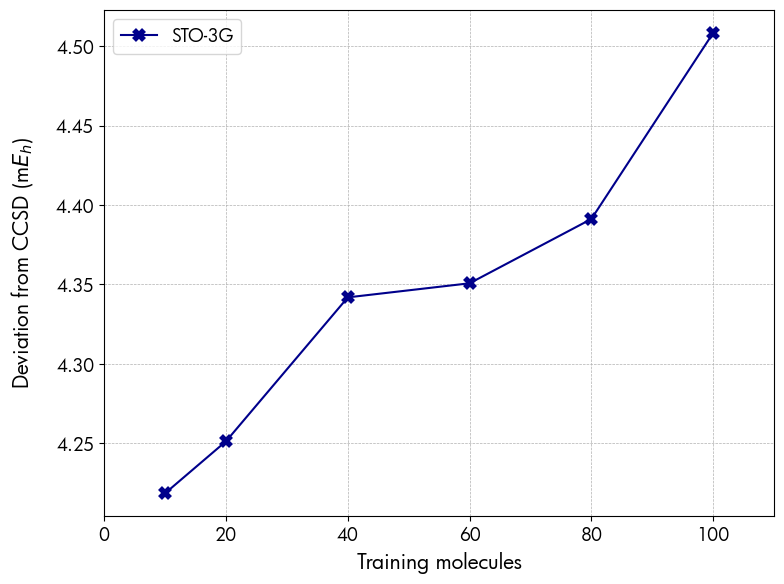

In [20]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(0, 110)
plt.savefig("figs/ccsd_energy.png", dpi=300)
plt.show()

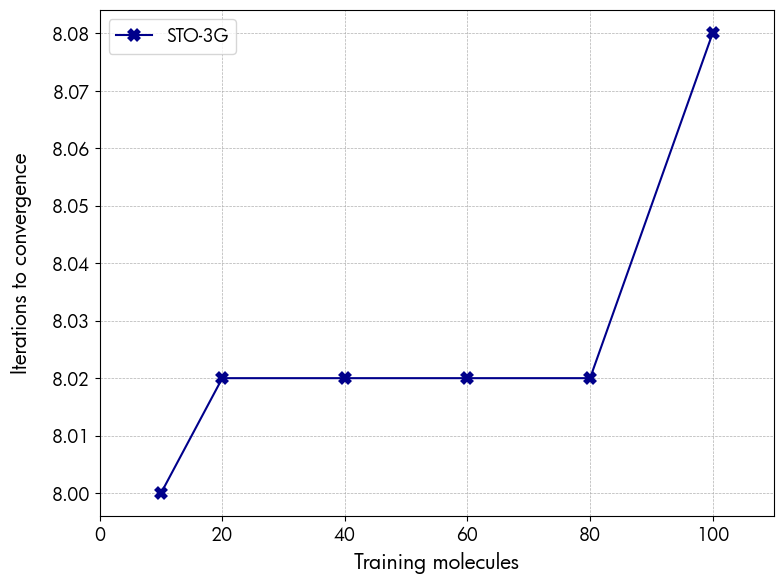

In [25]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(0, 110)
plt.savefig("figs/iterations.png", dpi=300)
plt.show()

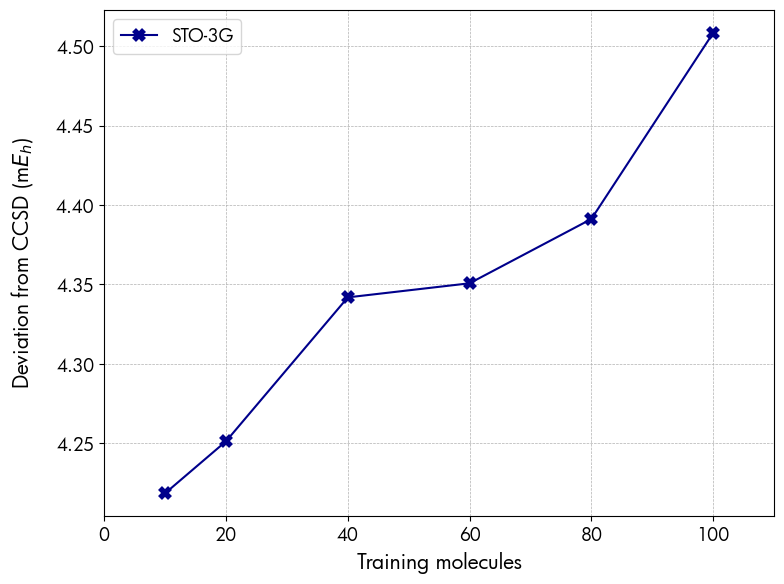

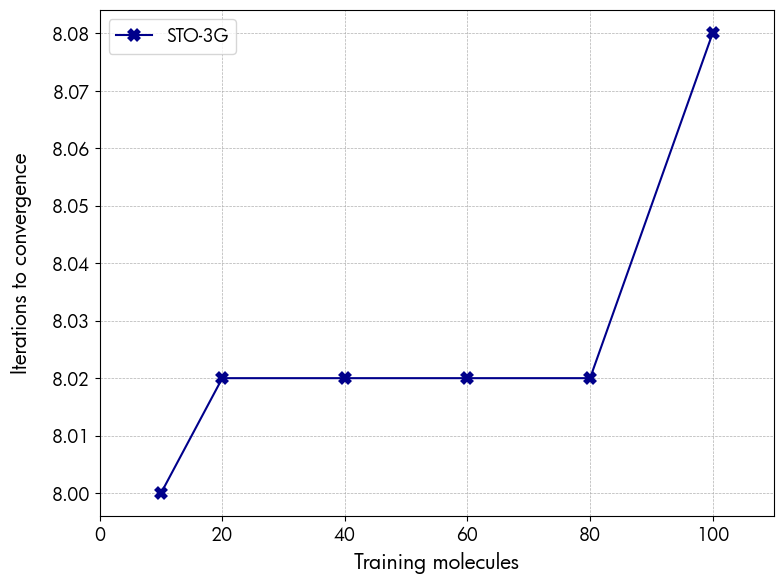

In [27]:
grouped = defaultdict(lambda: ([], []))  
for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  

fig, ax = plt.subplots(figsize=(8, 6))
#ax.set_aspect(0.6)

marker_styles = {'STO-3G': 'x', 'cc-pVDZ': '^', 'aug-cc-pVDZ': '+'}
color_styles = {'STO-3G': 'darkblue', 'cc-pVDZ': 'darkgreen', 'aug-cc-pVDZ': 'darkred'}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')
    ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
            markersize=7, markeredgewidth=4 if marker=='x' else 2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig("figs/ccsd_energy.png", dpi=300)
plt.show()

grouped = defaultdict(lambda: ([], []))
for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)

fig, ax = plt.subplots(figsize=(8, 6))
#ax.set_aspect(0.6)

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')
    ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
            markersize=7, markeredgewidth=4 if marker=='x' else 2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to convergence", fontsize=15, labelpad=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig("figs/iterations.png", dpi=300)
plt.show()

/tmp/ipykernel_517/867065737.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


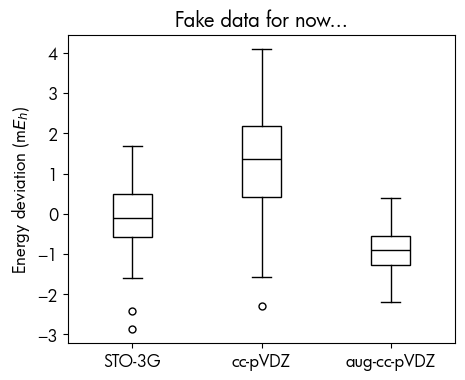

In [28]:

fake_data = [
    np.random.normal(loc=0, scale=1, size=100),   # STO-3g
    np.random.normal(loc=1, scale=1.5, size=100), # cc-pVDZ
    np.random.normal(loc=-1, scale=0.5, size=100) # aug-cc-pVDZ
]

fig, ax = plt.subplots(figsize=(5, 4))

ax.boxplot(
    fake_data,
    labels=["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"],
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(markerfacecolor="white", marker="o", markersize=5, linestyle="none", markeredgecolor="black")
)

plt.ylabel("Energy deviation (m$E_h$)", labelpad=4)
plt.title("Fake data for now...")
#plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("figs/boxplot.png", dpi=300)
plt.show()

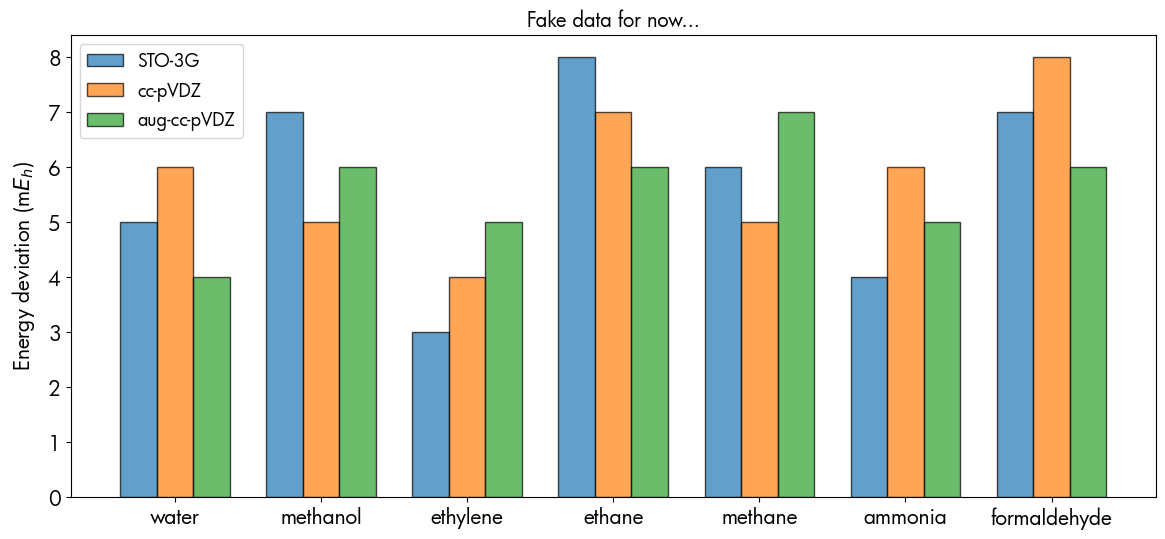

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

molecules = ['water', 'methanol', 'ethylene', 'ethane', 'methane', 'ammonia', 'formaldehyde']
# water, methanol, ethylene, ethane, methane, ammonia, and formaldehyde

values1 = [5, 7, 3, 8, 6, 4, 7]  # STO-3G
values2 = [6, 5, 4, 7, 5, 6, 8]  # cc-pVDZ
values3 = [4, 6, 5, 6, 7, 5, 6]  # aug-cc-pVDZ

x = np.arange(len(molecules))
width = 0.25  # width of each bar

plt.bar(x - width, values1, width, label='STO-3G', alpha=0.7, edgecolor='black')
plt.bar(x, values2, width, label='cc-pVDZ', alpha=0.7, edgecolor='black')
plt.bar(x + width, values3, width, label='aug-cc-pVDZ', alpha=0.7, edgecolor='black')

plt.xticks(x, molecules, fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel('Energy deviation (m$E_h$)', labelpad=8, fontsize=15)

plt.legend(fontsize=13)
plt.title("Fake data for now...")
plt.savefig("figs/barchart.png", dpi=300)
plt.show()

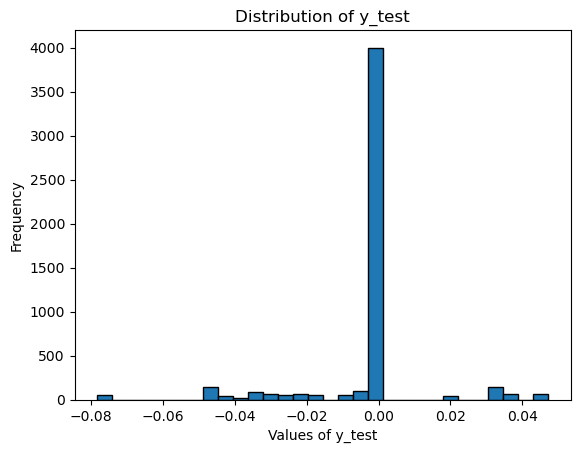

In [79]:
plt.hist(y_test, bins=30, edgecolor='black')
plt.xlabel("Values of y_test")
plt.ylabel("Frequency")
plt.title("Distribution of y_test")
plt.show()

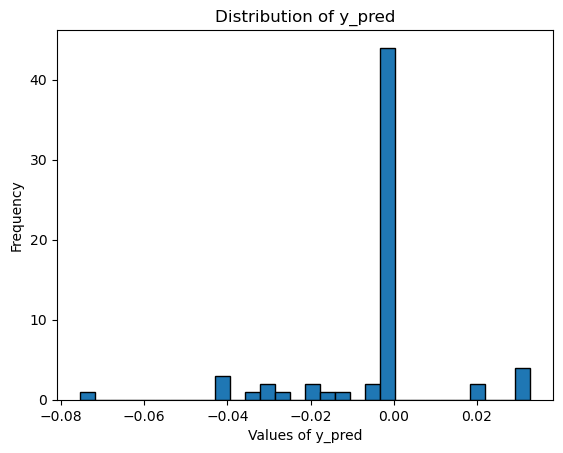

In [88]:
plt.hist(y_pred, bins=30, edgecolor='black')
plt.xlabel("Values of y_pred")
plt.ylabel("Frequency")
plt.title("Distribution of y_pred")
plt.show()

# Feature analysis

In [ ]:
################################################################################

In [7]:
basis = "STO-3G"
n = 100
data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

X_train = data["X_train"]
y_train = data["y_train"]

data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
X_test = data["X_test"]
y_test = data["y_test"]

In [8]:
# Clustering plots for the dataset
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

2025-10-12 15:02:49.912296: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-12 15:02:51.332667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
# Dimensionality reduction using PCA
t1 = time.time()
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
t2 = time.time()
print(f"Time taken: {t2-t1} seconds")

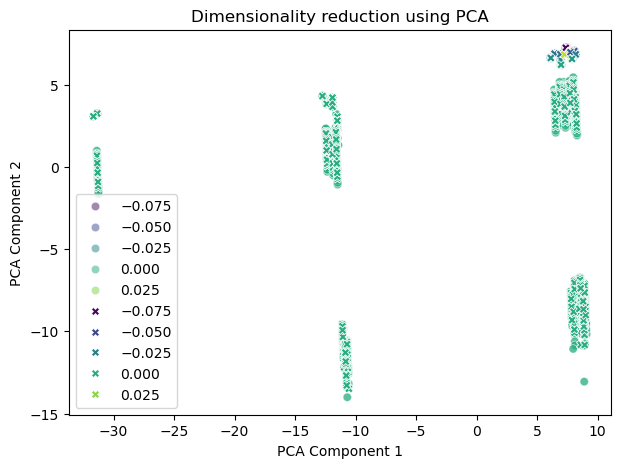

In [28]:
# Create the scatter plot with a continuous color range using "Spectral" palette
plt.figure(figsize=(7, 5))
scatter_train = sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train,  palette="viridis", alpha=0.5)
scatter_test = sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, palette="viridis", marker='X')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Dimensionality reduction using PCA')
plt.savefig("figs/pca.svg", format='svg', dpi=300)
plt.show()

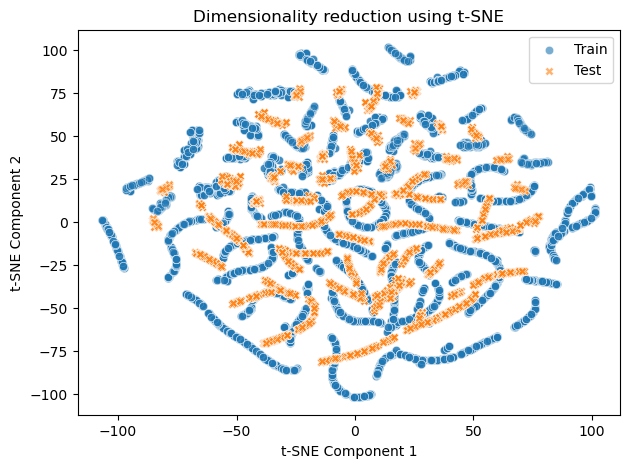

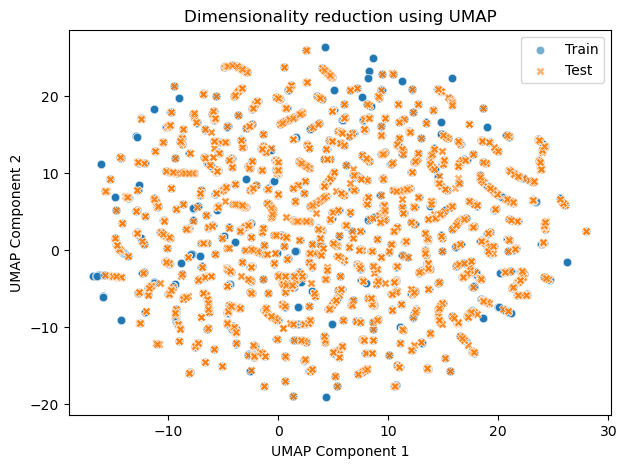

In [29]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_tsne[:, 0], y=X_test_tsne[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Dimensionality reduction using t-SNE')
plt.legend()
plt.savefig("figs/tsne.svg", format='svg', dpi=300)
plt.show()

# Dimensionality reduction using UMAP
reducer = umap.UMAP()
X_train_umap = reducer.fit_transform(X_train)
X_test_umap = reducer.transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_umap[:, 0], y=X_train_umap[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_umap[:, 0], y=X_test_umap[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('Dimensionality reduction using UMAP')
plt.legend()

plt.savefig("figs/umap.svg", format='svg', dpi=300)
plt.show()

In [9]:
X = np.concatenate([X_train, X_test], axis=0)
X_df = pd.DataFrame(X, columns=top5)

In [10]:
X_df

,doublecheck,t2start,t2mag,orbdiff,diag
0,3.103700e-02,-6.510431e-04,-3.127813,-41.657477,1.0
1,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
2,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
3,2.192688e-02,-4.490889e-04,-3.282063,-41.979770,1.0
4,-5.962675e-03,2.397402e-04,-3.580287,-22.684461,1.0
...,...,...,...,...,...
14795,-2.629338e-16,1.573146e-16,-15.949694,-2.341749,1.0
14796,3.875622e-02,-2.443025e-02,-1.704970,-1.964768,1.0
14797,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0
14798,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0


In [11]:
y_full = np.concatenate([y_train, y_test])
X_df['t2'] = y_full

In [12]:
cols = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag', 't2']

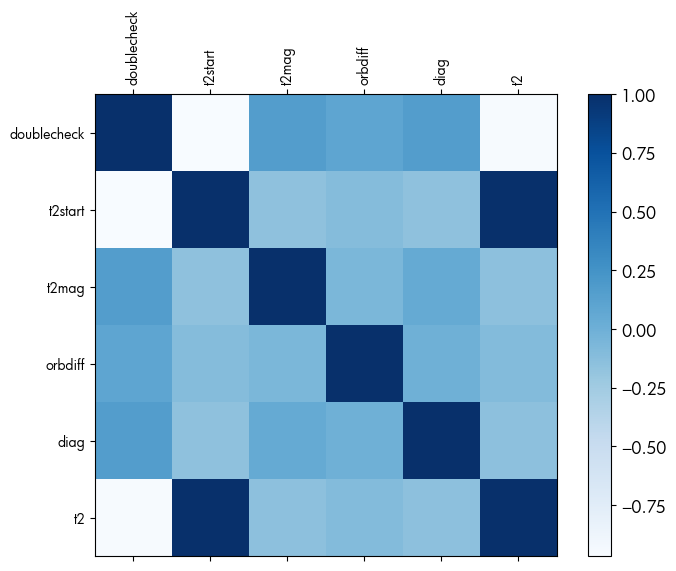

In [13]:
# Correlation matrix
corr = X_df.corr()

# Plot heatmap correctly
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap="Blues")

# Add colorbar
fig.colorbar(cax)

# Set ticks with feature names
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=10, weight='bold')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=10, weight='bold')

plt.savefig("figs/corr_top5.svg", format='svg', dpi=300)
plt.show()

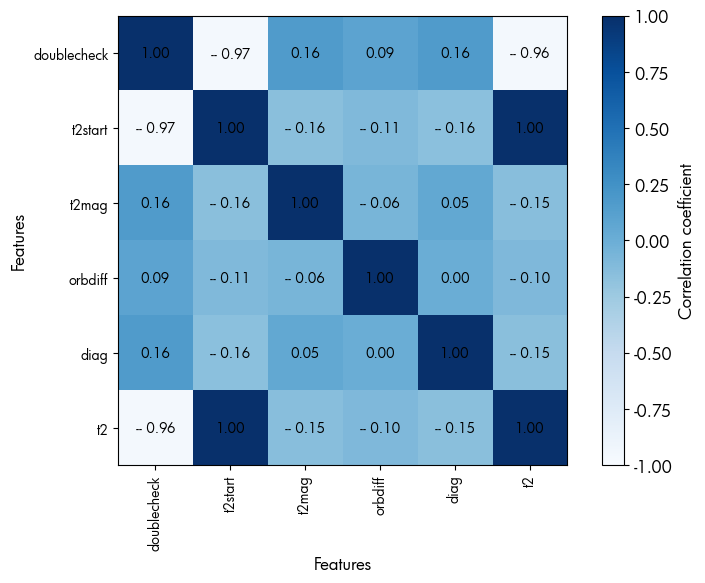

In [23]:
plt.rcParams['axes.unicode_minus'] = False
# Correlation matrix
corr = X_df.corr()

# Plot heatmap correctly
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap="Blues", vmin=-1, vmax=1)  # include -1 for even range

# Add colorbar with label
cbar = fig.colorbar(cax)
cbar.set_label("Correlation coefficient", fontsize=12)

# Add feature labels
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=10, weight='bold')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=10, weight='bold')

# Move x-axis labels to bottom
ax.xaxis.set_ticks_position('bottom')

# Add axis labels
ax.set_xlabel("Features", fontsize=12, weight='bold')
ax.set_ylabel("Features", fontsize=12, weight='bold')

# Add values in each square
#for (i, j), val in np.ndenumerate(corr.values):
#    ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=8)

for (i, j), val in np.ndenumerate(corr.values):
    if val < 0:
        display_val = f"-- {abs(val):.2f}"
    else:
        display_val = f"{val:.2f}"
    ax.text(j, i, display_val, ha='center', va='center', color='black', fontsize=10, weight='bold')


plt.tight_layout()
plt.savefig("figs/corr_top5.png", dpi=300)
plt.show()


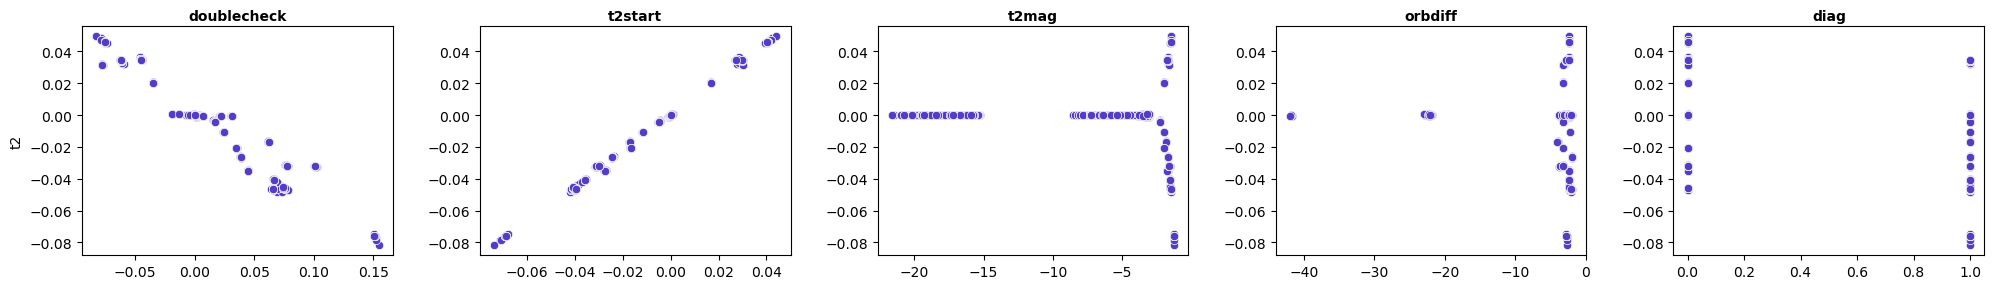

In [37]:
plot_df = X_df.copy()
target = 't2'

n_features = plot_df.shape[1] - 1  # exclude target
n_cols = 7
n_rows = (n_features - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()  # Flatten to simplify indexing

for i, col in enumerate(plot_df.columns):
    if col == target:
        continue
    sns.scatterplot(
        x=plot_df[col],
        y=plot_df[target],
        ax=axes[i],
        color="xkcd:blue with a hint of purple",
        legend=False
    )
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].xaxis.set_label_position('top')
    axes[i].set_ylabel(target if i % n_cols == 0 else '')

for j in range(len(plot_df.columns)-1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

plt.savefig("figs/corr_per_feature.svg", format='svg', dpi=300)
plt.show()

In [38]:
basis = "STO-3G"
n = 100
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_train_data_splits_{n}.pkl"
data = joblib.load(splits_fn)

X_train = data["X_train"]
y_train = data["y_train"]

splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
X_test = data["X_test"]
y_test = data["y_test"]

In [25]:
# SHAP feature importances
import shap
best_model = joblib.load('out/optimised_STO-3G_best_model_100.pkl')
tree_model = best_model.named_steps['xgb']

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/pickle.py:1718: UserWarning: [15:19:04] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/home/

In [26]:
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

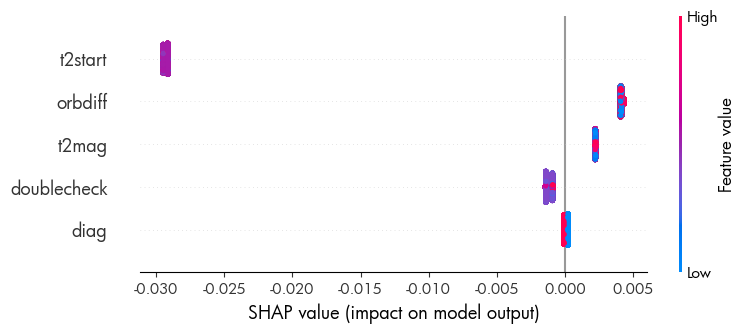

In [28]:
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=top5)

In [ ]:
plt.figure(figsize=(18,10))

shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)

#plt.xticks(fontsize=10) 
#plt.yticks(fontsize=12)
plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=10)
plt.ylabel("Top 5 Features", fontsize=14, labelpad=40)

for patch in plt.gca().patches:
    patch.set_facecolor("skyblue") 

plt.show()

In [43]:
tree_model.feature_importances_        # XGBoost feature importance values match the SHAP analysis

array([0.12930758, 0.79009914, 0.02735599, 0.04682388, 0.0064134 ],
      dtype=float32)

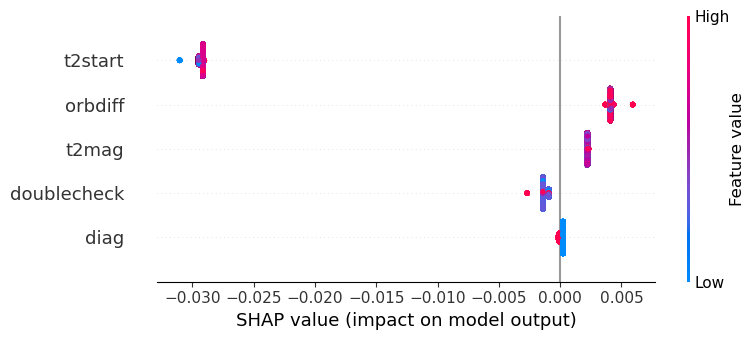

In [44]:
test_shap_values = explainer.shap_values(X_test)
shap.summary_plot(test_shap_values, X_test, feature_names=top5)

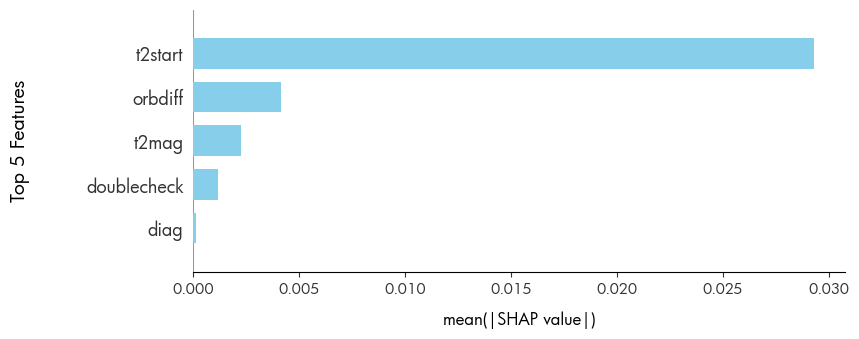

In [29]:
plt.figure(figsize=(18,10))

shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)

#plt.xticks(fontsize=10) 
#plt.yticks(fontsize=12)
plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=10)
plt.ylabel("Top 5 Features", fontsize=14, labelpad=40)

for patch in plt.gca().patches:
    patch.set_facecolor("skyblue") 

#plt.savefig("figs/shap_analysis.svg", format='svg', dpi=300)
plt.show()

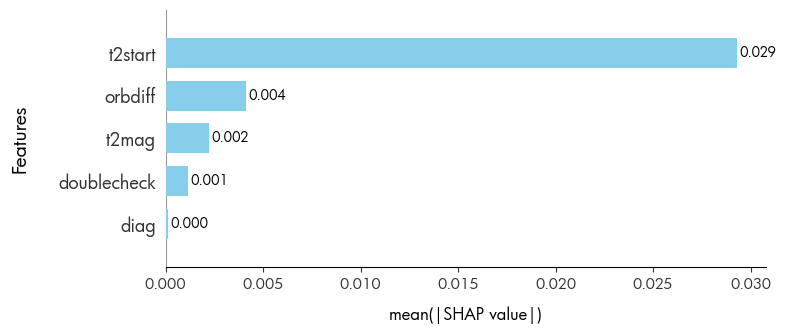

In [34]:
plt.figure(figsize=(18, 10))

shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)

plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=14, labelpad=20)

# Set bar color and add value at the end of each bar
for patch in plt.gca().patches:
    patch.set_facecolor("skyblue")
    width = patch.get_width()
    plt.text(
        width + 0.0001,  # slightly after the end of the bar
        patch.get_y() + patch.get_height() / 2,
        f"{width:.3f}",  # show value with 3 decimals
        va='center',
        fontsize=10,
        weight='bold'
    )

plt.tight_layout()
plt.savefig("figs/shap_analysis.png", dpi=300)
plt.show()


In [ ]:
#####

# Scaling of Random Forest

In [6]:
basis = "STO-3G"

data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
X_test = data["X_test"]
y_test = data["y_test"]

In [10]:
n_list = [10, 20, 40, 60, 80, 100]
for n in n_list:
    print(f"Train size: {n}")
    data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")
    
    X_train = data["X_train"]
    y_train = data["y_train"]
    
         
    model = RandomForestRegressor()
        
    model_pipeline = Pipeline([
        ('scaler', MinMaxScaler(feature_range=(-1,1))),
        ('regressor', model)
    ])
        
    # fit model
    t1 = time.time()
    model_pipeline.fit(X_train, y_train)
    t2 = time.time()
    y_pred = model_pipeline.predict(X_test)
    
    # compute performance metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    with open("water_out/deletemodel.pkl", "wb") as f:
        joblib.dump(model, f)

    file_size = os.path.getsize("water_out/deletemodel.pkl")
    print(f"Model size: {file_size / 1e6:.2f} MB")
    
    print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, Training time {t2-t1}\n")

Train size: 10
Model size: 3.95 MB
N: 10, MAE: 1.2645120210186362e-05, RMSE: 7.188917279532269e-05, R2: 0.9999794724379821, Training time 0.6920204162597656

Train size: 20
Model size: 7.49 MB
N: 20, MAE: 8.220006295029608e-06, RMSE: 7.557789553538916e-05, R2: 0.9999773118027194, Training time 1.201371431350708

Train size: 40
Model size: 14.36 MB
N: 40, MAE: 5.789106388286367e-06, RMSE: 5.2823795212411625e-05, R2: 0.9999889166869185, Training time 2.509720802307129

Train size: 60
Model size: 20.96 MB
N: 60, MAE: 5.354779676473874e-06, RMSE: 5.946617138302469e-05, R2: 0.9999859540746312, Training time 3.6909050941467285

Train size: 80
Model size: 26.20 MB
N: 80, MAE: 4.563882090426671e-06, RMSE: 4.283023150266202e-05, R2: 0.9999927136296144, Training time 4.887746810913086

Train size: 100
Model size: 31.26 MB
N: 100, MAE: 3.6982619071216727e-06, RMSE: 3.468848795961841e-05, R2: 0.999995220514596, Training time 6.494179964065552

